# Predicting Sculptor Stellar Abundances with The Cannon

This notebook applies the trained The Cannon models to MUSE spectra of stars in the Sculptor dwarf galaxy in order to estimate stellar labels and chemical abundances.

The required Sculptor spectra should be downloaded from Zotero and placed in:

`data/Sculptor_data/`

This notebook assumes that the trained models are already available in:

`tc_models/`

In [2]:
# --------------------------------------------------
# Imports
# --------------------------------------------------

import pickle
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import scipy
from scipy.interpolate import interp1d
from scipy import interpolate

import thecannon as tc

from astropy.table import Table, join
from astropy.io import fits
from astropy import constants

from PyAstronomy import pyasl
from uncertainties import ufloat


# --------------------------------------------------
# Local utilities
# --------------------------------------------------
import functions as utils

In [3]:
# --------------------------------------------------
# Paths
# --------------------------------------------------

data_path = Path("data")
sculptor_data_path = data_path / "Sculptor_data"
model_path = Path("tc_models")

## Loading trained Cannon models

We load the Cannon models trained in notebook 2.

The following configurations are considered:

- **Full-spectrum model**: uses the full wavelength range  
- **Absorption model**: uses only selected absorption features for each element  
- **Telluric model**: reduces the weight of telluric-contaminated regions  
- **Combined model**: combines absorption censoring and telluric masking


In [6]:
# --------------------------------------------------
# Load trained models
# --------------------------------------------------

def load_model_for_muse(model_name):
    model = tc.CannonModel.read(model_path / f"{model_name}.model")
    model._theta = model._theta[900:-10]
    model._s2 = model._s2[900:-10]
    return model


# full-spectrum model
full_model = tc.CannonModel.read(model_path / "lamost_apogee_cannon_full_model.model")
full_model_original_theta = full_model.theta.copy()
full_model_original_s = full_model.s2.copy()

full_model._theta = full_model._theta[900:-10]
full_model._s2 = full_model._s2[900:-10]

#now for the other models:
absorption_model = load_model_for_muse("lamost_apogee_cannon_absorption_model")
telluric_model = load_model_for_muse("lamost_apogee_cannon_telluric_model")
combined_model = load_model_for_muse("lamost_apogee_cannon_combined_model")

## Loading training labels

We also load the training labels used during model construction, which are required for label interpretation and consistency checks.

In [9]:
# --------------------------------------------------
# Load training labels
# --------------------------------------------------

with open(data_path / "trainingset_table.pickle", "rb") as f:
    training_data = pickle.load(f)

#training_labels_extended1 = training_data[0]


LAMOST_wavelength = np.loadtxt(
    data_path / "wavelength_Wheeler20.txt",
    usecols=(0,),
    unpack=True)

## Preparing Sculptor spectra

### Utility functions


In [78]:
# --------------------------------------------------
# Utility functions
# --------------------------------------------------



def interpolate_to_grid(xdata, ydata, xgrid):
    f = interpolate.interp1d(xdata, ydata)
    return xgrid, f(xgrid)

def dictionary_creation(final_table, SNR_array, predicted_labels_thecannon, unc_thecannon, chi2_model,idxs_all=[]):

    if len(idxs_all) > 0:original_idxs = idxs_all
    else: original_idxs =final_table ['id']
    
    dic = {}
    dic['number']= [int(i) for i in np.linspace(1,len(final_table ),len(final_table ))]
    dic['original_idx']= original_idxs
    dic['SNR'] = SNR_array
    dic['ra'] = final_table['ra']
    dic['dec'] = final_table['dec']
    dic['Teff'] = np.round(predicted_labels_thecannon[:,0])
    dic['logg'] = np.round(predicted_labels_thecannon[:,1],2)
    dic['vmic'] = np.round(predicted_labels_thecannon[:,2],2)
    dic['Ak'] = np.round(predicted_labels_thecannon[:,3],2)
    dic['l_feh'] = np.round(predicted_labels_thecannon[:,4],2)
    dic['l_mg'] = np.round(predicted_labels_thecannon[:,5],2)
    dic['l_mn'] = np.round(predicted_labels_thecannon[:,6],2)
    dic['l_al'] = np.round(predicted_labels_thecannon[:,7],2)
    dic['l_c'] = np.round(predicted_labels_thecannon[:,8],2)
    dic['l_n'] = np.round(predicted_labels_thecannon[:,9],2)
    dic['e_teff'] = np.round(unc_thecannon[:,0],2)
    dic['e_logg'] = np.round(unc_thecannon[:,1],2)
    dic['e_vmic'] = np.round(unc_thecannon[:,2],2)
    dic['e_Ak'] = np.round(unc_thecannon[:,3],2)
    dic['e_feh'] = np.round(unc_thecannon[:,4],2)
    dic['e_mg'] = np.round(unc_thecannon[:,5],2)
    dic['e_mn'] = np.round(unc_thecannon[:,6],2)
    dic['e_al'] = np.round(unc_thecannon[:,7],2)
    dic['e_c'] = np.round(unc_thecannon[:,8],2)
    dic['e_n'] = np.round(unc_thecannon[:,9],2)
    dic['red chi2'] = chi2_model
    dic = Table(dic)

    return dic


def binned_stats(x, y, bins, min_points=3):
            medians, q25, q75 = [], [], []
            for i in range(len(bins) - 1):
                 mask = (x >= bins[i]) & (x < bins[i + 1])
                 valid_y = y[mask]
                 valid_y = valid_y[~np.isnan(valid_y)]  # eliminar NaNs en y
        
                 if len(valid_y) >= min_points:
                     medians.append(np.nanmedian(valid_y))
                     q25.append(np.nanpercentile(valid_y, 25))
                     q75.append(np.nanpercentile(valid_y, 75))
                 else:
                     medians.append(np.nan)
                     q25.append(np.nan)
                     q75.append(np.nan)

            return np.array(medians), np.array(q25), np.array(q75)

def compute_ivar_and_mask_tellurics(
    sigma_array,
    wavelength,
    telluric_bands,
    sigma_value=999
):
    """
    Compute inverse variance and downweight telluric regions.
    """

    ivar = 1 / (sigma_array ** 2)

    ivar_telluric = ivar.copy()

    for i, w in enumerate(wavelength):
        for b in telluric_bands:
            if w >= b[0] and w <= b[1]:
                ivar_telluric[:, i] = 1 / (sigma_value ** 2)

    return ivar, ivar_telluric


def covariance_to_uncertainties(covariance):
    """
    Convert covariance matrices into per-label uncertainties.
    """

    uncertainties = np.sqrt([
        np.diag(covariance[i])
        for i in range(covariance.shape[0])
    ])

    median_unc = np.median(uncertainties, axis=0)

    return uncertainties, median_unc


def npix_chi2(metadata,number_stars):
    '''
    Estimate the number of pixels used in reduced chi2 calculation. This is considering that:
    chi2_r = chi2 / (Npix - L - 1), where L=10 (number of labels).
    (This equation was taken from The Cannon code)
    '''
    random_star = np.random.randint(0,number_stars)
    
    Npix = (metadata[random_star]['chi_sq'] / metadata[random_star]['r_chi_sq']) - 9
    
    return Npix


### Loading Sculptor MUSE data


In [18]:
scl_path = sculptor_data_path / "sculptor_muse_spec_2024-09-11_o7_smooth.fits"
scl_full_table = Table.read(scl_path)

print(f"Total Sculptor stars: {len(scl_full_table)}")
scl_full_table


Total Sculptor stars: 816


id,m_F450W,m_F814W,dm_F450W,dm_F814W,sn,ra,dec
int32,float64,float64,float64,float64,float64,float64,float64
3,20.143407634756983,19.47444653651918,0.011,0.003,21.306007753917008,15.0269355,-33.713321
9,21.72240763475698,20.844446536519182,0.014,0.005,16.49472296425374,15.0325126,-33.713171
10,21.90840763475698,21.06144653651918,0.015,0.006,15.448451524257095,15.032444,-33.713581
12,21.750407634756982,21.11244653651918,0.014,0.007,11.049836160921078,15.0263125,-33.713751
23,22.56940763475698,22.01944653651918,0.02,0.01,10.217511920446668,15.0290676,-33.713455
25,22.684407634756983,22.01744653651918,0.027,0.012,7.401980103566158,15.0261385,-33.713027
32,22.95340763475698,22.318446536519183,0.029,0.013,7.644972048432123,15.0255761,-33.713238
33,22.80240763475698,22.33444653651918,0.024,0.013,6.20824183396068,15.0263701,-33.714173
36,22.899407634756983,22.376446536519182,0.024,0.013,8.207018531386321,15.0321758,-33.712904


### Selecting RGB stars

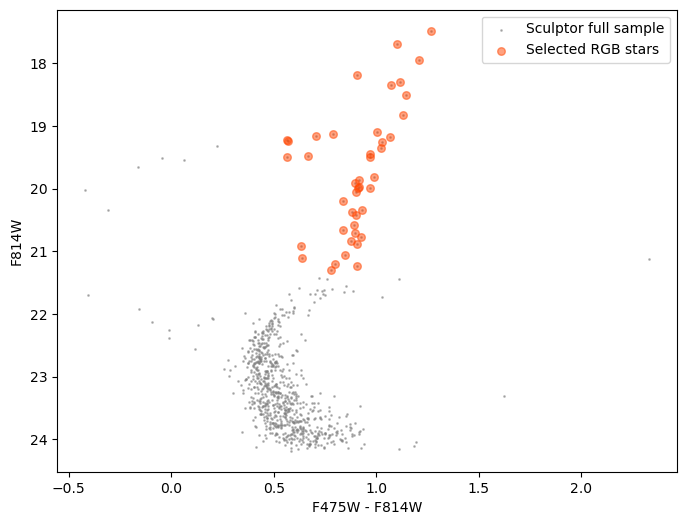

In [21]:
color_scl_full = scl_full_table["m_F450W"] - scl_full_table["m_F814W"]
mag_scl_full = scl_full_table["m_F814W"]

rgb_scl_mask = (
    (color_scl_full > 0.4)
    & (color_scl_full < 2)
    & (mag_scl_full < 21.3)
)


plt.figure(figsize=(8,6))
plt.scatter(color_scl_full, mag_scl_full, s=1, alpha=0.5 , label = 'Sculptor full sample', color='gray')
plt.scatter(color_scl_full[rgb_scl_mask], mag_scl_full[rgb_scl_mask], s=30, alpha=0.5, label = 'Selected RGB stars', color='orangered')
plt.gca().invert_yaxis()  
plt.xlabel('F475W - F814W')
plt.ylabel('F814W')
plt.legend()
plt.show()

### Extracting spectra

In [24]:
with fits.open(scl_path) as scl_datacube:
    scl_full_Flux = scl_datacube[0].data.T               #shape = (816,2703)
    scl_full_Sigma = scl_datacube[1].data.T              #shape = (816,2703)
    original_MUSE_wavelength_scl = scl_datacube[2].data  #shape = (2703,)


scl_masked_Flux = scl_full_Flux[rgb_scl_mask]    #shape = (43,2703)
scl_masked_Sigma = scl_full_Sigma[rgb_scl_mask]  #shape = (43,2703)

#scl_SNR = np.nanmedian(scl_masked_Flux / scl_masked_Sigma, axis=1)  #using the original flux and sigma arrays to calculate SNR

### Spectral normalization

In [27]:
# quality cuts + normalization
scl_norm_Flux, scl_norm_Sigma = utils.normalize_sculptor_spectra(
    scl_masked_Flux,
    scl_masked_Sigma)

### Calculating SNR from the spectra

In [30]:
scl_norm_Flux_snr_masked, scl_norm_Sigma_snr_masked, scl_SNR, scl_SNR_mask = utils.apply_snr_mask(
    scl_norm_Flux,
    scl_norm_Sigma,
    scl_masked_Flux,
    scl_masked_Sigma
)

print(
    'Selected Sculptor stars after SNR masking: ',
    len(scl_norm_Flux_snr_masked),
    ' / from a total of: ',
    len(scl_full_table)
)


Selected Sculptor stars after SNR masking:  42  / from a total of:  816


### Radial velocity correction

Radial velocities are estimated by cross-correlating each MUSE spectrum with the first coefficient of the full-spectrum Cannon model.

In [33]:
# radial velocity calculation

z_correction_all_scl, velout_all_scl = utils.compute_radial_velocities(
    scl_norm_Flux_snr_masked,
    original_MUSE_wavelength_scl,
    LAMOST_wavelength,
    full_model_original_theta[:,0],
    interpolate_to_grid
)

v_mask = (
    (velout_all_scl > np.median(velout_all_scl) - 3*np.std(velout_all_scl)) &
    (velout_all_scl < np.median(velout_all_scl) + 3*np.std(velout_all_scl))
)

z_correction_all_scl = z_correction_all_scl[v_mask]

print(
    'Considering a std of:',
    np.std(velout_all_scl),
    ' -- the outlier is:',
    velout_all_scl[~v_mask]
)


Star : 0
Star : 10
Star : 20
Star : 30
Star : 40
Considering a std of: 17.037748306229048  -- the outlier is: [53.88]


#### Radial velocity comparison with literature


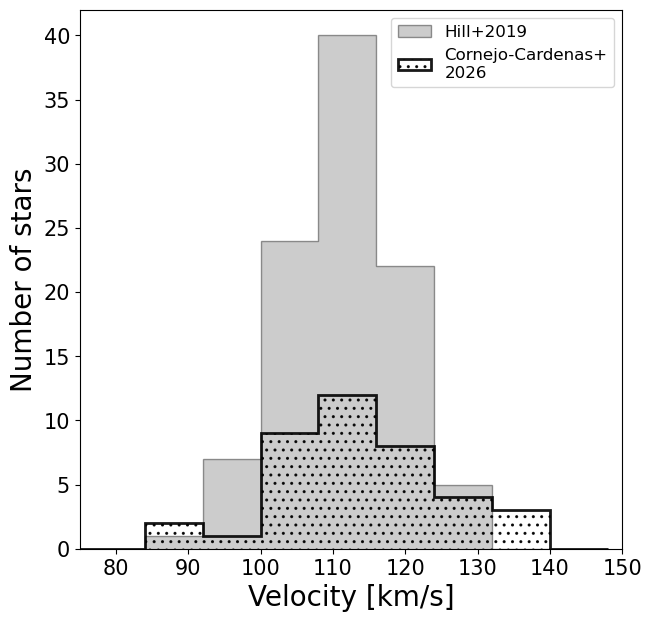

Our work:  113.7199999996692 + - 14.340787340945477
Hill rad vel: 111.84 + - 7.9091547748237385
Skuladottir rad vel: 111.65 + - 8.075626517194415


In [35]:
# Plotting the RV

## -- Literature: Hill et al. (2019)   --
hill19_selected = Table.read(f'{sculptor_data_path}/Sculptor_VLT_Hill2019.fit')  #table that I used to get the Mg estimations (99 stars)
hill19_full = Table.read(f'{sculptor_data_path}/Sculptor_Hilli2019_table1.fit')  #second table that I get from vizier (129 stars)
hill19_scl_table = join(hill19_selected, hill19_full, keys='Star', join_type='inner')
## -- Literature: Skuladottir et al. (2015) --
skuladottir15_scl_table = Table.read(f'{sculptor_data_path}/Sculptor_Skuladottir2015_table1.fit')

plt.figure(figsize=(7,7))
plt.hist(hill19_scl_table['RV'],label='Hill+2019',lw=1,edgecolor='k',color='grey',histtype='step',
         bins=np.arange(60,150,8),fill=True,alpha=0.4)
#plt.hist(skuladottir15_scl_table['RV'],label='Skuladottir et al. (2015)',lw=1,edgecolor='k',color='blue',histtype='step',
#         bins=np.arange(60,150,8),fill=True,alpha=0.3)
plt.hist(np.array(velout_all_scl)[v_mask],bins=np.arange(60,150,8),histtype='step',color='red',
         fill=False,alpha=0.9,hatch='..',edgecolor='k',lw=2,label='Cornejo-Cardenas+\n2026')
plt.xlabel("Velocity [km/s]",fontsize=20)
plt.ylabel("Number of stars",fontsize=20)
plt.tick_params(labelsize=15)
plt.legend(fontsize=12)
plt.xlim(75,150)
#plt.savefig(f'/Users/anell/avatar_MuseCannon/figures/RV_sculptor_giants'+'.png',dpi=300,bbox_inches='tight')
plt.show()
        
print('Our work: ',np.median(velout_all_scl[v_mask]),'+ -',np.std(velout_all_scl[v_mask]))
print('Hill rad vel:',np.median(hill19_scl_table['RV']),'+ -',np.std(hill19_scl_table['RV']))
print('Skuladottir rad vel:',np.median(skuladottir15_scl_table['RV']),'+ -',np.std(skuladottir15_scl_table['RV']))

In [38]:
scl_norm_Flux_vr_masked = scl_norm_Flux_snr_masked[v_mask,:]
scl_norm_Sigma_vr_masked = scl_norm_Sigma_snr_masked[v_mask,:]

print('After radial vel. masking we have: ',len(scl_norm_Flux_vr_masked),' of ', len(scl_full_table),'Sculptor stars')

After radial vel. masking we have:  41  of  816 Sculptor stars


### Rest-frame interpolation

In [41]:
# Redshift correction and interpolation

scl_final_Flux_all, scl_final_Sigma_all = utils.restframe_and_interpolate_sculptor(
    scl_norm_Flux_vr_masked,
    scl_norm_Sigma_vr_masked,
    original_MUSE_wavelength_scl,
    z_correction_all_scl,
    LAMOST_wavelength[900:-10],
    interpolate_to_grid)


### Preparing inverse variance arrays


In [44]:
# Calculating ivar variable
telluric_file = data_path / "linelists" / "ardata.fits"
telluric_bands = utils.Telluric_bands(filename=telluric_file)


scl_final_IVAR_all, scl_final_IVAR_all_telluric = compute_ivar_and_mask_tellurics(
    scl_final_Sigma_all,
    LAMOST_wavelength[900:-10],
    telluric_bands
)


## Applying The Cannon to Sculptor spectra

In this section, the four trained Cannon models are applied to the prepared Sculptor spectra to infer stellar labels. This comparison allows us to evaluate how sensitive the inferred abundances are to different spectral masking strategies.


In [55]:
# Testing the four trained Cannon models

# Full-spectrum model
predicted_labels_scl_full_model, cov_scl_full_model, metadata_scl_full_model = full_model.test(
    scl_final_Flux_all,
    scl_final_IVAR_all
)

# Absorption model
predicted_labels_scl_absorption_model, cov_scl_absorption_model, metadata_scl_absorption_model = absorption_model.test(
    scl_final_Flux_all,
    scl_final_IVAR_all
)

# Telluric model
predicted_labels_scl_telluric_model, cov_scl_telluric_model, metadata_scl_telluric_model = telluric_model.test(
    scl_final_Flux_all,
    scl_final_IVAR_all_telluric
)

# Combined model
predicted_labels_scl_combined_model, cov_scl_combined_model, metadata_scl_combined_model = combined_model.test(
    scl_final_Flux_all,
    scl_final_IVAR_all_telluric
)


stty: stdin isn't a terminal
2026-04-05 07:56:44,693 [DEBUG] Couldn't get screen size. Progressbar may look odd.
2026-04-05 07:56:44,694 [INFO] Running test step on 41 spectra


[=========================================                                                           ] 100% (3s)                             


stty: stdin isn't a terminal
2026-04-05 07:56:47,943 [DEBUG] Couldn't get screen size. Progressbar may look odd.
2026-04-05 07:56:47,943 [INFO] Running test step on 41 spectra


[=========================================                                                           ] 100% (4s)                             


stty: stdin isn't a terminal
2026-04-05 07:56:51,508 [DEBUG] Couldn't get screen size. Progressbar may look odd.
2026-04-05 07:56:51,509 [INFO] Running test step on 41 spectra


[=========================================                                                           ] 100% (4s)                             


stty: stdin isn't a terminal
2026-04-05 07:56:55,055 [DEBUG] Couldn't get screen size. Progressbar may look odd.
2026-04-05 07:56:55,055 [INFO] Running test step on 41 spectra


[=========================================                                                           ] 100% (4s)                             


In [67]:
# Model uncertainties

unc_scl_full_model, rep_unc_scl_full_model = covariance_to_uncertainties(cov_scl_full_model)
print('Full-spectrum model median uncertainties for each label:\n', rep_unc_scl_full_model)

unc_scl_absorption_model, rep_unc_scl_absorption_model = covariance_to_uncertainties(cov_scl_absorption_model)
print('\nAbsorption model median uncertainties for each label:\n', rep_unc_scl_absorption_model)

unc_scl_telluric_model, rep_unc_scl_telluric_model = covariance_to_uncertainties(cov_scl_telluric_model)
print('\nTelluric model median uncertainties for each label:\n', rep_unc_scl_telluric_model)

unc_scl_combined_model, rep_unc_scl_combined_model = covariance_to_uncertainties(cov_scl_combined_model)
print('\nCombined model median uncertainties for each label:\n', rep_unc_scl_combined_model)


Full-spectrum model median uncertainties for each label:
 [0.04602854 0.06967999 0.08384526 0.10814232 0.04706826 0.12678518
 0.15377392 0.11512465 0.14115042 0.20169268]

Absorption model median uncertainties for each label:
 [0.0463239  0.06935139 0.09786052 0.10683866 0.04376445 0.2153576
 0.3738159  0.87282753 0.16111267 0.2271916 ]

Telluric model median uncertainties for each label:
 [0.0574555  0.08397704 0.09580549 0.11333303 0.05120184 0.16780735
 0.18995467 0.14713092 0.16244195 0.24010548]

Combined model median uncertainties for each label:
 [0.04832159 0.07169761 0.10472986 0.1198884  0.04422338 0.21936328
 0.36024736 0.89249865 0.16375642 0.25110235]


In [69]:
# MUSE observations of selected Sculptor's stars
scl_final_table = scl_full_table[rgb_scl_mask][scl_SNR_mask][v_mask]

In [71]:
## Keeping the data in dicitonaries

#full-spectrum model
scl_dic_full_model = dictionary_creation(scl_final_table,
                                     scl_final_table,
                                     predicted_labels_scl_full_model,
                                     unc_scl_full_model,
                                     np.round([entry['r_chi_sq'] for entry in metadata_scl_full_model],2))

#absorption-spectrum model
scl_dic_absorption_model = dictionary_creation(scl_final_table,
                                     scl_final_table,
                                     predicted_labels_scl_absorption_model,
                                     unc_scl_absorption_model,
                                     np.round([entry['r_chi_sq'] for entry in metadata_scl_absorption_model],2))


#telluric model
scl_dic_telluric_model = dictionary_creation(scl_final_table,
                         scl_final_table,
                         predicted_labels_scl_telluric_model,
                         unc_scl_telluric_model,
                         np.round([entry['r_chi_sq'] for entry in metadata_scl_telluric_model],2))

#combined model
scl_dic_combined_model = dictionary_creation(scl_final_table,
                         scl_final_table,
                         predicted_labels_scl_combined_model,
                         unc_scl_combined_model,
                         np.round([entry['r_chi_sq'] for entry in metadata_scl_combined_model],2))

In [88]:
# Number of pixeles used for chi2 calculations
# according to the masks and restrictions used inside of the cannon:

npix_full_model = npix_chi2(metadata_scl_full_model, len(scl_final_Flux_all))
npix_absorption_model = npix_chi2(metadata_scl_absorption_model, len(scl_final_Flux_all))
npix_telluric_model = npix_chi2(metadata_scl_telluric_model, len(scl_final_Flux_all))
npix_combined_model = npix_chi2(metadata_scl_combined_model, len(scl_final_Flux_all))


print('Number of pixels used in full model:',npix_full_model , 
      '\nNumber of pixels used in absorption model:',npix_absorption_model,
      '\nNumber of pixels used in telluric model:',npix_telluric_model ,
      '\nNumber of pixels used in combined model:',npix_combined_model)

Number of pixels used in full model: 2629.0 
Number of pixels used in absorption model: 2629.0 
Number of pixels used in telluric model: 2227.0 
Number of pixels used in combined model: 2227.0


In [90]:
print('Median reduced χ² full model:', np.median(scl_dic_full_model['red chi2']))
print('Median reduced χ² absorption model:', np.median(scl_dic_absorption_model['red chi2']))
print('Median reduced χ² telluric model:', np.median(scl_dic_telluric_model['red chi2']))
print('Median reduced χ² combined model:', np.median(scl_dic_combined_model['red chi2']))

Median reduced χ² full model: 0.33
Median reduced χ² absorption model: 0.33
Median reduced χ² telluric model: 0.33
Median reduced χ² combined model: 0.33


## Plots

### Theta coefficients

Mg


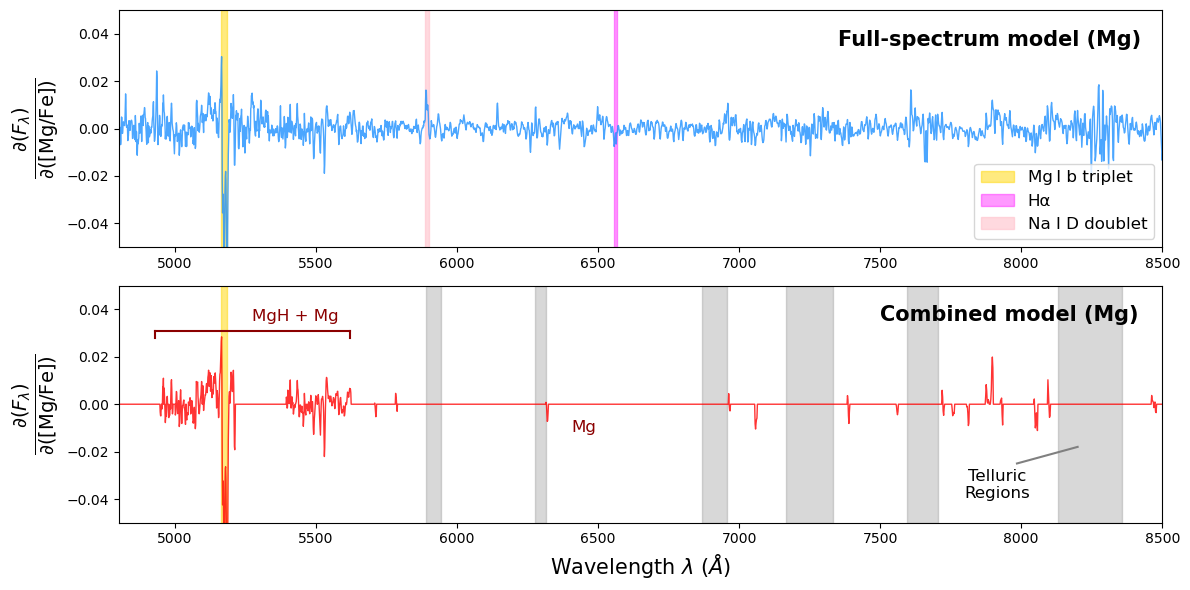

In [100]:


def plot_coefficients_comparison2(models, model_names, wavelength_array,selected_elem = 6, ccds=[1], 
                                 colors=None,lws=[],lss=[],saveplot=False,label_name=None):
    '''
    Compares just one chemical element of multiple models in a single figure.
    
    Parameters:
    - models: List of TheCannon models to compare.
    - model_names: List of names corresponding to the models.
    - selected_elem: index of the selected element.
    - ccds: List of CCDs to include in the plot.
    - colors: List of colors for each model. If None, defaults are used.
    '''
    num_plots = len(models)
    index = selected_elem
    
    if num_plots == 2: fig, axes = plt.subplots(num_plots, len(ccds), figsize=(12, 3 * num_plots), sharex=False)
    else: fig, axes = plt.subplots(num_plots, len(ccds), figsize=(5*15/num_plots, 2 * num_plots), sharex=False)
        
    if num_plots == 1:  # Handle case with only one plot
        axes = np.array([axes])
        

    # Default colors if none are provided
    if colors is None:
        colors = ['b', 'r', 'g', 'm', 'c','k','grey','C0','C1','C2','C3'][:len(models)]  # Extend if needed
    
    # Default lw and lss in None is provided:
    if len(lws) == 0 or len(lss) == 0:
        lws=[1]*len(model_names)
        lss=['-']*len(model_names)
    
    ylabel =  models[0].vectorizer.get_human_readable_label_term( index, label_names=models[0].vectorizer.label_names, 
                                                                 mul='cdot', pow='^')

    in_wavelength_range =wavelength_array > 0.
    
    for i in range(0,num_plots):
        ax    = axes[i] 
        model = models[i]
        name  = model_names[i]
        color = colors[i]
        lw    = lws[i]
        ls    = lss[i]
#
        ## --- Studyng strong features impact: ----
        #Mg triplet
        mg_t1 = 5167
        mg_t2 = 5172
        mg_t3 = 5183
        ax.axvspan(mg_t1-3, mg_t3+3, color='gold', alpha=0.5, label='Mg I b triplet')
        
        if i == 0 :
            elems = [6,7,8,9,10]
            if selected_elem in elems:
                #Hα lines
                ax.legend(loc='upper right', fontsize=10)     
                ax.axvspan(6555, 6566, color='magenta', alpha=0.4, label='Hα')

                ## Sodium doublet   
                na_d1 = 5885 #5889.95
                na_d2 = 5900#5895.92
                ax.axvspan(na_d1, na_d2, color='pink', alpha=0.6, label='Na I D doublet')
                ax.legend(loc='upper right', fontsize=10)

                #Mg triplet
                #mg_t1 = 5167
                #mg_t2 = 5172
                #mg_t3 = 5183
                #ax.axvspan(mg_t1, mg_t3+5, color='gold', alpha=0.5, label='Mg I b triplet')
                #ax.legend(loc='upper right', fontsize=10)


        ## --- Plotting ---
        ax.plot(wavelength_array[in_wavelength_range], model.theta[in_wavelength_range, index],
                lw=lw, ls=ls, c=color, alpha=0.8)
        ax.set_ylim(-0.05, 0.05)
        ax.set_xlim(4800,8500)
        if label_name is None: ax.set_ylabel(ylabel,fontsize=15)
        else: ax.set_ylabel(label_name,fontsize=20)
        

        ## --- Adding telluric pollution ---
        if i == 1:
            tell_bands = utils.Telluric_bands(filename=f'{data_path}/linelists/ardata.fits')
            for band in tell_bands:
                low_band = band[0]
                high_band = band[1]
                ax.axvspan(low_band, high_band, color='grey', alpha=0.3)
    
        ## --- Wroten labels ---
        if i == 1 and selected_elem==6:
            #MgH + Mg left
            y0, y1 = 0.028, 0.031
            x_start, x_end = 4930, 5620
            # Left vertical line
            ax.plot([x_start, x_start], [y0, y1], color='darkred', lw=1.5)
            # Right vertical line
            ax.plot([x_end, x_end], [y0, y1], color='darkred', lw=1.5)
            # Horizontal line
            ax.plot([x_start, x_end], [y1, y1], color='darkred', lw=1.5)
            # Label
            ax.text((x_start + x_end+300)/2, y1 + 0.003, 'MgH + Mg', ha='center', va='bottom', fontsize=12,color='darkred')

            #Mg left
            y1 = -0.015
            x_start, x_end = 6400, 6500
            ax.text((x_start + x_end)/2, y1 + 0.002, 'Mg', ha='center', va='bottom', fontsize=12,color='darkred')

            #Telluric region
            y0 , y1 = -0.025,-0.018
            x_start, x_end = 7985, 8200
            # stright line
            ax.plot([x_start, x_end], [y0, y1], color='gray', lw=1.5)
            # Right vertical line
            #ax.plot([x_end, x_end], [y0, y1], color='darkred', lw=1.5)
            # Horizontal line
            #ax.plot([x_start, x_end], [y1, y1], color='darkred', lw=1.5)
            # Label
            ax.text(x_start - 70 , y1 - 0.023, 'Telluric\nRegions', ha='center', va='bottom', fontsize=12,color='black')


        # title of each model:
        if len(name) > 20: ax.text(7350,0.035, name,fontsize=15,weight='bold')
        if len(name) < 20: ax.text(7500,0.035, name,fontsize=15,weight='bold')
        
        if i == 0: ax.legend(loc='lower right', fontsize=12)

        if i == 1: ax.set_xlabel(r'Wavelength $\lambda$ ($\AA$)',fontsize=15)
            
            
    plt.tight_layout()
    if saveplot == True: 
        figures_path = Path("figures")
        figures_path.mkdir(exist_ok=True)
        plt.savefig(f'figures/Models_comparison_{ylabel}'+'.png',dpi=300,bbox_inches='tight')
    plt.show()


#Mg
print('Mg')
plot_coefficients_comparison2([full_model,combined_model], 
                             ['Full-spectrum model (Mg)','Combined model (Mg)'],
                              wavelength_array = LAMOST_wavelength[900:-10],
                              colors=['dodgerblue','red'],
                              lws = [1,1],
                              lss = ['-','-'],
                             selected_elem = 6,
                              label_name = r'$\frac{\partial(F_\lambda)}{\partial([\text{Mg/Fe}])}$',
                             saveplot = True)

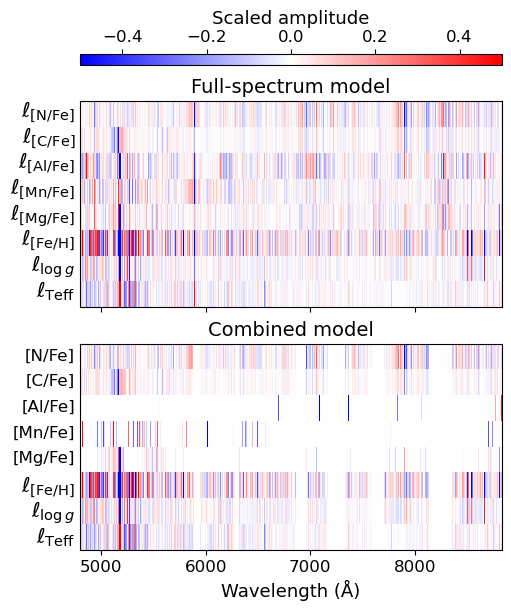

In [115]:
saveplot = True

wave = LAMOST_wavelength[900:-10]

# --- Labels for theta coefficients ---
theta_labels_top = [
    r'$\ell_{\mathrm{Teff}}$',
    r'$\ell_{\log g}$',
    r'$\ell_{\mathrm{[Fe/H]}}$',
    r'$\ell_{\mathrm{[Mg/Fe]}}$',
    r'$\ell_{\mathrm{[Mn/Fe]}}$',
    r'$\ell_{\mathrm{[Al/Fe]}}$',
    r'$\ell_{\mathrm{[C/Fe]}}$',
    r'$\ell_{\mathrm{[N/Fe]}}$']

theta_labels_bottom = [
    r'$\ell_{\mathrm{Teff}}$',
    r'$\ell_{\log g}$',
    r'$\ell_{\mathrm{[Fe/H]}}$',
    '[Mg/Fe]',
    '[Mn/Fe]',
    '[Al/Fe]',
    '[C/Fe]',
    '[N/Fe]']

# Define wavelength bin edges for pcolormesh (N+1 edges required for N spectral bins)
wave_edges = np.append(wave, wave[-1] + np.median(np.diff(wave)))

# Define row edges for each coefficient
y_edges = np.arange(len(theta_labels_top)+1)


# --- Scale each row independently ---
def scale_rows(matrix):
    row_max = np.max(np.abs(matrix), axis=1, keepdims=True)
    return matrix / row_max
selected_idx = [1,2,5,6,7,8,9,10]
full_theta = scale_rows(full_model.theta[:, selected_idx].T)
combined_theta = scale_rows(combined_model.theta[:, selected_idx].T)

fig, axes = plt.subplots(
    2, 1,
    figsize=(5, 6),
    sharex=True,
    constrained_layout=True
)

# --- Upper panel: Full-spectrum model ---
im1 = axes[0].pcolormesh(wave_edges,
                         y_edges,
                         full_theta,
                         cmap='bwr',
                         vmin=-0.5,
                         vmax=0.5,
                         shading='auto')

axes[0].set_title('Full-spectrum model', fontsize=14)

# --- Lower panel: Combined model ---
im2 = axes[1].pcolormesh(wave_edges,
                         y_edges,
                         combined_theta,
                         cmap='bwr',
                         vmin=-0.5,
                         vmax=0.5,
                         shading='auto')

axes[0].set_yticks(np.arange(len(theta_labels_top)) + 0.75)
axes[0].set_yticklabels(theta_labels_top, fontsize=15)

axes[1].set_yticks(np.arange(len(theta_labels_bottom)) + 0.6)
axes[1].set_yticklabels(theta_labels_bottom)
# Adjust fontsize individually
for i, label in enumerate(axes[1].get_yticklabels()):
    if i < 3:
        label.set_fontsize(15)   # first three labels (teff, logg and [Fe/H])
    else:
        label.set_fontsize(12)   # remaining labels
        

for ax in axes:
    ax.tick_params(axis='x', labelsize=12)
    ax.tick_params(axis='y', length=0)

axes[1].set_title('Combined model', fontsize=14)
axes[1].set_xlabel('Wavelength (Å)', fontsize=13)

# --- Shared horizontal colorbar ---
cbar = fig.colorbar(
    im1,
    ax=axes,
    orientation='horizontal',
    location='top',
    fraction=0.03,   # thinner bar
    pad=0.03,        # distance to panels
    aspect=40        # long and thin
)


cbar.set_label('Scaled amplitude', fontsize=13)
cbar.ax.tick_params(labelsize=12)

if saveplot == True: 
        figures_path = Path("figures")
        figures_path.mkdir(exist_ok=True)
        plt.savefig(f'figures/theta_amplitude_full_combined_models.png',dpi=300,bbox_inches='tight') 
plt.show()

### Main result

In [119]:
def binned_stats(x, y, bins, min_points=5):
    medians, q25, q75 = [], [], []

    for i in range(len(bins) - 1):
        mask = (x >= bins[i]) & (x < bins[i + 1])
        valid_y = y[mask]
        valid_y = valid_y[~np.isnan(valid_y)]

        if len(valid_y) >= min_points:
            medians.append(np.nanmedian(valid_y))
            q25.append(np.nanpercentile(valid_y, 25))
            q75.append(np.nanpercentile(valid_y, 75))
        else:
            medians.append(np.nan)
            q25.append(np.nan)
            q75.append(np.nan)

    return np.array(medians), np.array(q25), np.array(q75)


def loading_APOGEE_table(apogee_data_path, plotting=False):

    APOGEE_data = pd.read_csv(apogee_data_path)

    sculptor_mask = APOGEE_data['FIELD'] == 'SCULPTOR'
    feh_mask = APOGEE_data['FE_H'] < 0
    logg_mask = APOGEE_data['LOGG'] < 4

    APOGEE_data = APOGEE_data[sculptor_mask & feh_mask & logg_mask]

    vhelio = APOGEE_data['VHELIO_AVG']
    mean_v = np.nanmean(vhelio)
    std_v = np.nanstd(vhelio)

    vel_apogee_mask = (
        (vhelio > mean_v - 3 * std_v) &
        (vhelio < mean_v + 3 * std_v)
    )

    final_APOGEE_sculptor_data = APOGEE_data[vel_apogee_mask]

    if plotting:
        print(
            'Selected apogee stars:',
            len(final_APOGEE_sculptor_data),
            '/ from a total of:',
            len(pd.read_csv(apogee_data_path))
        )

        plt.figure()
        plt.hist(
            final_APOGEE_sculptor_data['VHELIO_AVG'],
            histtype='step',
            color='grey',
            fill=True,
            alpha=0.5,
            label=f"<v>={np.round(np.median(final_APOGEE_sculptor_data['VHELIO_AVG']),2)} km/s"
        )
        plt.xlabel('Radial velocity / km s-1')
        plt.ylabel('Counts')
        plt.legend()
        plt.show()

    return final_APOGEE_sculptor_data


In [140]:
def plot_cannon_predictions(our_table, selected_labels, APOGEE_table ,color='black',error=None,
                            our_table2=None,color2=None,error2=None,
                            label_names = [],
                            savefig = False,
                            apogee_track_color = 'darkgoldenrod',
                            apogee_shade_color='gold'):
    """
    Plots The Cannon predictions vs. literature labels.
    """

    ncols = 3
    nrows = 2
    #fig, axs = plt.subplots(nrows, ncols, figsize=(15, 3.5 * nrows), squeeze=False)
    fig, axs = plt.subplots(nrows, ncols, figsize=(15, 8), squeeze=False)

    fit_statistics = dict()

    apo_labels = {'Teff':['TEFF','Teff'],
                 'logg': ['LOGG','logg'],
                 'vmic':['VMICRO','Vmic'],
                 'Ak':['AK_WISE','Ak'],
                 'l_feh':['FE_H','[Fe/H]'],
                 'l_mg':['MG_FE','[Mg / Fe]'],
                 'l_mn':['MN_FE','[Mn / Fe]'],
                 'l_al':['AL_FE','[Al / Fe]'],
                 'l_c':['C_FE','[C / Fe]'],
                 'l_n':['N_FE','[N / Fe]']}
    
    lims = {'l_mg': [[-2.3,-0.7] , [-0.5,0.6]],
            'l_mn': [[-2.3,-0.7] , [-0.7,0.4]],
            'l_al':[[-2.3,-0.7],[-1.1,0.5]],
            'l_c':[[-2.3,-0.7],[-1.1,0.6]],
           'l_n':[[-2.3,-0.7],[-0.4,1.0]]}
    
    handles_lit, labels_lit = [],[]
    for i, label in enumerate(selected_labels):
        row, col = divmod(i, ncols)
        ax = axs[row, col]

        x_apo = APOGEE_table['FE_H']
        y_apo = APOGEE_table[apo_labels[label][0]]

        x_ours = our_table['l_feh']
        y_ours = our_table[label]

        # tracks
        bins = np.linspace(-2.5, 0.9, 8)
        bin_centers = 0.5 * (bins[1:] + bins[:-1])

        bins_cannon = np.linspace(min(x_ours), max(x_ours), 8)
        bin_centers_cannon = 0.5 * (bins_cannon[1:] + bins_cannon[:-1])

        # Cannon track table 1
        med_cannon, q25_cannon, q75_cannon = binned_stats(x_ours, y_ours, bins_cannon, min_points=3)
        if len(label_names)!=0: tell_label_name = label_names[3]
        else: tell_label_name = 'Combined Cannon model'
        ax.plot(bin_centers_cannon, med_cannon, color=color, lw=3, alpha=0.8,label=tell_label_name)
        ax.fill_between(bin_centers_cannon, q25_cannon, q75_cannon, color=color, alpha=0.4)

        
        # Plot the second The Cannon's model
        if our_table2 is not None:
            x_ours2 = our_table2['l_feh']
            y_ours2 = our_table2[label]

            bins_cannon2 = np.linspace(min(x_ours2), max(x_ours2), 8)
            bin_centers_cannon2 = 0.5 * (bins_cannon2[1:] + bins_cannon2[:-1])
            
            # Cannon track table 2
            med_cannon2, q25_cannon2, q75_cannon2 = binned_stats(x_ours2, y_ours2, bins_cannon2, min_points=3)
            if len(label_names)!=0: full_label_name = label_names[2]
            else: full_label_name = 'Full-spectrum Cannon model'
            ax.plot(bin_centers_cannon2, med_cannon2, color=color2, lw=3, alpha=0.8,label=full_label_name)
            ax.fill_between(bin_centers_cannon2, q25_cannon2, q75_cannon2, color=color2, alpha=0.4)

            ax.scatter(x_ours2, y_ours2, c=color2,s=10,alpha=0.9,edgecolor=color2,linewidth = 0.5)

        #Plot the first The Cannon's  model
        ax.scatter(x_ours, y_ours, c=color,s=10,alpha=0.9,edgecolor=color,linewidth = 0.5)        

        # APOGEE track
        med_apo, q25_apo, q75_apo = binned_stats(x_apo, y_apo, bins,min_points = 8)
        if len(label_names)!=0: apo_label_name = label_names[0]
        else: apo_label_name = 'APOGEE Sculptor data'
        ax.plot(bin_centers, med_apo, label=apo_label_name, color=apogee_track_color, lw=2, alpha=0.7,ls='--')
        ax.fill_between(bin_centers, q25_apo, q75_apo, color=apogee_shade_color, alpha=0.22)

        if i==0:
            #Hill et al. 2019 VLT data
            hill_scl_table = Table.read(f'{sculptor_data_path}/Sculptor_VLT_Hill2019.fit')
            x_hill = hill_scl_table['__Fe_H_']   #fe/h
            y_hill = hill_scl_table['__Mg_Fe_']  #mg/fe
            
            med_hill, q25_hill, q75_hill = binned_stats(x_hill, y_hill, bins, min_points=3)
            if len(label_names)!=0: lit_label_name = label_names[1]
            else: lit_label_name = 'Hill et al. (2019)'
            ax.plot(bin_centers, med_hill, color='grey', lw=2, alpha=0.5,label=lit_label_name,ls='-.') 
            ax.fill_between(bin_centers, q25_hill, q75_hill, color='grey', alpha=0.2)

            #legend
            handles_lit.append(ax.get_legend_handles_labels()[0])
            labels_lit.append(ax.get_legend_handles_labels()[1])
            
        if i ==1:
            # de los Reyes et al. (2022)
            reyes22_scl_table = Table.read(f'{sculptor_data_path}/Sculptor_delosReyes2022_table1.fit')
            m_mn_reyes  = np.abs(reyes22_scl_table['__Mn_Fe_'] / reyes22_scl_table['e__Mn_Fe_'])  > 2  #value is double than error
            x_reyes = reyes22_scl_table['__Fe_H_'][m_mn_reyes]
            y_reyes = reyes22_scl_table['__Mn_Fe_'][m_mn_reyes]
            
            med_reyes, q25_reyes, q75_reyes = binned_stats(x_reyes, y_reyes, bins, min_points=3)
            lit_label_name = 'de los Reyes et al. (2022)'
            ax.plot(bin_centers, med_reyes, color='brown', lw=2, alpha=1,label=lit_label_name,ls='-.') #'lightseagreen'
            ax.fill_between(bin_centers, q25_reyes, q75_reyes, color='maroon', alpha=0.4) #'turquoise'

            #legend
            handles_lit.append(ax.get_legend_handles_labels()[0])
            labels_lit.append(ax.get_legend_handles_labels()[1])
            
        if i==3:
            #Kirby et al 2015 with DEIMOS data
            kirby_scl_table = Table.read(f'{sculptor_data_path}/Sculptor_DEIMOS_kirby2015.fit')
            mask_kirby_sculptor = [syst.startswith('S') for syst in kirby_scl_table['Syst']]
            kirby_scl_table = kirby_scl_table[mask_kirby_sculptor]
            x_kirby = kirby_scl_table['__Fe_H_']
            y_kirby = kirby_scl_table['__C_Fe_c']
            
            med_kirby, q25_kirby, q75_kirby = binned_stats(x_kirby, y_kirby, bins, min_points=3)
            if len(label_names)!=0: lit_label_name = label_names[2]
            else: lit_label_name = 'Kirby et al. (2015)'
            ax.plot(bin_centers, med_kirby, color='darkcyan', lw=2, alpha=0.5,label=lit_label_name,ls='--')
            ax.fill_between(bin_centers, q25_kirby, q75_kirby, color='aqua', alpha=0.4)

            #Lardo et al 2015
            lardo_table1 = pd.read_csv(f'{sculptor_data_path}/Sculptor_VLT_Lardo2016_1.csv',skiprows=[1,2,3])
            lardo_table2 = pd.read_csv(f'{sculptor_data_path}/Sculptor_VLT_Lardo2016_2.csv',skiprows=[1,2,3])
            #fixing '–' and empty spaces
            x_lardo = np.array([float(val.replace('–', '-').replace('−', '-').strip()) for val in lardo_table1['[Fe/H]']])
            y_lardo = np.array([float(val.replace('–', '-').replace('−', '-').strip()) for val in lardo_table2['[C/Fe]cor']])

            med_lardo, q25_lardo, q75_lardo = binned_stats(x_lardo, y_lardo, bins, min_points=3)
            if len(label_names)!=0: lit_label_name = label_names[2]
            else: lit_label_name = 'Lardo et al. (2015)'
            ax.plot(bin_centers, med_lardo, color='m', lw=2, alpha=0.5,label=lit_label_name,ls='-.')
            ax.fill_between(bin_centers, q25_lardo, q75_lardo, color='mediumorchid', alpha=0.4)

            #De los Reyes et al 2022
            
            
            #legend
            handles_lit.append(ax.get_legend_handles_labels()[0])
            labels_lit.append(ax.get_legend_handles_labels()[1])

        if i == 4: #N/Fe
            #Lardo et al 2015
            lardo_table1 = pd.read_csv(f'{sculptor_data_path}/Sculptor_VLT_Lardo2016_1.csv',skiprows=[1,2,3])
            lardo_table2 = pd.read_csv(f'{sculptor_data_path}/Sculptor_VLT_Lardo2016_2.csv',skiprows=[1,2,3])
            #fixing '–' and empty spaces
            x_lardo = np.array([float(val.replace('–', '-').replace('−', '-').strip()) for val in lardo_table1['[Fe/H]']])
            y_lardo = np.array([float(val.replace('–', '-').replace('−', '-').strip()) for val in lardo_table2['[N/Fe]']])

            med_lardo, q25_lardo, q75_lardo = binned_stats(x_lardo, y_lardo, bins, min_points=3)
            if len(label_names)!=0: lit_label_name = label_names[2]
            else: lit_label_name = 'Lardo et al. (2015)'
            ax.plot(bin_centers, med_lardo, color='m', lw=2, alpha=0.5,label=lit_label_name,ls='-.')
            ax.fill_between(bin_centers, q25_lardo, q75_lardo, color='mediumorchid', alpha=0.4)
            
            
        # limits in x and y:
        if label in lims:
            ax.set_xlim(lims[label][0][0],lims[label][0][1])
            ax.set_ylim(lims[label][1][0],lims[label][1][1])
            
        # Add x and y ticks explicitly
        ax.tick_params(axis='both', which='both', labelsize=12)

        # Add axis labels only on outer axes
        ax.set_xlabel('[Fe / H]', fontsize=15)
        #ax.set_ylabel('['+apo_labels[label].replace('_',' / ')+']', fontsize=15, labelpad=0)
        ax.set_ylabel(apo_labels[label][1], fontsize=15, labelpad=0)
        

        # error bars
        if error is not None:
            # Coordenadas para poner la cruz de error (dentro del panel)
            xlim = ax.get_xlim()
            ylim = ax.get_ylim()
            xpos = xlim[0] + 0.9 * (xlim[1] - xlim[0])  # position in x
            ypos = ylim[0] + 0.1 * (ylim[1] - ylim[0])  # position in y

            # Error of fe_h
            xerr = error[4]

            # Error the labels
            yerr = error[i]

            ax.errorbar(xpos, ypos, xerr=xerr, yerr=yerr,
                        fmt='o', color=color, ecolor=color, elinewidth=1.5,
                        capsize=4, markersize=4,alpha=1)

        if error2 is not None:
            # Coordenadas para poner la cruz de error (dentro del panel)
            xlim = ax.get_xlim()
            ylim = ax.get_ylim()
            xpos = xlim[0] + 0.9 * (xlim[1] - xlim[0])  # position in x
            ypos = ylim[0] + 0.9 * (ylim[1] - ylim[0])  # position in y

            # Error of fe_h
            xerr = error2[4]

            # Error the labels
            yerr = error2[i]

            ax.errorbar(xpos, ypos, xerr=xerr, yerr=yerr,
                        fmt='o', color=color2, ecolor=color2, elinewidth=1.5,
                        capsize=4, markersize=4,alpha=1)

        
        # for hidden not used axes
        for j in range(len(selected_labels), nrows * ncols):
            row, col = divmod(j, ncols)
            axs[row, col].axis('off')
            

    # Add spacing between subplots
    plt.subplots_adjust(wspace=0.0, hspace=0.1)

    #maneging the legends
    handles, labels = ax.get_legend_handles_labels()
    for l,lab in enumerate(labels_lit):
        for s in range(len(lab)):
            if lab[s] not in labels:
                labels.append(lab[s])
                handles.append(handles_lit[l][s])
    legend = fig.legend(handles, labels, loc='center left', bbox_to_anchor=(0.7, 0.2), fontsize=15)

    #for increasing line's width
    for handle in legend.legend_handles:
        if hasattr(handle, "set_linewidth"):
            handle.set_linewidth(3.2)
    
    #plt.suptitle('Sculptor estimations (extended models)',fontsize=20,y=0.97)
    plt.tight_layout()
    if savefig == True:
        figures_path = Path("figures")
        figures_path.mkdir(exist_ok=True)
        plt.savefig(f'figures/XFe_FeH_Scl_comparison_literature_combined_fullspectrum_models'+'.png',dpi=300,bbox_inches='tight')
    plt.show()

In [125]:
## Loading APOGEE data
final_APOGEE_sculptor_data = loading_APOGEE_table(f'{sculptor_data_path}/Sculptor_APOGEE.csv',plotting=False)

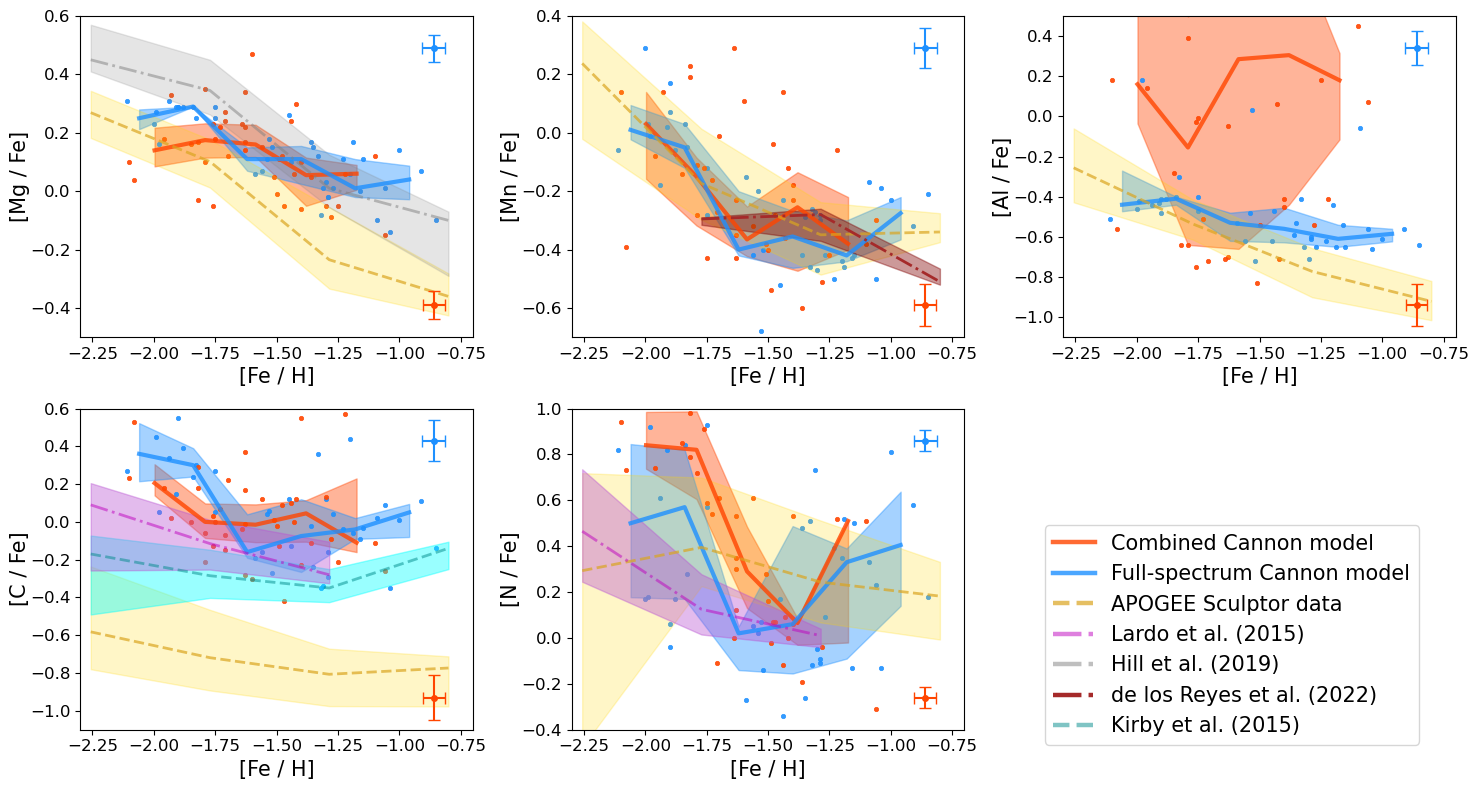

In [133]:
plot_cannon_predictions(scl_dic_combined_model, ['l_mg','l_mn','l_al','l_c','l_n'], final_APOGEE_sculptor_data ,
                        color='orangered',error=rep_unc_scl_combined_model,
                        our_table2 = scl_dic_full_model, color2 = 'dodgerblue',
                        error2=rep_unc_scl_full_model,
                       savefig=True,
                       apogee_track_color='goldenrod',
                       apogee_shade_color='gold')

### Monte Carlo uncertainty estimation of The Cannon labels

Label uncertainties are estimated by generating 10 noise-perturbed realizations of each observed spectrum and re-running The Cannon on each realization. The final uncertainty is defined as the standard deviation of the inferred labels across iterations.

In [156]:
## Creating 'fake' spectra withing the same uncertainty range
def uncertainty_by_iteration(model,n_iterations,
                             flux,sigma_flux,
                            ivar_flux,SNR_array):
    '''
    Estimate label uncertainties from The Cannon via Monte Carlo iterations.
    For each star, this function generates `n_iterations` noise-perturbed
    (fake) spectra based on the flux uncertainties, infers the stellar labels
    using a trained Cannon model, and computes the uncertainties as the
    standard deviation of the inferred labels.
    
    Inputs
    ----------
    model : Trained Cannon model used to infer stellar labels.
    n_iterations : Number of noise realizations per star.
    flux : Input flux spectra.
    sigma_flux : Flux uncertainties for each spectrum.
    ivar_flux : Inverse variance arrays associated with the spectra.
    SNR_array : Signal-to-noise ratio of each input spectrum.

    Returns
    -------
    unc_results : Dictionary containing, for each star, the SNR, inferred label
        uncertainties, predicted labels from all iterations, and metadata.
    '''
    # seed
    rng = np.random.default_rng(22)

    #final dictionary
    unc_results = {}
    
    for idx in range(len(flux)):
        ex_flux = flux[idx]
        ex_flux_err = sigma_flux[idx]
        
        # building 'fake' spectra inside the uncertainty limits
        fake_spectra = []
        for i in range(n_iterations):
            noise = rng.normal(loc=0.0, scale=ex_flux_err) # for each pixel it generates a random number based on the uncertainty in that pix
            fake_flux = ex_flux + noise
            fake_spectra.append(fake_flux)
        fake_spectra = np.array(fake_spectra)
    
        
        # Running The Cannon to infer the labels of these fake spectra
        ex_ivar_telluric = ivar_flux[idx]
        params_ex = model.test(fake_spectra,np.array([ex_ivar_telluric]*n_iterations))  #repiting the ivar_array of the original star (times n_iterarions)
        ex_predicted_labels, ex_cov, ex_metadata = params_ex
        
        # Computing uncertainties (std of each column,i.e., label)
        uncertainties = np.std(ex_predicted_labels, axis=0)
        
        # Keeping the results
        unc_results[idx] = {"SNR": SNR_array[idx],
                            "uncertainties": uncertainties,
                            "labels": ex_predicted_labels,
                           "metadata":ex_metadata}

    return unc_results


def runmed_stat(x,y,window_size,gaussian_smooth=False):
    from scipy.signal import medfilt

    # window size 
    window = window_size
    
    # sorting by x
    idx = np.argsort(x)
    x_sorted = x[idx]
    y_sorted = y[idx]
    
    # here we'll save the median values
    x_med, y_med, y_std = [], [], []
    
    # Calculating the median and dispersion en each window
    for i in range(len(x_sorted)):
        # limits for the window
        low = max(0, i - window // 2)
        high = min(len(x_sorted), i + window // 2)
        
        # Taking the values corresponding to each window
        y_window = y_sorted[low:high]
        
        # Saving statistics
        x_med.append(x_sorted[i])
        y_med.append(np.median(y_window))
        #y_std.append(np.std(y_window))                          # dispersion of the data
        y_std.append(np.std(y_window)/(len(y_window)-1)**0.5)  #uncertainty of the median
    
    x_med = np.array(x_med)
    y_med = np.array(y_med)
    y_std = np.array(y_std)

    if gaussian_smooth:
        from scipy.ndimage import gaussian_filter1d
        y_med = gaussian_filter1d(y_med, sigma=2)

    return x_med , y_med , y_std 


def uncertainty_by_iteration_plot(unc_results,
                                  nw = 27,  #moving window size
                                  gaussian_smoothing=True,
                                 colors_list = ['salmon','gold','cyan','purple','pink' , 'dodgerblue'],
                                 styles = ['-','-','--','--'], hatches = ['..','','','//'],
                                 savefig=False,
                                 size_width=8,
                                 size_long=10,
                                 snr_line=25):

    ## Recovering uncertainties:
    snr_all = np.array([res["SNR"] for res in unc_results.values()])
    unc_all = np.array([res["uncertainties"] for res in unc_results.values()])

    teff_unc_all = unc_all[:,0]
    logg_unc_all = unc_all[:,1]
    feh_unc_all  = unc_all[:,4]
    mg_unc_all   = unc_all[:,5]
    mn_unc_all   = unc_all[:,6]
    al_unc_all   = unc_all[:,7]
    c_unc_all   = unc_all[:,8]
    n_unc_all   = unc_all[:,9]


    ## Running median per label:
    x_snr , y_teff , y_teff_std = runmed_stat(x=np.array(snr_all),y= np.array(teff_unc_all),
                                        window_size =  nw, gaussian_smooth=gaussian_smoothing)
    
    _____ , y_logg , y_logg_std = runmed_stat(x=np.array(snr_all),y= np.array(logg_unc_all),
                                        window_size =  nw,gaussian_smooth=gaussian_smoothing)
    
    _____ , y_feh , y_feh_std = runmed_stat(x=np.array(snr_all),y= np.array(feh_unc_all),
                                        window_size =  nw,gaussian_smooth=gaussian_smoothing)
    
    _____ , y_mg , y_mg_std = runmed_stat(x=np.array(snr_all),y= np.array(mg_unc_all),
                                        window_size =  nw,gaussian_smooth=gaussian_smoothing)
    
    _____ , y_mn , y_mn_std = runmed_stat(x=np.array(snr_all),y= np.array(mn_unc_all),
                                        window_size =  nw,gaussian_smooth=gaussian_smoothing)
    
    _____ , y_al , y_al_std = runmed_stat(x=np.array(snr_all),y= np.array(al_unc_all),
                                        window_size =  nw,gaussian_smooth=gaussian_smoothing)
    
    _____ , y_c , y_c_std = runmed_stat(x=np.array(snr_all),y= np.array(c_unc_all),
                                        window_size =  nw,gaussian_smooth=gaussian_smoothing)
    
    _____ , y_n , y_n_std = runmed_stat(x=np.array(snr_all),y= np.array(n_unc_all),
                                        window_size =  nw,gaussian_smooth=gaussian_smoothing)

    
    abundances_dic = {
                  r'$\ell_{[Mn/Fe]}$':[y_mn , y_mn_std],
                  #r'$\ell_{[Al/Fe]}$':[y_al , y_al_std],
                  r'$\ell_{[C/Fe]}$':[y_c , y_c_std],
                  r'$\ell_{[N/Fe]}$':[y_n , y_n_std],
                 r'$\ell_{[Mg/Fe]}$':[y_mg , y_mg_std]
                 }


    ## Plot
    fig, (ax1, ax2, ax3) = plt.subplots(3, 1, figsize=(size_width,size_long), sharex=True, 
                               #gridspec_kw={'width_ratios': [3, 1]}    
                              )

    # -------- Teff vs SNR --------
    ax1.plot(x_snr, y_teff, color='k',lw=2)
    ax1.fill_between(x_snr, y_teff - y_teff_std, y_teff + y_teff_std, color='k', alpha=0.3)
    ax1.set_ylabel(r'$\sigma_\text{Teff}$',fontsize=20)
    ax1.tick_params(labelsize=15)
    ax1.set_ylim(0,100)
    ax1.axvline(snr_line,color='grey',lw=3,alpha=0.5,ls='--')
    #ax1.annotate('a)',(14.6,-33.38),fontsize=20)
    
    # -------- Logg/[Fe/H] vs SNR --------
    ax2.plot(x_snr, y_logg, color='k',lw=2,label=r'$\ell_{logg}$')
    ax2.fill_between(x_snr, y_logg - y_logg_std, y_logg + y_logg_std, color='k', alpha=0.3)
    ax2.plot(x_snr, y_feh, color='k',lw=2,ls='-.',label=r'$\ell_{[Fe/H]}$')
    ax2.fill_between(x_snr, y_feh - y_feh_std, y_feh + y_feh_std, color='k', alpha=0.3)
    #ax2.set_ylabel(r'$\sigma_\text{logg}$',fontsize=20)
    ax2.set_ylabel(r'$\sigma_\ell$',fontsize=20)
    ax2.tick_params(labelsize=15)
    ax2.set_ylim(0,0.35)
    ax2.legend(fontsize=13,loc='upper right')
    ax2.axvline(snr_line,color='grey',lw=3,alpha=0.5,ls='--')
    #ax2.annotate('a)',(14.6,-33.38),fontsize=20)
    
    # -------- [X/Fe] vs SNR --------
    for i,k in enumerate(abundances_dic.keys()):
        #for very tiny colors:
        clist = ['yellow','gold']
        if colors_list[i] in clist: alph = 0.7
        else: alph = 0.5
        
        if k != '$\\ell_{[Al/Fe]}$' or k != '$\\ell_{[Fe/H]}$':
                ax3.plot(x_snr, abundances_dic[k][0], color='k', lw=3, zorder=1)
                ax3.plot(x_snr, abundances_dic[k][0], color=colors_list[i],lw=2,ls=styles[i])
                ax3.fill_between(x_snr, abundances_dic[k][0] - abundances_dic[k][1], abundances_dic[k][0] + abundances_dic[k][1],
                                 color=colors_list[i], alpha=alph,label=k,hatch=hatches[i], edgecolor='k',linewidth=0.0)
                ax3.set_ylabel(r'$\sigma_\ell$',fontsize=20)
                ax3.set_xlabel('SNR',fontsize=20)
                ax3.tick_params(labelsize=15)
                ax3.legend(fontsize=13,loc='upper right',ncol=2)
                ax3.set_ylim(0,0.5)
                ax3.set_xlim(10,50)
    ax3.axvline(snr_line,color='grey',lw=3,alpha=0.5,ls='--')
        #ax3.annotate('a)',(14.6,-33.38),fontsize=20)
    
    plt.tight_layout()
    if savefig:
        figures_path = Path("figures")
        figures_path.mkdir(exist_ok=True)
        plt.savefig(f'figures/thecannon_scatter_uncertainty'+'.png',dpi=300,bbox_inches='tight')
    plt.show()

    stat = np.array([y_teff , y_teff_std , y_logg , y_logg_std , y_feh , y_feh_std,
                  y_mg , y_mg_std , y_mn , y_mn_std , y_al , y_al_std , y_c , y_c_std , y_n , y_n_std])
    return(stat)


def uncertainty_stats_table_2bins(unc_results,low_thr=25, high_thr=25):
    """
    unc_results : dict. returned by uncertainty_by_iteration() function
    low_thr : límite superior del bin bajo (SNR < low_thr)
    high_thr : límite inferior del bin alto (SNR > high_thr)
    """

    ## Recovering uncertainties:
    snr_all = np.array([res["SNR"] for res in unc_results.values()])
    unc_all = np.array([res["uncertainties"] for res in unc_results.values()])

    teff_unc_all = unc_all[:,0]
    logg_unc_all = unc_all[:,1]
    feh_unc_all  = unc_all[:,4]
    mg_unc_all   = unc_all[:,5]
    mn_unc_all   = unc_all[:,6]
    al_unc_all   = unc_all[:,7]
    c_unc_all   = unc_all[:,8]
    n_unc_all   = unc_all[:,9]

    labels_dict = {
    'Teff': teff_unc_all,
    'logg': logg_unc_all,
    'Fe/H': feh_unc_all,
    'Mg': mg_unc_all,
    'Mn': mn_unc_all,
    'Al': al_unc_all,
    'C': c_unc_all,
    'N': n_unc_all}
    

    snr = np.array(snr_all)
    mask_low = snr < low_thr
    mask_high = snr > high_thr

    rows = []

    for label, arr in labels_dict.items():
        arr = np.array(arr)

        # statistics
        med_low = np.median(arr[mask_low])
        p16_low = np.percentile(arr[mask_low], 16)
        p84_low = np.percentile(arr[mask_low], 84)

        med_high = np.median(arr[mask_high])
        p16_high = np.percentile(arr[mask_high], 16)
        p84_high = np.percentile(arr[mask_high], 84)

        # relative variation
        variation = med_low / med_high if med_high != 0 else np.nan   #if low/high
        

        # special formating for showing it in the table
        low_str = f"{med_low:.3f} (+{p84_low-med_low:.3f}/-{med_low-p16_low:.3f})"
        high_str = f"{med_high:.3f} (+{p84_high-med_high:.3f}/-{med_high-p16_high:.3f})"

        rows.append([label, low_str, high_str, variation])

    # tabla final
    df = pd.DataFrame(rows, columns=["Label", f"SNR < {low_thr}", f"SNR > {high_thr}", "Variation (low/high)"])
    return df


def uncertainty_stats_table_3bins(unc_results,low_thr=25, high_thr=35):
    """
    unc_results : dict. returned by uncertainty_by_iteration() function
    low_thr : límite para bin bajo (SNR < low_thr)
    high_thr : límite para bin alto (SNR > high_thr)
    """
    ## Recovering uncertainties:
    snr_all = np.array([res["SNR"] for res in unc_results.values()])
    unc_all = np.array([res["uncertainties"] for res in unc_results.values()])

    teff_unc_all = unc_all[:,0]
    logg_unc_all = unc_all[:,1]
    feh_unc_all  = unc_all[:,4]
    mg_unc_all   = unc_all[:,5]
    mn_unc_all   = unc_all[:,6]
    al_unc_all   = unc_all[:,7]
    c_unc_all   = unc_all[:,8]
    n_unc_all   = unc_all[:,9]

    labels_dict = {
    'Teff': teff_unc_all,
    'logg': logg_unc_all,
    'Fe/H': feh_unc_all,
    'Mg': mg_unc_all,
    'Mn': mn_unc_all,
    'Al': al_unc_all,
    'C': c_unc_all,
    'N': n_unc_all}
    

    snr = np.array(snr_all)

    mask_low  = snr < low_thr
    mask_mid  = (snr >= low_thr) & (snr <= high_thr)
    mask_high = snr > high_thr

    rows = []

    def stats_string(arr, mask):
        """Devuelve string tipo 'med (+up/-down)' """
        med = np.median(arr[mask])
        p16 = np.percentile(arr[mask], 16)
        p84 = np.percentile(arr[mask], 84)
        up = p84 - med
        down = med - p16
        return f"{med:.3f} (+{up:.3f}/-{down:.3f})", med

    for label, arr in labels_dict.items():
        arr = np.array(arr)

        low_str, low_med   = stats_string(arr, mask_low)
        mid_str, mid_med   = stats_string(arr, mask_mid)
        high_str, high_med = stats_string(arr, mask_high)

        variation = low_med / high_med if high_med != 0 else np.nan   #if low/high

        rows.append([label, low_str, mid_str, high_str, variation])

    df = pd.DataFrame(rows, 
                      columns=["Label", 
                               f"SNR < {low_thr}", 
                               f"{low_thr} < SNR < {high_thr}", 
                               f"SNR > {high_thr}",
                               "Variation (low/high)"])
    return df

In [149]:
unc_results_combined = uncertainty_by_iteration(combined_model,
                                                10,
                                                scl_final_Flux_all,
                                                scl_final_Sigma_all,
                                                scl_final_IVAR_all_telluric, #scl_final_IVAR_all if full or abs models
                                                scl_SNR[scl_SNR_mask]  #snr of the selected sculptor sample  
                                               )

stty: stdin isn't a terminal
2026-04-05 08:55:11,408 [DEBUG] Couldn't get screen size. Progressbar may look odd.
2026-04-05 08:55:11,410 [INFO] Running test step on 10 spectra


[==========                                                                                          ] 100% (1s)                            


stty: stdin isn't a terminal
2026-04-05 08:55:12,232 [DEBUG] Couldn't get screen size. Progressbar may look odd.
2026-04-05 08:55:12,232 [INFO] Running test step on 10 spectra


[==========                                                                                          ] 100% (2s)                            


stty: stdin isn't a terminal
2026-04-05 08:55:14,105 [DEBUG] Couldn't get screen size. Progressbar may look odd.
2026-04-05 08:55:14,105 [INFO] Running test step on 10 spectra


...

[==========                                                                                          ] 100% (1s)                            


stty: stdin isn't a terminal
2026-04-05 08:55:54,165 [DEBUG] Couldn't get screen size. Progressbar may look odd.
2026-04-05 08:55:54,166 [INFO] Running test step on 10 spectra


[==========                                                                                          ] 100% (1s)                            


stty: stdin isn't a terminal
2026-04-05 08:55:54,785 [DEBUG] Couldn't get screen size. Progressbar may look odd.
2026-04-05 08:55:54,786 [INFO] Running test step on 10 spectra


[==========                                                                                          ] 100% (1s)                            


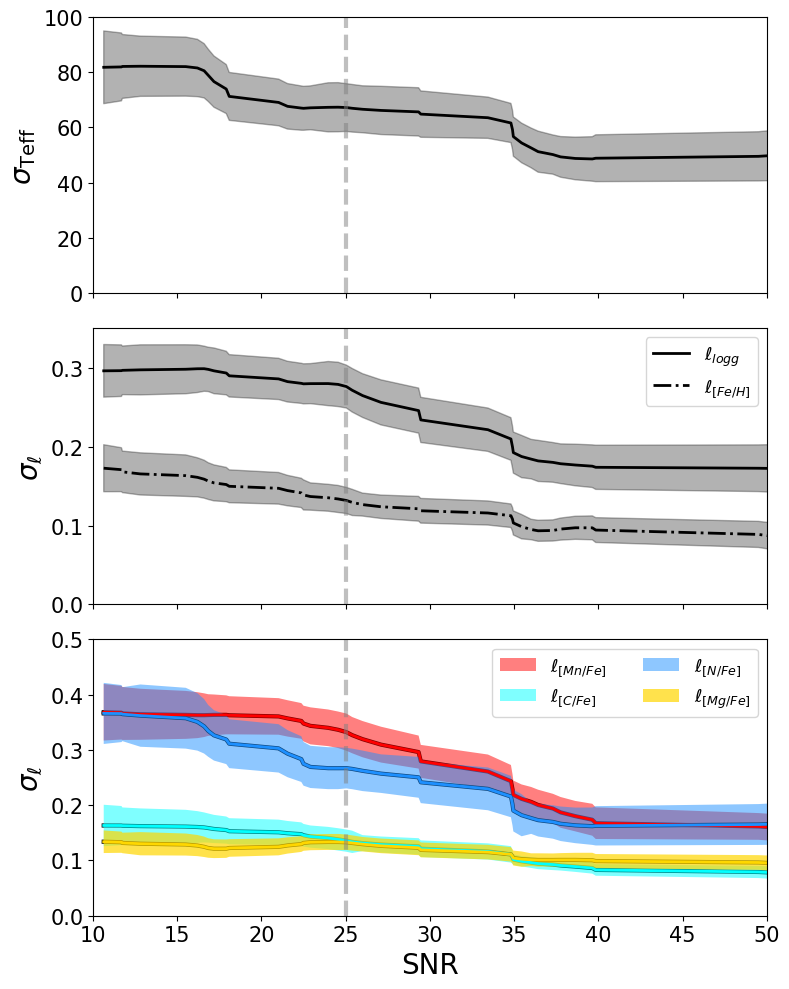

In [151]:
unc_stats_combined_model = uncertainty_by_iteration_plot(unc_results_combined,
                                                   colors_list = ['r','cyan','dodgerblue','gold' ],
                                                   styles=['-','-','-','-'],
                                                   hatches = ['','','',''],
                                                   savefig=True,
                                                   size_width=8,
                                                    size_long=10)

In [158]:
## Tables of uncertainties

df_stats2bins = uncertainty_stats_table_2bins(unc_results_combined,low_thr=25, high_thr=25)
df_stats2bins

,Label,SNR < 25,SNR > 25,Variation (low/high)
0,Teff,85.267 (+46.690/-36.897),50.411 (+28.967/-14.602),1.691424
1,logg,0.300 (+0.147/-0.081),0.181 (+0.111/-0.074),1.653327
2,Fe/H,0.171 (+0.115/-0.102),0.085 (+0.081/-0.038),2.010142
3,Mg,0.133 (+0.090/-0.043),0.099 (+0.051/-0.044),1.339624
4,Mn,0.365 (+0.158/-0.238),0.196 (+0.176/-0.085),1.858019
5,Al,0.625 (+0.372/-0.324),0.685 (+0.269/-0.357),0.913082
6,C,0.160 (+0.163/-0.043),0.092 (+0.051/-0.039),1.739708
7,N,0.353 (+0.254/-0.149),0.173 (+0.157/-0.092),2.047631


In [160]:
df_stats3bins = uncertainty_stats_table_3bins(unc_results_combined,low_thr=25, high_thr=35)
df_stats3bins

,Label,SNR < 25,25 < SNR < 35,SNR > 35,Variation (low/high)
0,Teff,85.267 (+46.690/-36.897),51.533 (+22.369/-8.424),50.411 (+42.484/-22.874),1.691424
1,logg,0.300 (+0.147/-0.081),0.189 (+0.105/-0.044),0.169 (+0.078/-0.071),1.774345
2,Fe/H,0.171 (+0.115/-0.102),0.116 (+0.032/-0.051),0.056 (+0.123/-0.016),3.058797
3,Mg,0.133 (+0.090/-0.043),0.127 (+0.063/-0.036),0.077 (+0.046/-0.038),1.726661
4,Mn,0.365 (+0.158/-0.238),0.290 (+0.122/-0.138),0.147 (+0.110/-0.039),2.483341
5,Al,0.625 (+0.372/-0.324),0.721 (+0.161/-0.229),0.640 (+0.347/-0.408),0.976321
6,C,0.160 (+0.163/-0.043),0.112 (+0.057/-0.021),0.070 (+0.049/-0.028),2.283211
7,N,0.353 (+0.254/-0.149),0.177 (+0.142/-0.066),0.108 (+0.231/-0.029),3.261622


### Ra-dec

In [288]:
from astropy.coordinates import SkyCoord
import astropy.units as u

# Importing literature data

# kirby et al (2015)
kirby15_scl_table = Table.read(f'{sculptor_data_path}/Sculptor_DEIMOS_kirby2015.fit')
mask_kirby15_sculptor = [syst.startswith('S') for syst in kirby15_scl_table['Syst']]
kirby15_scl_table = kirby15_scl_table[mask_kirby15_sculptor]
kirby15_coords = SkyCoord(ra=kirby15_scl_table['RAJ2000'], dec=kirby15_scl_table['DEJ2000'], unit=(u.hourangle, u.deg)) #from hours/minutes/seconds to degrees
kirby15_RA = kirby15_coords.ra.deg  
kirby15_DEC = kirby15_coords.dec.deg


# Lardo et al 2016 data
lardo16_table1 = pd.read_csv(f'{sculptor_data_path}/Sculptor_VLT_Lardo2016_1_2ndversion.csv',sep='\t',skiprows=[1])
lardo16_table2 = pd.read_csv(f'{sculptor_data_path}/Sculptor_VLT_Lardo2016_2.csv',skiprows=[1,2,3])
# replacing dash symbol by minus symbol in DEC array:
lardo16_dec = [s.replace("–", "-").replace("−", "-") for s in lardo16_table1['Dec']]
lardo16_coords = SkyCoord(ra=lardo16_table1['RA'], dec=lardo16_dec, unit=(u.hourangle, u.deg)) #from hours/minutes/seconds to degrees
lardo16_RA = lardo16_coords.ra.deg   
lardo16_DEC = lardo16_coords.dec.deg


# Hill et al. (2019)  
hill19_selected = Table.read(f'{sculptor_data_path}/Sculptor_VLT_Hill2019.fit')  #table that I used to get the Mg estimations (99 stars)
hill19_full = Table.read(f'{sculptor_data_path}/Sculptor_Hilli2019_table1.fit')  #second table that I get from vizier (129 stars)
hill19_scl_table = join(hill19_selected, hill19_full, keys='Star', join_type='inner')
hill19_coords = SkyCoord(ra=hill19_scl_table['RAJ2000'], dec=hill19_scl_table['DEJ2000'], unit=(u.hourangle, u.deg))  #from hours/minutes/seconds to degrees
hill19_RA = hill19_coords.ra.deg 
hill19_DEC = hill19_coords.dec.deg


# Chiti et al. (2018) 
chiti18_scl_table = Table.read(f'{sculptor_data_path}/Sculptor_Chiti2018_table5.fit')
chiti18_RA = Table.read(f'{sculptor_data_path}/Sculptor_Chiti2018_table5.fit')['RAJ2000']   #degree
chiti18_DEC = Table.read(f'{sculptor_data_path}/Sculptor_Chiti2018_table5.fit')['DEJ2000']
chiti18_coords = SkyCoord(ra=chiti18_RA, dec=chiti18_DEC)

# de los Reyes et al. (2022)
reyes22_scl_table = Table.read(f'{sculptor_data_path}/Sculptor_delosReyes2022_table1.fit')
reyes22_coords = SkyCoord(ra=reyes22_scl_table['RAJ2000'], dec=reyes22_scl_table['DEJ2000'], unit=(u.hourangle, u.deg)) 
reyes22_RA = reyes22_coords.ra.deg 
reyes22_DEC = reyes22_coords.dec.deg 

# Skuladottir et al. (2015)
skuladottir15_scl_table = Table.read(f'{sculptor_data_path}/Sculptor_Skuladottir2015_table1.fit')
skuladottir15_coords = SkyCoord(ra=skuladottir15_scl_table['RAJ2000'], dec=skuladottir15_scl_table['DEJ2000'], unit=(u.hourangle, u.deg))
skuladottir15_RA = skuladottir15_coords.ra.deg 
skuladottir15_DEC = skuladottir15_coords.dec.deg 

# Skuladottir et al. (2017)
skuladottir17_scl_table2 = Table.read(f'{sculptor_data_path}/Sculptor_Skuladottir2017_table2.fit')
skuladottir17_scl_table3 = Table.read(f'{sculptor_data_path}/Sculptor_Skuladottir2017_table3.fit')
skuladottir17_scl_table = join(skuladottir17_scl_table2, skuladottir17_scl_table3, keys='Star', join_type='inner')
skuladottir17_RA = skuladottir17_scl_table['_RA']
skuladottir17_DEC = skuladottir17_scl_table['_DE']
skuladottir17_coords = SkyCoord(ra=skuladottir17_RA, dec=skuladottir17_DEC)

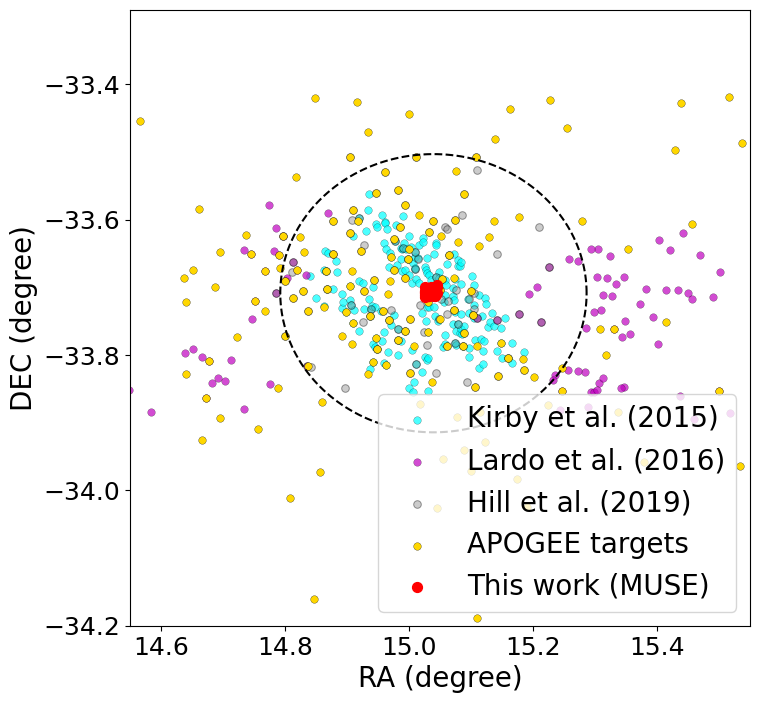

In [425]:
# --- parameters from Muñoz+2018 ---
ra0 = 15.03917                 # Ra of the center  from SIMBAD: https://simbad.cds.unistra.fr/simbad/sim-basic?Ident=Sculptor+Dwarf+Galaxy&submit=SIMBAD+search
dec0 = -33.7088                # Dec of the center, c = SkyCoord("01 00 09.4 -33 42 32", unit=(u.hourangle, u.deg), frame='icrs').dec.deg
re_arcmin = 12.33              # Effective radius (in arcmin), which contains half the total luminosity
re_deg = re_arcmin / 60.0      # Effective radius (in degs)
theta = np.linspace(0, 2*np.pi, 200)
ra_circle  = ra0 + re_deg * np.cos(theta) / np.cos(np.deg2rad(dec0))  
dec_circle = dec0 + re_deg * np.sin(theta)


fig, ax = plt.subplots(figsize=(8,8))

ax.plot(ra_circle, dec_circle, 'k--')

#ax.scatter(reyes22_RA ,reyes22_DEC,
#           label = 'de los Reyes et al. (2022)',color='blue',s=10,edgecolor='black',lw=0.1,alpha=0.6)

ax.scatter(kirby15_RA,kirby15_DEC,
           label=f'Kirby et al. (2015)',color='cyan',s=30,edgecolor='black',lw=0.2,alpha=0.7)

ax.scatter(lardo16_RA,lardo16_DEC,
           label=f'Lardo et al. (2016)',color='m',s=30,edgecolor='black',lw=0.2,alpha=0.7)

#ax.scatter(skuladottir15_RA ,skuladottir15_DEC,
#           label=f'Skuladottir et al. (2015,2017)',color='lime',s=30,edgecolor='black',lw=0.3,alpha=0.9)
#ax.scatter(skuladottir17_RA ,skuladottir17_DEC,
#           color='lime',s=30,edgecolor='black',lw=0.3,alpha=0.4)

ax.scatter(hill19_RA ,hill19_DEC,
           label = 'Hill et al. (2019)',color='grey',s=30,edgecolor='black',lw=0.7,alpha=0.4)

#ax.scatter(chiti18_RA ,chiti18_DEC,
#           label = 'Chiti et al. (2018)',color='violet',s=30,edgecolor='black',lw=0.9,alpha=0.6)

ax.scatter(final_APOGEE_sculptor_data['RA'],final_APOGEE_sculptor_data['DEC'],
           label=f'APOGEE targets',color='gold',s=30,edgecolor='black',lw=0.2)

ax.scatter(scl_dic_combined_model['ra'],scl_dic_combined_model['dec'],
           label=f'This work (MUSE)',color='red',s=50)#,edgecolor='black',lw=0.3,marker='s')

scl_center_ra = 15.03875 #from wiki     #SkyCoord(ra='00:22:48', dec='-30:06.5', unit=(u.hourangle, u.deg)).ra.deg
scl_center_dec = -33.70917 #SkyCoord(ra='00:22:48', dec='-30:06.5', unit=(u.hourangle, u.deg)).dec.deg
#ax.scatter(scl_center_ra,scl_center_dec,s=250,marker='x',color='black',label='Sculptor center',lw=3)

ax.set_ylabel('DEC (degree)',fontsize=20)
ax.set_xlabel('RA (degree)',fontsize=20)
ax.set_ylim(-34.2,-33.29)
ax.set_xlim(14.55,15.55)
ax.tick_params(labelsize=18)
#ax.set_xticks([14.5,15,15.5,16])
plt.legend(fontsize=20)#bbox_to_anchor=(1.3, 0.8))
plt.show()

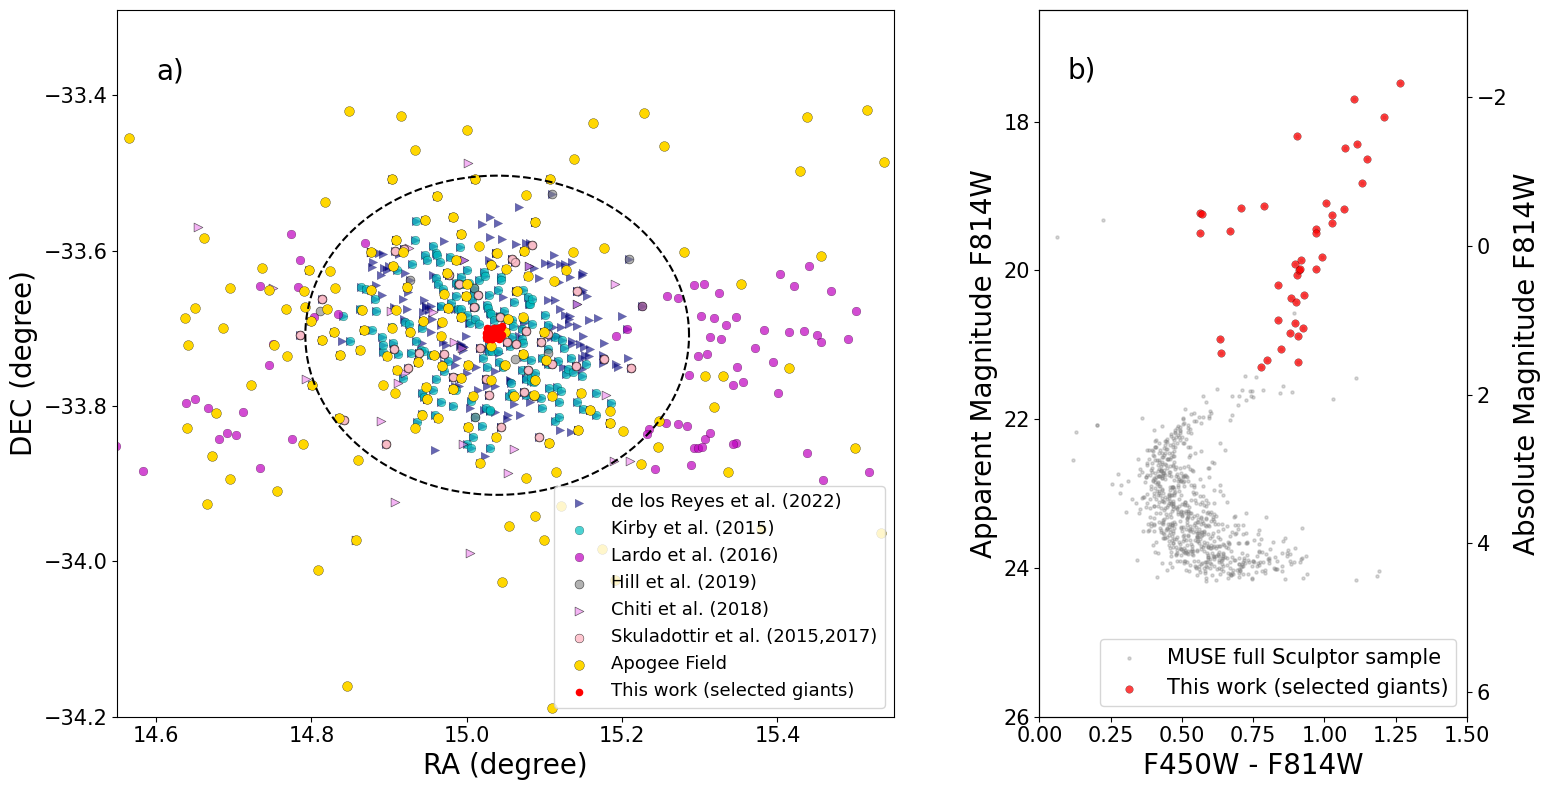

In [330]:
# --- parameters from Muñoz+2018 to draw the effective radii---
ra0 = 15.03917                 # Ra of the center  from SIMBAD: https://simbad.cds.unistra.fr/simbad/sim-basic?Ident=Sculptor+Dwarf+Galaxy&submit=SIMBAD+search
dec0 = -33.7088                # Dec of the center, c = SkyCoord("01 00 09.4 -33 42 32", unit=(u.hourangle, u.deg), frame='icrs').dec.deg
re_arcmin = 12.33              # Effective radius (in arcmin), which contains half the total luminosity
re_deg = re_arcmin / 60.0      # Effective radius (in degs)
theta = np.linspace(0, 2*np.pi, 200)
ra_circle  = ra0 + re_deg * np.cos(theta) / np.cos(np.deg2rad(dec0))  
dec_circle = dec0 + re_deg * np.sin(theta)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16,8), 
                               gridspec_kw={'width_ratios': [2, 1]}    
                              )

# -------- RA-Dec --------
ax1.plot(ra_circle, dec_circle, 'k--')

ax1.scatter(reyes22_RA ,reyes22_DEC,
           label = 'de los Reyes et al. (2022)',color='navy',s=40,edgecolor='black',lw=0.1,alpha=0.6,marker='>')

ax1.scatter(kirby15_RA,kirby15_DEC,
           label=f'Kirby et al. (2015)',color='c',s=40,edgecolor='black',lw=0.2,alpha=0.7)

ax1.scatter(lardo16_RA,lardo16_DEC,
           label=f'Lardo et al. (2016)',color='m',s=40,edgecolor='black',lw=0.2,alpha=0.7)

ax1.scatter(hill19_RA ,hill19_DEC,
           label = 'Hill et al. (2019)',color='gray',s=40,edgecolor='black',lw=0.5,alpha=0.6)#,marker='>')

ax1.scatter(chiti18_RA ,chiti18_DEC,
           label = 'Chiti et al. (2018)',color='violet',s=40,edgecolor='black',lw=0.5,alpha=0.6,marker='>')

ax1.scatter(skuladottir15_RA ,skuladottir15_DEC,
           label=f'Skuladottir et al. (2015,2017)',color='pink',s=40,edgecolor='black',lw=0.3,alpha=0.9)
ax1.scatter(skuladottir17_RA ,skuladottir17_DEC,
           color='pink',s=30,edgecolor='black',lw=0.3,alpha=0.5)


ax1.scatter(final_APOGEE_sculptor_data['RA'],final_APOGEE_sculptor_data['DEC'],
           label=f'Apogee Field',color='gold',s=50,edgecolor='black',lw=0.2)

ax1.scatter(scl_dic_combined_model['ra'],scl_dic_combined_model['dec'],
           label=f'This work (selected giants)',color='red',s=20)#,edgecolor='black',lw=0.3,marker='s')

ax1.set_ylabel('DEC (degree)',fontsize=20)
ax1.set_xlabel('RA (degree)',fontsize=20)
ax1.set_ylim(-34.2,-33.29)
ax1.set_xlim(14.55,15.55)
ax1.set_aspect('equal')
ax1.tick_params(labelsize=15)
ax1.legend(fontsize=13)
ax1.annotate('a)',(14.6,-33.38),fontsize=20)

# --------  CMD -------- considering absolute magnitude
def apparent_to_absolute(m_app, DM, A_lambda=0.0):
    # m_app: apparent magnitude
    # DM: distance modulus (scalar)
    # A_lambda: extinction in that band (same units as mag)
    return m_app - DM - A_lambda

color_scl_full = scl_full_table['m_F450W'] - scl_full_table['m_F814W']
mag_scl_full = scl_full_table['m_F814W']
#distance to sculptor
d_scl = 85900 #pc  #Pietrzy´nski et al. 2008 (cited in https://arxiv.org/pdf/1201.2408)
# distance modulus
DM_scl = 5*np.log10(d_scl/10)  #considering m-M = 5log(d/10)
Mag_scl_full = apparent_to_absolute(mag_scl_full, DM_scl)

mask_color =  (color_scl_full > 0.4) & (color_scl_full < 2)
mask_mag = mag_scl_full < 21.3
rgb_scl_mask = mask_mag & mask_color 

color_scl_selected = scl_full_table['m_F450W'][rgb_scl_mask][scl_SNR_mask] - scl_full_table['m_F814W'][rgb_scl_mask][scl_SNR_mask]
mag_scl_selected = mag_scl_full[rgb_scl_mask][scl_SNR_mask]
Mag_scl_selected = Mag_scl_full[rgb_scl_mask][scl_SNR_mask]

ax2.scatter(color_scl_full, mag_scl_full, s=5, alpha=0.3, label='MUSE full Sculptor sample', color='grey')#,facecolors='none')
ax2.scatter(color_scl_selected, mag_scl_selected, s=30, alpha=0.75, label='This work (selected giants)', color='red',edgecolor='k',lw=0.2)
ax2.invert_yaxis()
ax2.set_xlabel('F450W - F814W', fontsize=20)
ax2.set_ylabel('Apparent Magnitude F814W', fontsize=20)
ax2.tick_params(labelsize=15)
ax2.legend(fontsize=15, loc='lower right')
ax2.set_xlim(0, 1.5)
ax2.set_ylim(26, 16.5)
ax2.annotate('b)', (0.1, 17.42), fontsize=20)

# --- Add secondary Y-axis for absolute magnitude ---
ax2b = ax2.twinx()
ax2b.set_ylabel('Absolute Magnitude F814W', fontsize=20)
ylim_app = ax2.get_ylim()
ax2b.set_ylim(ylim_app[0] - DM_scl, ylim_app[1] - DM_scl)
#ax2b.invert_yaxis()  
ax2b.tick_params(labelsize=15)

plt.subplots_adjust(wspace=1)
plt.tight_layout()
plt.savefig(f'figures/ra_dec_CMD_sculptor'+'.png',dpi=300,bbox_inches='tight')
plt.show()


In [73]:
# looking for overlap between our observations and literature data
muse_scl_coords = SkyCoord(ra=scl_dic_combined_model['ra']*u.deg, dec=scl_dic_combined_model['dec']*u.deg)  #our coords

# compilation of all literature coordinates:
scl_literature_coords = SkyCoord(np.concatenate([
    chiti18_coords,
    hill19_coords,
    lardo16_coords,
    kirby15_coords,
    reyes22_coords,
    skuladottir15_coords,
    skuladottir17_coords
]))

# author names
scl_literature_comp = pd.DataFrame({
    'Author': (['Chiti18']*len(chiti18_coords) + 
               ['Hill19']*len(hill19_coords) +
               ['Lardo16']*len(lardo16_coords) +
               ['Kirby15']*len(kirby15_coords) +
               ['Reyes22']*len(reyes22_coords) +
               ['Skuladottir15']*len(skuladottir15_coords) +
               ['Skuladottir17']*len(skuladottir17_coords))
                })


# cross-match
idx_cat, idx_my, d2d, d3d = scl_literature_coords.search_around_sky(muse_scl_coords, 1*u.arcsec)

# Table with the matched stars
matches = pd.DataFrame({
    'My_index': idx_my,
    'Lit_index': idx_cat,
    'Author': scl_literature_comp['Author'].iloc[idx_cat].values,
    'Separation_arcsec': d2d.arcsec
})


matches 

,My_index,Lit_index,Author,Separation_arcsec


#### logg vs teff

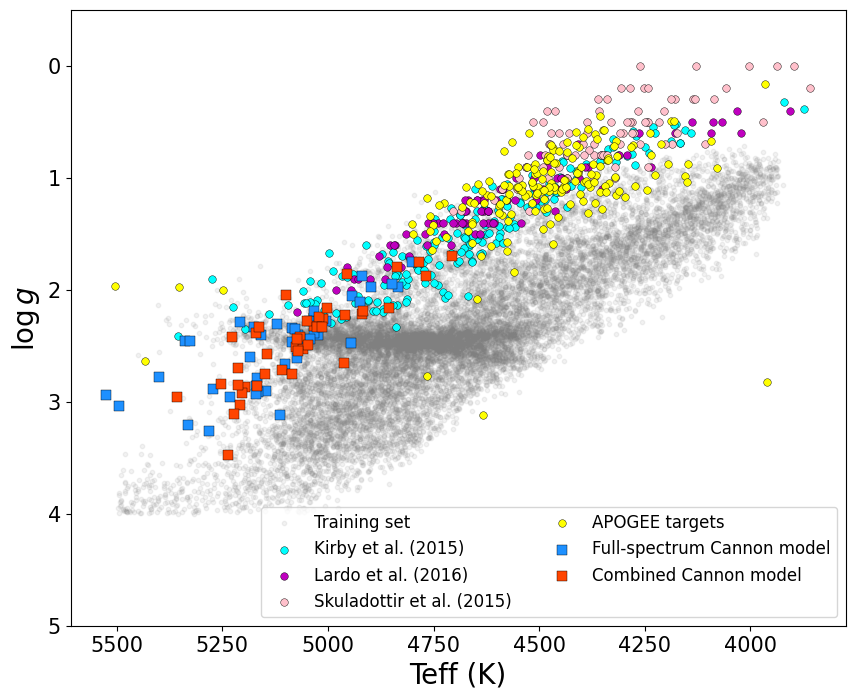

In [74]:
# Importing training set

trainingset_path = f'{data_path}/trainingset_data/training_notscaled_extendedversion.pickle'
file_in = open(trainingset_path, 'rb')
training_spectra, training_metaall, _, _,_ = pickle.load(file_in)

labels = ['TEFF','LOGG','VMICRO','AK_WISE','FE_H','MG_FE','MN_FE','AL_FE','C_FE','N_FE']  #as called in APOGEE

training_labels_extended = Table({label: col for label, col in zip(labels, training_metaall.T)}) 



# Comparing plots of LOGG vs Teff for both galaxies and with literature:

# Sculptor
#kirby et al (2015) data:
kirby_scl_table = Table.read(f'{sculptor_data_path}/Sculptor_DEIMOS_kirby2015.fit')
mask_kirby_sculptor = [syst.startswith('S') for syst in kirby_scl_table['Syst']]
kirby_scl_table = kirby_scl_table[mask_kirby_sculptor]
kirby_teff = kirby_scl_table['Teff']
kirby_logg = kirby_scl_table['log_g_']
kirby_C_Fe = kirby_scl_table['__C_Fe_c']
kirby_RA = kirby_scl_table['RAJ2000']
kirby_DEC = kirby_scl_table['DEJ2000']

#Lardo et al 2015 data
lardo_table1 = pd.read_csv(f'{sculptor_data_path}/Sculptor_VLT_Lardo2016_1_2ndversion.csv',sep='\t',skiprows=[1])
lardo_table2 = pd.read_csv(f'{sculptor_data_path}/Sculptor_VLT_Lardo2016_2.csv',skiprows=[1,2,3])
#fixing '–' and empty spaces
lardo_C_Fe = np.array([float(val.replace('–', '-').replace('−', '-').strip()) for val in lardo_table2['[C/Fe]cor']])
lardo_teff = lardo_table2['T']
lardo_logg = lardo_table2['log (g)']
lardo_RA = lardo_table1['RA']
lardo_DEC = lardo_table1['Dec']
# replacing dash symbol by minus symbol in DEC array:
lardo_DEC = [s.replace("–", "-").replace("−", "-") for s in lardo_DEC]


# tracks for literature results
bins_teff = np.linspace(4000, 5500, 10)
bin_centers_teff = 0.5 * (bins_teff[1:] + bins_teff[:-1])
kirby_med_tefflogg, kirby_q25_tefflogg, kirby_q75_tefflogg = binned_stats(kirby_teff,kirby_logg, bins_teff,min_points = 3)
lardo_med_tefflogg, lardo_q25_tefflogg, lardo_q75_tefflogg = binned_stats(lardo_teff,lardo_logg, bins_teff,min_points = 3)



fig, ax = plt.subplots(figsize=(10,8))
ax.scatter(training_labels_extended['TEFF'], training_labels_extended['LOGG'],
           label=f'Training set', color='grey', s=10, alpha=0.1) #label=f'Training set: {len(training_labels['LOGG'])} stars'

ax.scatter(kirby_teff,kirby_logg,
           label=f'Kirby et al. (2015)',color='cyan',s=30,edgecolor='black',lw=0.3)

ax.scatter(lardo_teff,lardo_logg,
           label=f'Lardo et al. (2016)',color='m',s=30,edgecolor='black',lw=0.3)

#ax.scatter(chiti18_scl_table['Teff'],chiti18_scl_table['log_g_'],
#           label=f'Chiti et al. (2018)',color='lime',s=30,edgecolor='black',lw=0.3)

ax.scatter(skuladottir15_scl_table['Teff'],skuladottir15_scl_table['logg'],
           label=f'Skuladottir et al. (2015)',color='pink',s=30,edgecolor='black',lw=0.3)

ax.scatter(final_APOGEE_sculptor_data['TEFF'],final_APOGEE_sculptor_data['LOGG'],
           label=f'APOGEE targets',color='yellow',s=30,edgecolor='black',lw=0.3)


ax.scatter(scl_dic_full_model['Teff'],scl_dic_full_model['logg'],
           label=f'Full-spectrum Cannon model',color='dodgerblue', #label=f'Full-spectrum model: {len(scl_dic_full_spectrum['logg'])} stars'
           s=60,edgecolor='black',lw=0.3,marker='s')

ax.scatter(scl_dic_combined_model['Teff'],scl_dic_combined_model['logg'],
           label=f'Combined Cannon model',color='orangered', #label=f'Absorption features - Telluric \n aware model: {len(scl_dic['logg'])} stars'
           s=60,edgecolor='black',lw=0.3,marker='s')




ax.set_xlabel('Teff (K)',fontsize=20)
ax.set_ylabel(r'$\log g$',fontsize=20)
ax.invert_xaxis()
ax.invert_yaxis()
ax.set_ylim(5,-0.5)
ax.tick_params(labelsize=15)
ax.legend(loc='lower right',ncol=2,fontsize=12) #ax.legend(bbox_to_anchor=(1.0, 1.05))#
#plt.savefig(f'figures/logg_Teff_extendedmodels'+'.png',dpi=300,bbox_inches='tight')
plt.show()


#### C vs logg

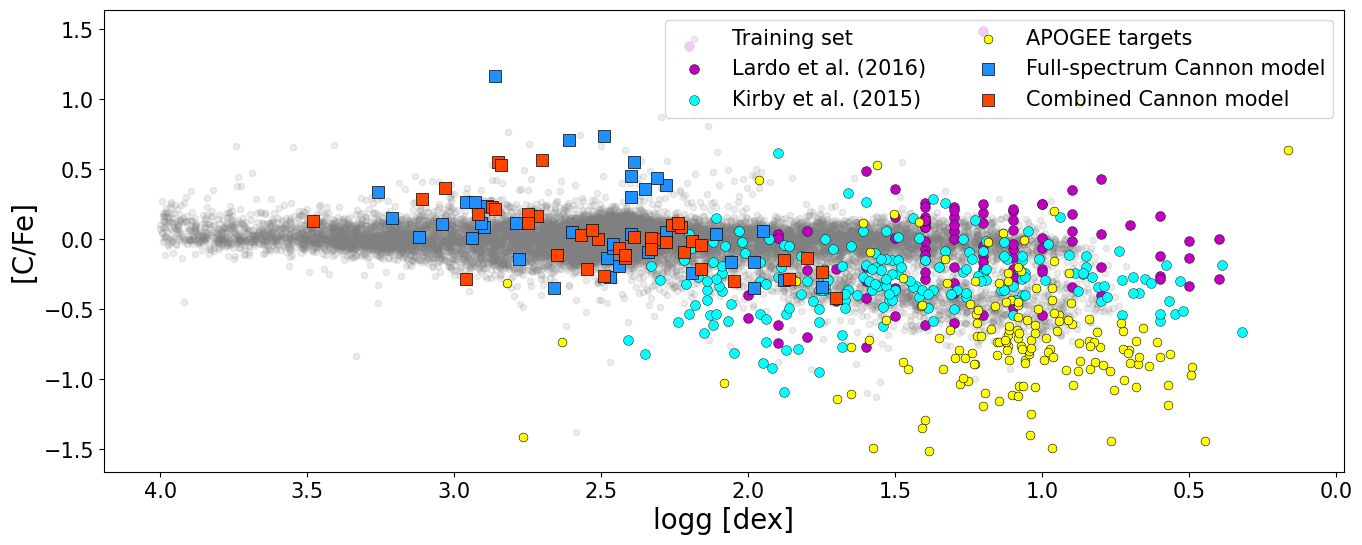

In [75]:
# C abundance vs logg

# tracks for literature results
bins_logg = np.linspace(0.5, 2.5, 8)
bin_centers_logg = 0.5 * (bins_logg[1:] + bins_logg[:-1])
kirby_med_clogg, kirby_q25_clogg, kirby_q75_clogg = binned_stats(kirby_logg, kirby_C_Fe, bins_logg,min_points = 3)
lardo_med_clogg, lardo_q25_clogg, lardo_q75_clogg = binned_stats(lardo_logg, lardo_C_Fe, bins_logg,min_points = 3)


fig, ax = plt.subplots(figsize=(16,6)) #figsize=(15,6)
ax.scatter(training_labels_extended['LOGG'],training_labels_extended['C_FE'],
           label=f'Training set',color='grey', s=20, alpha=0.15)

ax.scatter(lardo_logg, lardo_C_Fe,
           label=f'Lardo et al. (2016)',color='m',s=50,edgecolor='black',lw=0.3)

ax.scatter(kirby_logg, kirby_C_Fe,
           label=f'Kirby et al. (2015)',color='cyan',s=50,edgecolor='black',lw=0.3)

ax.scatter(final_APOGEE_sculptor_data['LOGG'],final_APOGEE_sculptor_data['C_FE'],
           label=f'APOGEE targets',color='yellow',s=40,edgecolor='black',lw=0.4)

ax.scatter(scl_dic_full_model['logg'],scl_dic_full_model['l_c'],
           label=f'Full-spectrum Cannon model',color='dodgerblue',s=70,edgecolor='black',lw=0.5,marker='s')


ax.scatter(scl_dic_combined_model['logg'],scl_dic_combined_model['l_c'],
           label=f'Combined Cannon model',color='orangered',s=70,edgecolor='black',lw=0.5,marker='s')
#ax.set_ylim(-3,3)
ax.set_ylabel('[C/Fe]',fontsize=20)
ax.set_xlabel('logg [dex]',fontsize=20)
ax.tick_params(labelsize=15)
ax.invert_xaxis()
plt.legend(loc='upper right',ncol=2,fontsize=15)#bbox_to_anchor=(1.1, 1.05))
#plt.savefig(f'figures/CFe_logg_extendedmodels'+'.png',dpi=300,bbox_inches='tight')
plt.show()

#### Training set vs sculptor estimations

In [476]:
# Importing training set

trainingset_path = f'{data_path}/trainingset_data/training_notscaled_extendedversion.pickle'
file_in = open(trainingset_path, 'rb')
training_spectra, training_metaall, _, _,_ = pickle.load(file_in)

labels = ['TEFF','LOGG','VMICRO','AK_WISE','FE_H','MG_FE','MN_FE','AL_FE','C_FE','N_FE']  #as called in APOGEE

training_labels_extended = Table({label: col for label, col in zip(labels, training_metaall.T)}) 

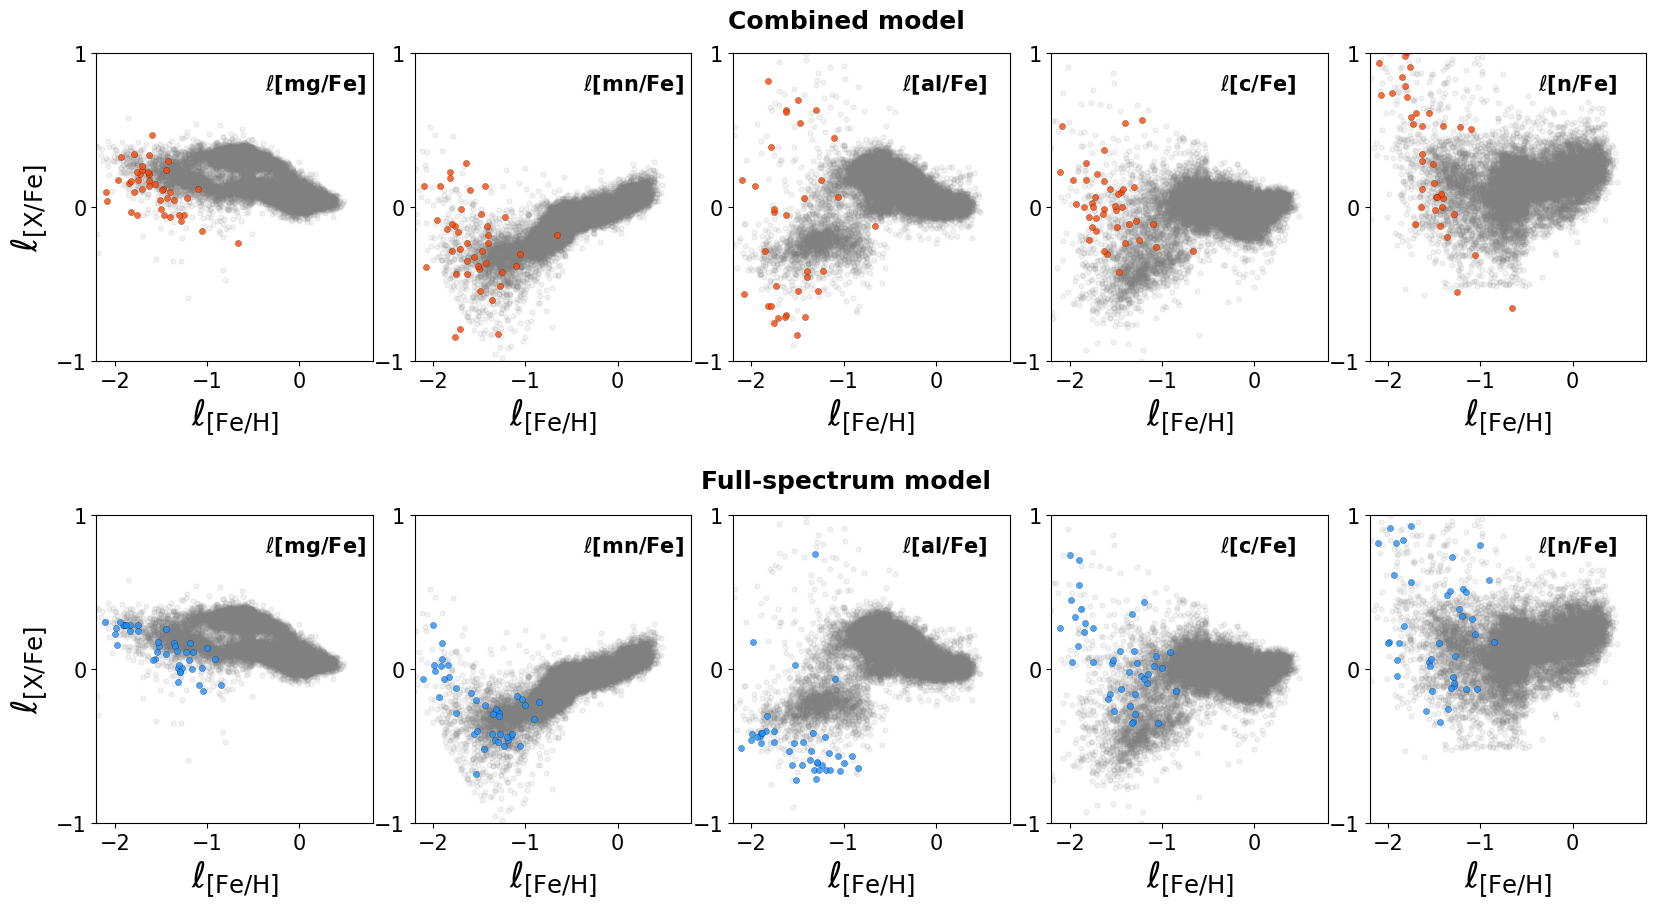

In [481]:
import matplotlib.pyplot as plt
import numpy as np

def plot_cannon_predictions_2models(models, selected_labels, MW_pred_labels, model_names,
                                   colors=['orangered','dodgerblue'],saveplot=False):
    """
    Plots The Cannon predictions vs. true APOGEE labels for multiple models.
    Creates one figure with rows = number of models, columns = number of labels.
    Each row corresponds to one model.
    
    Parameters
    ----------
    models : list of dict
        List of predicted_labels_array dictionaries (one per model).
    selected_labels : list
        List of labels to plot (same for all models).
    MW_pred_labels : dict
        Milky Way training labels (same for all models).
    model_names : list of str
        Names of the models to display above each row.
    """
    apo_labels = {'Teff':'TEFF',
                 'logg': 'LOGG',
                 'vmic':'VMICRO',
                 'Ak':'AK_WISE',
                 'l_feh':'FE_H',
                 'l_mg':'MG_FE',
                 'l_mn':'MN_FE',
                 'l_al':'AL_FE',
                 'l_c':'C_FE',
                 'l_n':'N_FE'}

    nrows = len(models)
    ncols = len(selected_labels)

    fig, axs = plt.subplots(nrows, ncols, figsize=(4*ncols, 5*nrows), squeeze=False)

    for row, (predicted_labels_array, model_name) in enumerate(zip(models, model_names)):
        for col, label in enumerate(selected_labels):
            ax = axs[row, col]

            x = predicted_labels_array['l_feh']
            y = predicted_labels_array[label]

            runmed_x, runmed_y , runmed_std = runmed_stat(x,y,window_size=20,gaussian_smooth=True)

            x_MW = MW_pred_labels['FE_H']
            y_MW = MW_pred_labels[apo_labels[label]]

            # background scatter (MW)
            ax.scatter(x_MW, y_MW, c='grey', s=13, alpha=0.1)
            # model points
            if row==0:
                cc=colors[0]
            elif row ==1:
                cc = colors[1]
            
            ax.scatter(x, y, s=20, alpha=0.8, edgecolor='k', linewidth=0.2,color=cc)
            #ax.plot(runmed_x, runmed_y,color='k',lw=0.5)
            #ax.fill_between(runmed_x , runmed_y - runmed_std , runmed_y + runmed_std,
            #                 color=cc,alpha=0.5,hatch='..')

            # Label name
            ax.text(0.61, 0.88, r'$\ell$'+f"[{label[2:]}/Fe]", transform=ax.transAxes,
                    fontsize=15, weight='bold')

            ax.tick_params(axis='both', which='both', labelsize=15)
            ax.set_xticks([-2,-1,0])
            ax.set_yticks([-1,0,1])

            ax.set_xlabel(r'$\ell_\text{[Fe/H]}$', fontsize=25)
            if col == 0:
                ax.set_ylabel(r'$\ell_\text{[X/Fe]}$', fontsize=25)

            ax.set_xlim(-2.2, 0.8)
            ax.set_ylim(-1, 1)

        # Añadir título centrado arriba de la fila
        if row==0:
            sep = 0.1
        elif row==1:
            sep=0.06
        fig.text(0.5, (nrows - row) / nrows - sep,  # posición vertical
                 model_name, ha='center', va='bottom', 
                 fontsize=18, weight='bold')

    plt.subplots_adjust(wspace=0.15, hspace=0.5)
    if saveplot:
        plt.savefig(f'figures/X_FeH_Sculptor_vs_MW_values'+'.png',dpi=300,bbox_inches='tight')
    plt.show()


plot_cannon_predictions_2models(
    models=[scl_dic_combined_model, scl_dic_full_model],
    selected_labels=['l_mg','l_mn','l_al','l_c','l_n'],
    MW_pred_labels=training_labels_extended,
    model_names=['Combined model', 'Full-spectrum model'],
    saveplot=False
)

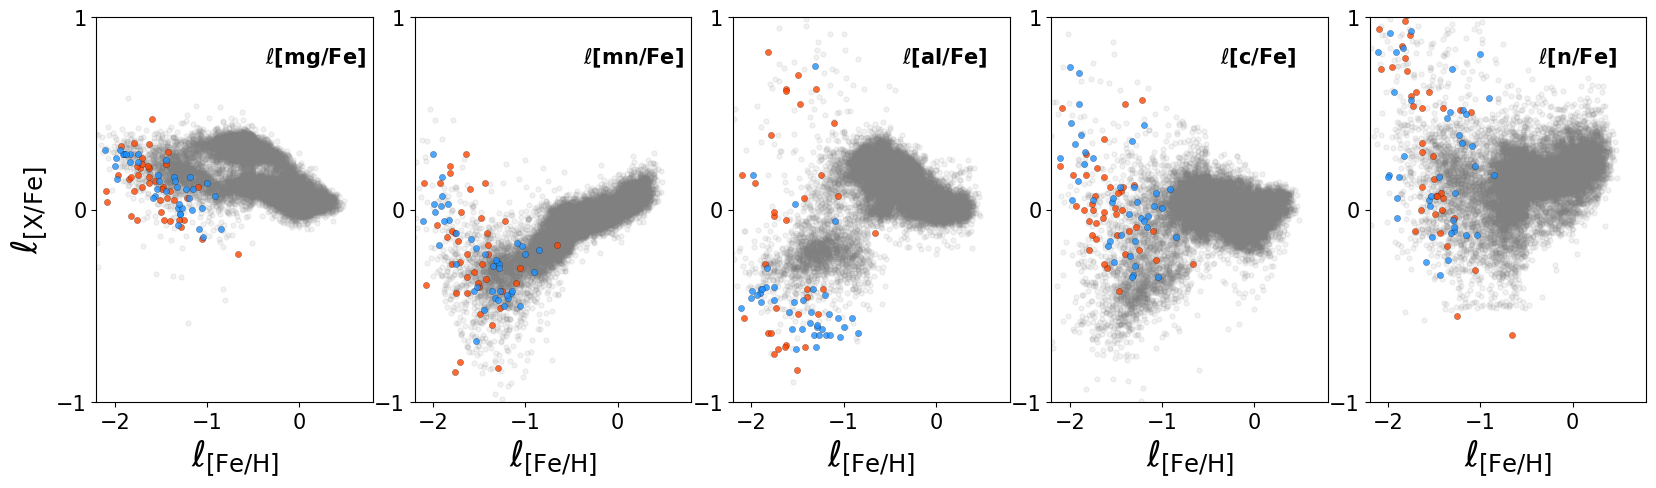

In [109]:
apo_labels = {'Teff':'TEFF',
                 'logg': 'LOGG',
                 'vmic':'VMICRO',
                 'Ak':'AK_WISE',
                 'l_feh':'FE_H',
                 'l_mg':'MG_FE',
                 'l_mn':'MN_FE',
                 'l_al':'AL_FE',
                 'l_c':'C_FE',
                 'l_n':'N_FE'}

selected_labels=['l_mg','l_mn','l_al','l_c','l_n']
MW_pred_labels=training_labels_extended
colors=['orangered','dodgerblue']

fig, axs = plt.subplots(1, 5, figsize=(4*5, 5*1), squeeze=False)

for col, label in enumerate(selected_labels):
        ax = axs[0][col]

        x_combined = scl_dic_combined_model['l_feh']
        y_combined = scl_dic_combined_model[label]

        x_full = scl_dic_full_model['l_feh']
        y_full = scl_dic_full_model[label]

        x_MW = MW_pred_labels['FE_H']
        y_MW = MW_pred_labels[apo_labels[label]]

        # background scatter (MW)
        ax.scatter(x_MW, y_MW, c='grey', s=13, alpha=0.1)

        #combined scatter plot
        ax.scatter(x_combined, y_combined, s=20, alpha=0.8, edgecolor='k', linewidth=0.2,color=colors[0])

        #full scatter plot
        ax.scatter(x_full, y_full, s=20, alpha=0.8, edgecolor='k', linewidth=0.2,color=colors[1])

        # Label name
        ax.text(0.61, 0.88, r'$\ell$'+f"[{label[2:]}/Fe]", transform=ax.transAxes,
                fontsize=15, weight='bold')

        ax.tick_params(axis='both', which='both', labelsize=15)
        ax.set_xticks([-2,-1,0])
        ax.set_yticks([-1,0,1])

        ax.set_xlabel(r'$\ell_\text{[Fe/H]}$', fontsize=25)
        if col == 0:
            ax.set_ylabel(r'$\ell_\text{[X/Fe]}$', fontsize=25)

        ax.set_xlim(-2.2, 0.8)
        ax.set_ylim(-1, 1)

plt.subplots_adjust(wspace=0.15, hspace=0.5)
#if saveplot:
#    plt.savefig(f'figures/X_FeH_Sculptor_vs_MW_values'+'.png',dpi=300,bbox_inches='tight')
plt.show()


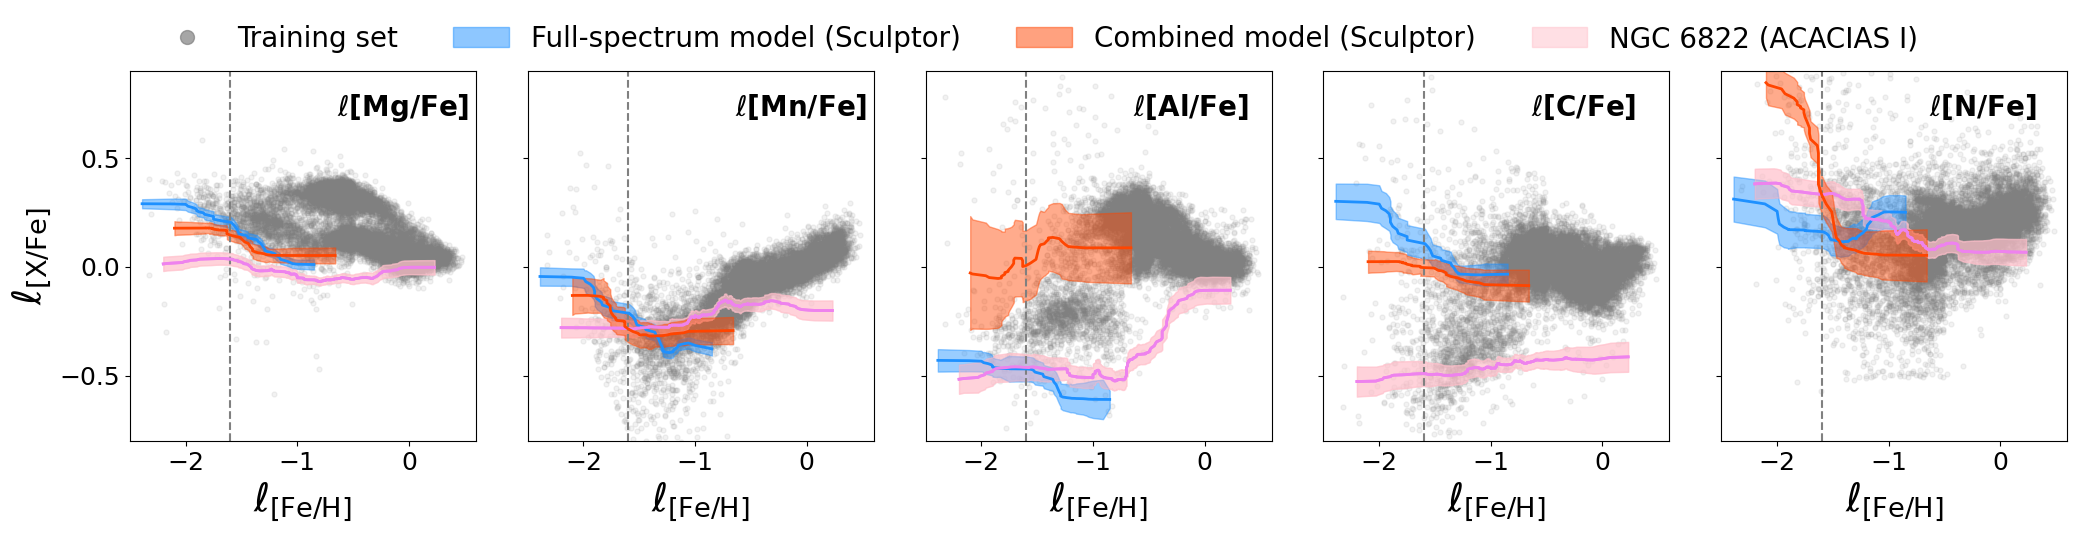

In [483]:
import matplotlib.pyplot as plt
import numpy as np

def plot_cannon_predictions_together(models, selected_labels, MW_pred_labels, model_names,
                                     colors=['dodgerblue','orangered','violet'], saveplot=False):
    """
    Plots The Cannon predictions vs. true APOGEE labels for two models in the SAME panels.
    One figure with 1 row and N columns (N = number of labels).
    Each panel contains:
        - Training set (grey)
        - Combined model prediction (color 1)
        - Full-spectrum model prediction (color 2)
    """
    #NGC6822 table from Ness et al 2025
    NGC6822_melissa_table = Table.read(f'{sculptor_data_path}/ness2024_acacias_ngc6822_labels.fits') #192 stars
    
    apo_labels = {'Teff':'TEFF',
                 'logg': 'LOGG',
                 'vmic':'VMICRO',
                 'Ak':'AK_WISE',
                 'l_feh':'FE_H',
                 'l_mg':'MG_FE',
                 'l_mn':'MN_FE',
                 'l_al':'AL_FE',
                 'l_c':'C_FE',
                 'l_n':'N_FE'}

    ncols = len(selected_labels)
    nrows = 1

    fig, axs = plt.subplots(1, ncols, figsize=(25, 5), squeeze=False,sharey=True)

    axs = axs[0]

    for col, label in enumerate(selected_labels):
        ax = axs[col]

        ax.vlines(-1.6,-0.8, 0.9,color='gray',ls='--')

        # --- TRAINING SET ---
        x_MW = MW_pred_labels['FE_H']
        y_MW = MW_pred_labels[apo_labels[label]]
        ax.scatter(x_MW, y_MW, c='grey', s=13, alpha=0.1)

        # --- PLOT ---
        for i, (predicted_labels_array, model_name) in enumerate(zip(models, model_names)):
            cc = colors[i]

            x = predicted_labels_array['l_feh']
            y = predicted_labels_array[label]

            runmed_x, runmed_y, runmed_std = runmed_stat(x, y, window_size=28, gaussian_smooth=True)
            runmed_mel_x,runmed_mel_y , runmed_mel_std = runmed_stat(NGC6822_melissa_table['l_feh'],
                                                                    NGC6822_melissa_table[label],
                                                                    window_size=80,gaussian_smooth=True)

            ax.plot(runmed_mel_x, runmed_mel_y, color='violet', lw=2)
            ax.fill_between(runmed_mel_x,
                            runmed_mel_y - runmed_mel_std,
                            runmed_mel_y + runmed_mel_std,
                            color=colors[2], alpha=0.45)
            
            ax.plot(runmed_x, runmed_y, color=cc, lw=2)
            ax.fill_between(runmed_x,
                            runmed_y - runmed_std,
                            runmed_y + runmed_std,
                            color=cc, alpha=0.45)

        fancy_label = label[2].upper()+label[3:]
        
        # --- Label del panel ---
        ax.text(0.60, 0.88, r'$\ell$'+f"[{fancy_label}/Fe]", transform=ax.transAxes,
                fontsize=20, weight='bold')

        ax.tick_params(axis='both', which='both', labelsize=18)
        ax.set_xticks([-2, -1, 0])
        

        ax.set_xlabel(r'$\ell_\text{[Fe/H]}$', fontsize=28)
        if col == 0:
            ax.set_ylabel(r'$\ell_\text{[X/Fe]}$', fontsize=28)
            ax.set_yticks([-0.5, 0, 0.5])

        ax.set_xlim(-2.5, 0.6)
        ax.set_ylim(-0.8, 0.9)

    # Legend
    handles = [
        plt.Line2D([0], [0], color='grey', marker='o', linestyle='', markersize=10, alpha=0.7, label='Training set'),
        plt.Rectangle((0,0),1,1, color=colors[0], alpha=0.5, label=model_names[0]),
        plt.Rectangle((0,0),1,1, color=colors[1], alpha=0.5, label=model_names[1]),
        plt.Rectangle((0,0),1,1, color=colors[2], alpha=0.5, label=model_names[2])]
    fig.legend(handles=handles, loc='upper center', ncol=4, fontsize=20, frameon=False)

    plt.subplots_adjust(wspace=0.15, top=0.85)

    if saveplot:
        plt.savefig('figures/XFeH_both_models_runningmed_together.png',
                    dpi=300, bbox_inches='tight')

    plt.show()


plot_cannon_predictions_together(models=[scl_dic_full_model,scl_dic_combined_model],
                                 selected_labels=['l_mg','l_mn','l_al','l_c','l_n'],
                                 MW_pred_labels= training_labels_extended, 
                                 model_names=['Full-spectrum model (Sculptor)','Combined model (Sculptor)','NGC 6822 (ACACIAS I)'],
                                 colors=['dodgerblue','orangered','pink'],
                                 saveplot = False)

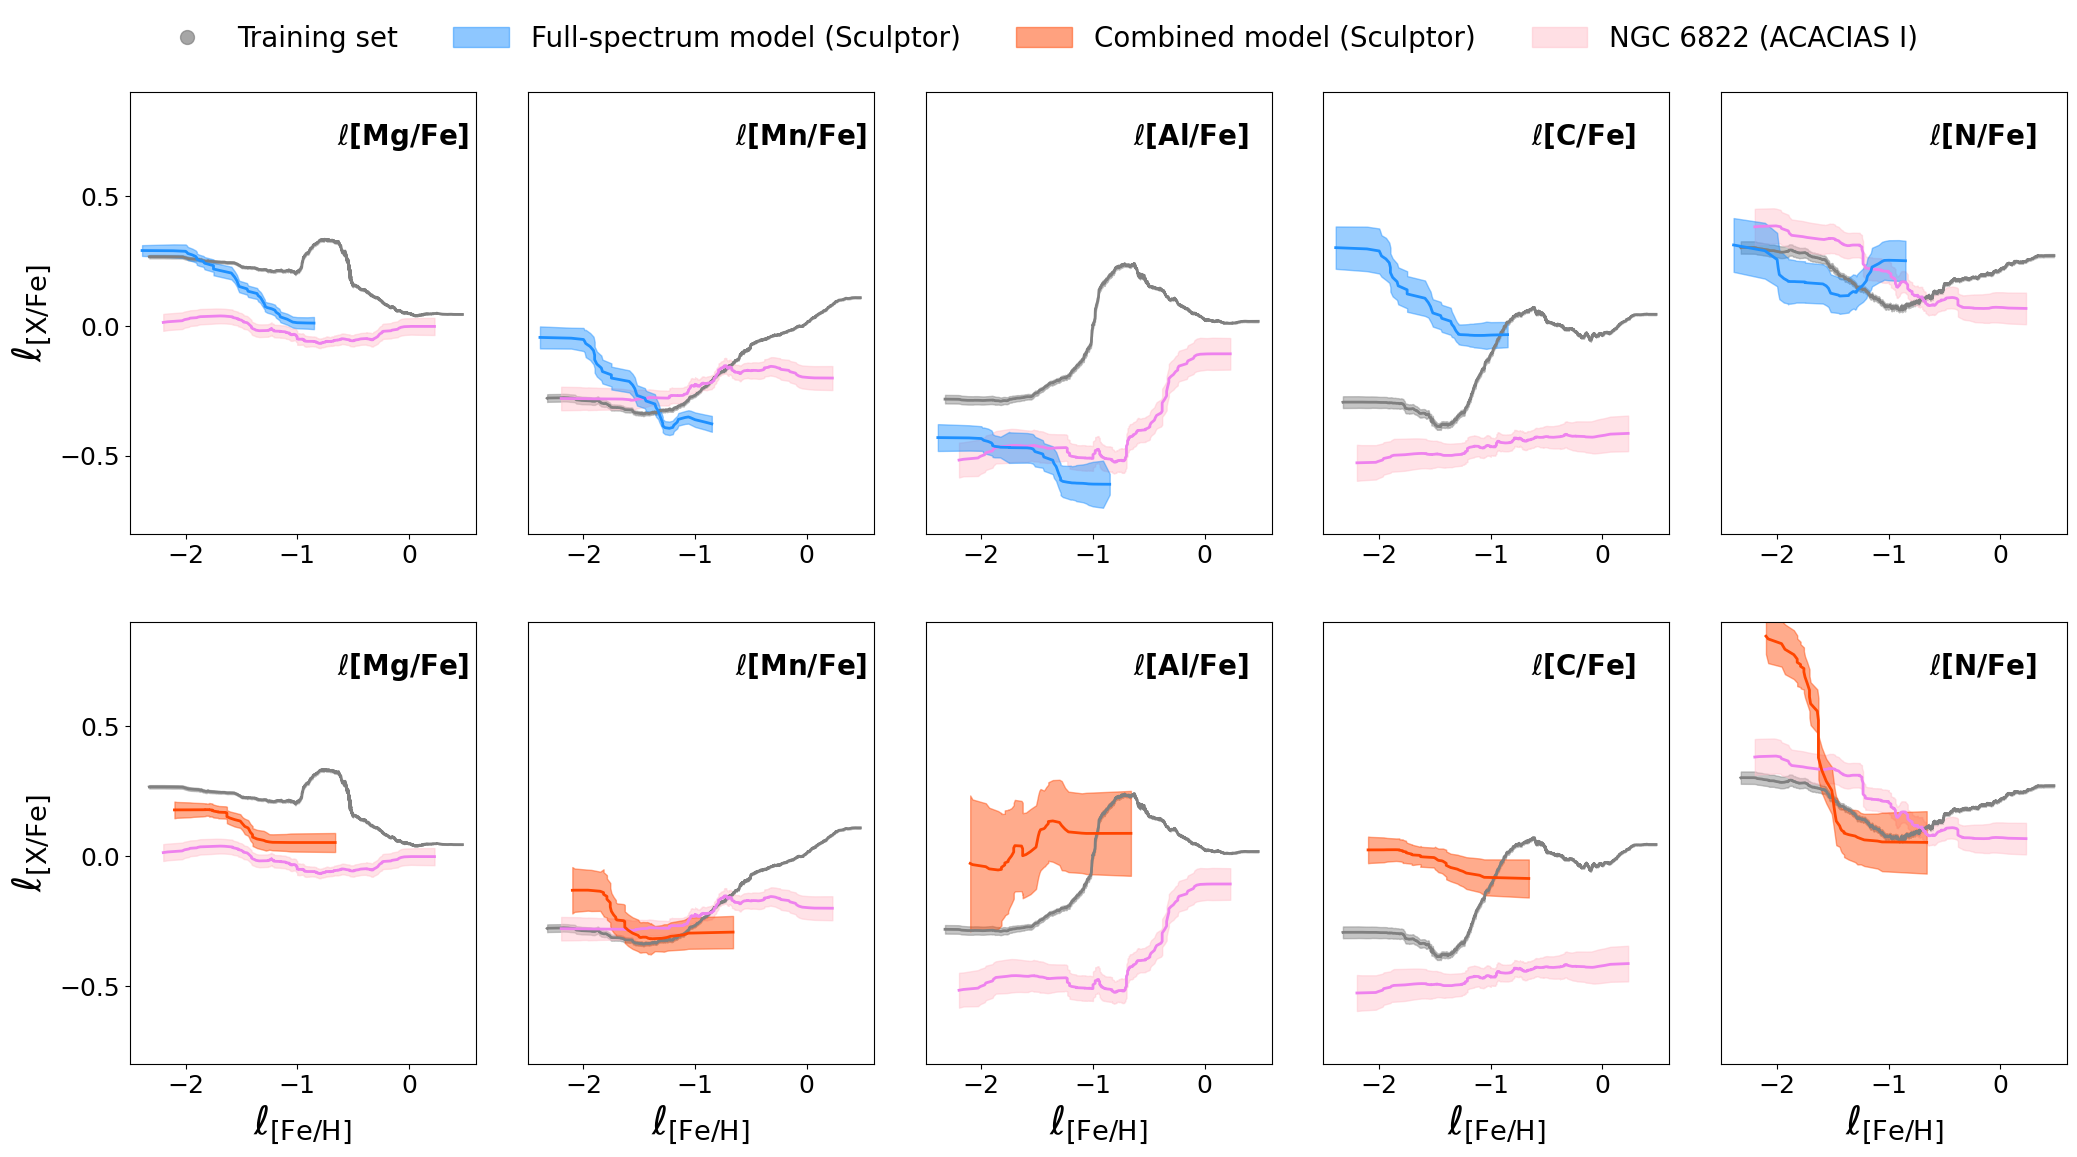

In [510]:
import matplotlib.pyplot as plt
import numpy as np

def plot_cannon_predictions_together(models, selected_labels, MW_pred_labels, model_names,
                                     colors=['dodgerblue','orangered','violet'], saveplot=False):
    """
    Plots The Cannon predictions vs. true APOGEE labels for two models in the SAME panels.
    One figure with 1 row and N columns (N = number of labels).
    Each panel contains:
        - Training set (grey)
        - Combined model prediction (color 1)
        - Full-spectrum model prediction (color 2)
    """
    #NGC6822 table from Ness et al 2025
    NGC6822_melissa_table = Table.read(f'{sculptor_data_path}/ness2024_acacias_ngc6822_labels.fits') #192 stars
    
    apo_labels = {'Teff':'TEFF',
                 'logg': 'LOGG',
                 'vmic':'VMICRO',
                 'Ak':'AK_WISE',
                 'l_feh':'FE_H',
                 'l_mg':'MG_FE',
                 'l_mn':'MN_FE',
                 'l_al':'AL_FE',
                 'l_c':'C_FE',
                 'l_n':'N_FE'}

    nrows = len(models)
    ncols = len(selected_labels)

    fig, axs = plt.subplots(nrows, ncols, figsize=(5*ncols, 6*nrows), squeeze=False)

    for row, (predicted_labels_array, model_name) in enumerate(zip(models, model_names)):
        for col, label in enumerate(selected_labels):
            ax = axs[row, col]

            # --- TRAINING SET ---
            x_MW = MW_pred_labels['FE_H']
            y_MW = MW_pred_labels[apo_labels[label]]
            runmed_x_MW , runmed_y_MW , runmed_std_MW  = runmed_stat(x_MW , y_MW , 
                                                                     window_size=500, gaussian_smooth=True)
            #ax.scatter(x_MW, y_MW, c='grey', s=13, alpha=0.1)
            ax.plot(runmed_x_MW, runmed_y_MW, color='gray', lw=2)
            ax.fill_between(runmed_x_MW,
                                runmed_y_MW - runmed_std_MW,
                                runmed_y_MW + runmed_std_MW,
                                color='gray', alpha=0.45)

            # --- PLOT ---
            x = predicted_labels_array['l_feh']
            y = predicted_labels_array[label]
            cc = colors[row]


            runmed_x, runmed_y, runmed_std = runmed_stat(x, y, window_size=28, gaussian_smooth=True)
            runmed_mel_x,runmed_mel_y , runmed_mel_std = runmed_stat(NGC6822_melissa_table['l_feh'],
                                                                    NGC6822_melissa_table[label],
                                                                    window_size=80,gaussian_smooth=True)

            ax.plot(runmed_mel_x, runmed_mel_y, color='violet', lw=2)
            ax.fill_between(runmed_mel_x,
                            runmed_mel_y - runmed_mel_std,
                            runmed_mel_y + runmed_mel_std,
                            color=colors[2], alpha=0.45)
            
            ax.plot(runmed_x, runmed_y, color=cc, lw=2)
            ax.fill_between(runmed_x,
                            runmed_y - runmed_std,
                            runmed_y + runmed_std,
                            color=cc, alpha=0.45)

            ax.set_xlim(-2.5, 0.6)
            ax.set_ylim(-0.8, 0.9)

        
            # --- Label del panel ---
            fancy_label = label[2].upper()+label[3:]
            ax.text(0.60, 0.88, r'$\ell$'+f"[{fancy_label}/Fe]", transform=ax.transAxes,
                    fontsize=20, weight='bold')
    
            ax.tick_params(axis='both', which='both', labelsize=18)
            ax.set_xticks([-2, -1, 0])
            
    
            if row != 0 : ax.set_xlabel(r'$\ell_\text{[Fe/H]}$', fontsize=28)
            if col == 0:
                ax.set_ylabel(r'$\ell_\text{[X/Fe]}$', fontsize=28)
                ax.set_yticks([-0.5, 0, 0.5])
            else:
                ax.set_yticks([])




    # Legend
    handles = [
        plt.Line2D([0], [0], color='grey', marker='o', linestyle='', markersize=10, alpha=0.7, label='Training set'),
        plt.Rectangle((0,0),1,1, color=colors[0], alpha=0.5, label=model_names[0]),
        plt.Rectangle((0,0),1,1, color=colors[1], alpha=0.5, label=model_names[1]),
        plt.Rectangle((0,0),1,1, color=colors[2], alpha=0.5, label=model_names[2])]
    fig.legend(handles=handles, loc='upper center', ncol=4, fontsize=20, frameon=False)

    plt.subplots_adjust(wspace=0.15, top=0.92)

    if saveplot:
        plt.savefig('figures/XFeH_both_models_runningmed_together.png',
                    dpi=300, bbox_inches='tight')

    plt.show()


plot_cannon_predictions_together(models=[scl_dic_full_model,scl_dic_combined_model],
                                 selected_labels=['l_mg','l_mn','l_al','l_c','l_n'],
                                 MW_pred_labels= training_labels_extended, 
                                 model_names=['Full-spectrum model (Sculptor)','Combined model (Sculptor)','NGC 6822 (ACACIAS I)'],
                                 colors=['dodgerblue','orangered','pink'],
                                 saveplot = False)

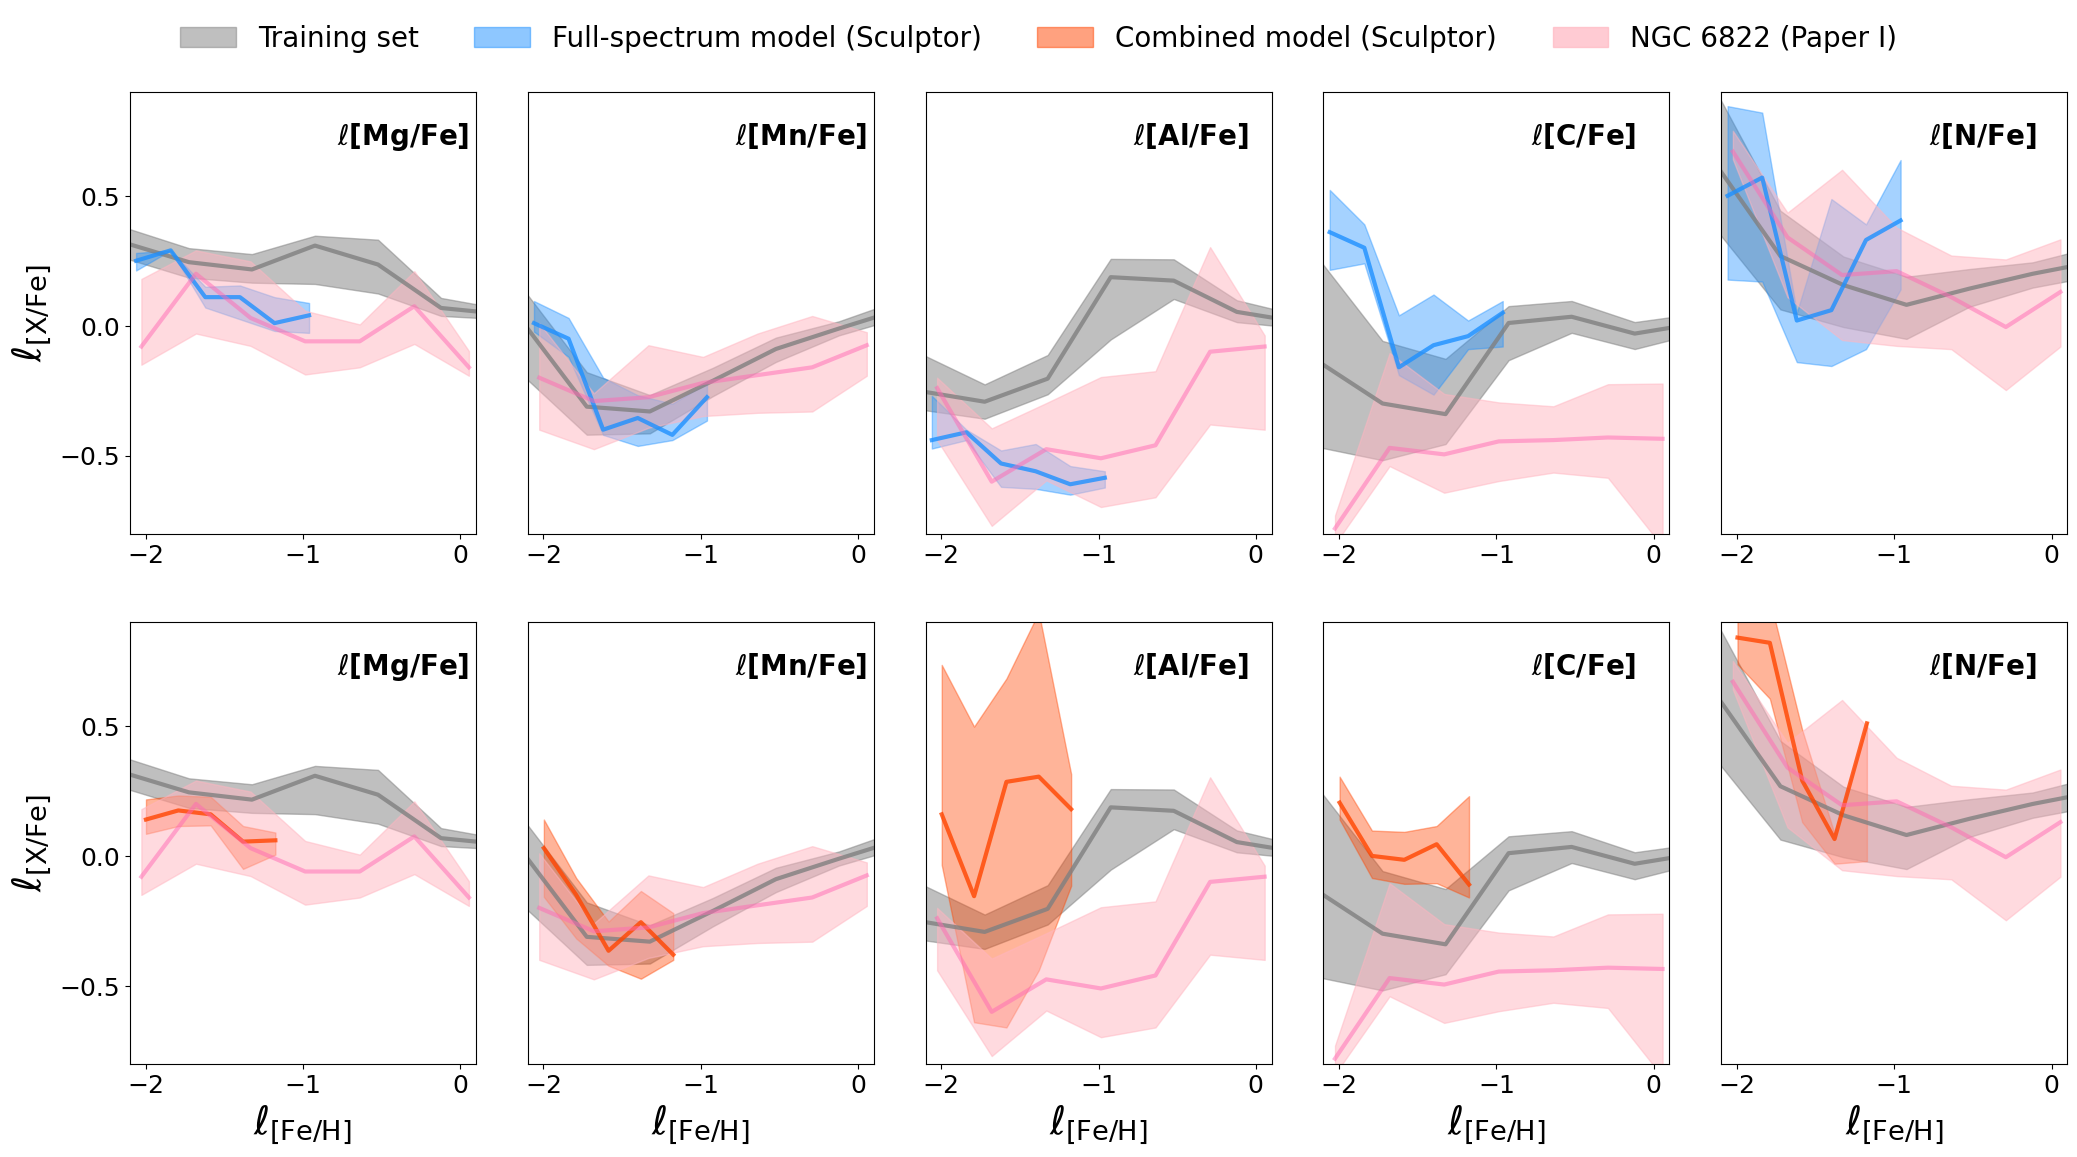

In [539]:
models=[scl_dic_full_model,scl_dic_combined_model]
selected_labels=['l_mg','l_mn','l_al','l_c','l_n']
MW_pred_labels= training_labels_extended 
model_names=['Full-spectrum model (Sculptor)','Combined model (Sculptor)','NGC 6822 (Paper I)']
colors=['dodgerblue','orangered','lightpink']

NGC6822_melissa_table = Table.read(f'{sculptor_data_path}/ness2024_acacias_ngc6822_labels.fits') #192 stars
    
apo_labels = {'Teff':'TEFF',
                 'logg': 'LOGG',
                 'vmic':'VMICRO',
                 'Ak':'AK_WISE',
                 'l_feh':'FE_H',
                 'l_mg':'MG_FE',
                 'l_mn':'MN_FE',
                 'l_al':'AL_FE',
                 'l_c':'C_FE',
                 'l_n':'N_FE'}

nrows = 2
ncols = 5

fig, axs = plt.subplots(nrows, ncols, figsize=(5*ncols, 6*nrows), squeeze=False)
for row, (predicted_labels_array, model_name) in enumerate(zip(models, model_names)):
        for col, label in enumerate(selected_labels):
            ax = axs[row, col]

            # --- PLOT TRAINING SET ---
            x_MW = MW_pred_labels['FE_H']
            y_MW = MW_pred_labels[apo_labels[label]]
            bins_MW = np.linspace(min(x_MW), max(x_MW), 8)
            bin_centers_MW = 0.5 * (bins_MW[1:] + bins_MW[:-1])
            med_MW, q25_MW, q75_MW = binned_stats(x_MW, y_MW, bins_MW, min_points=10)
            ax.plot(bin_centers_MW, med_MW, color='gray', lw=3, alpha=0.8)
            ax.fill_between(bin_centers_MW, q25_MW, q75_MW, color='gray', alpha=0.5)
            #ax.scatter(x_MW, y_MW, c='grey', s=13, alpha=0.1)

            # --- SCULPTOR DATA PLOT ---
            x = predicted_labels_array['l_feh']
            y = predicted_labels_array[label]
            cc = colors[row]

            bins_model = np.linspace(min(x), max(x), 8)
            bin_centers_model = 0.5 * (bins_model[1:] + bins_model[:-1])
            med_model, q25_model, q75_model = binned_stats(x, y, bins_model, min_points=3)
            ax.plot(bin_centers_model, med_model, color=cc, lw=3, alpha=0.8)
            ax.fill_between(bin_centers_model, q25_model, q75_model, color=cc, alpha=0.4)


            
            # --- NGC6822 DATA PLOT ---
            x_ness = NGC6822_melissa_table['l_feh']
            y_ness = NGC6822_melissa_table[label]
            cc_ness =  colors[2]

            bins_ness = np.linspace(min(x_ness), max(x_ness), 8)
            bin_centers_ness = 0.5 * (bins_ness[1:] + bins_ness[:-1])
            med_ness, q25_ness, q75_ness = binned_stats(x_ness, y_ness, bins_ness, min_points=3)
            ax.plot(bin_centers_ness, med_ness, color='hotpink', lw=3, alpha=0.5)
            ax.fill_between(bin_centers_ness, q25_ness, q75_ness, color=cc_ness, alpha=0.5)


            ax.set_xlim(-2.1, 0.1)
            ax.set_ylim(-0.8, 0.9)

        
            # --- Label del panel ---
            fancy_label = label[2].upper()+label[3:]
            ax.text(0.60, 0.88, r'$\ell$'+f"[{fancy_label}/Fe]", transform=ax.transAxes,
                    fontsize=20, weight='bold')
    
            ax.tick_params(axis='both', which='both', labelsize=18)
            ax.set_xticks([-2, -1, 0])
            
    
            if row != 0 : ax.set_xlabel(r'$\ell_\text{[Fe/H]}$', fontsize=28)
            if col == 0:
                ax.set_ylabel(r'$\ell_\text{[X/Fe]}$', fontsize=28)
                ax.set_yticks([-0.5, 0, 0.5])
            else:
                ax.set_yticks([])


# Legend
handles = [
    #plt.Line2D([0], [0], color='grey', marker='o', linestyle='', markersize=10, alpha=0.7, label='Training set'),
    plt.Rectangle((0,0),1,1, color='gray', alpha=0.5, label='Training set'),
    plt.Rectangle((0,0),1,1, color=colors[0], alpha=0.5, label=model_names[0]),
    plt.Rectangle((0,0),1,1, color=colors[1], alpha=0.5, label=model_names[1]),
    plt.Rectangle((0,0),1,1, color=colors[2], alpha=0.7, label=model_names[2])]
fig.legend(handles=handles, loc='upper center', ncol=4, fontsize=20, frameon=False)

plt.subplots_adjust(wspace=0.15, top=0.92)

#plt.savefig('figures/XFeH_both_models_runningmed_together.png',dpi=300, bbox_inches='tight')

plt.show()

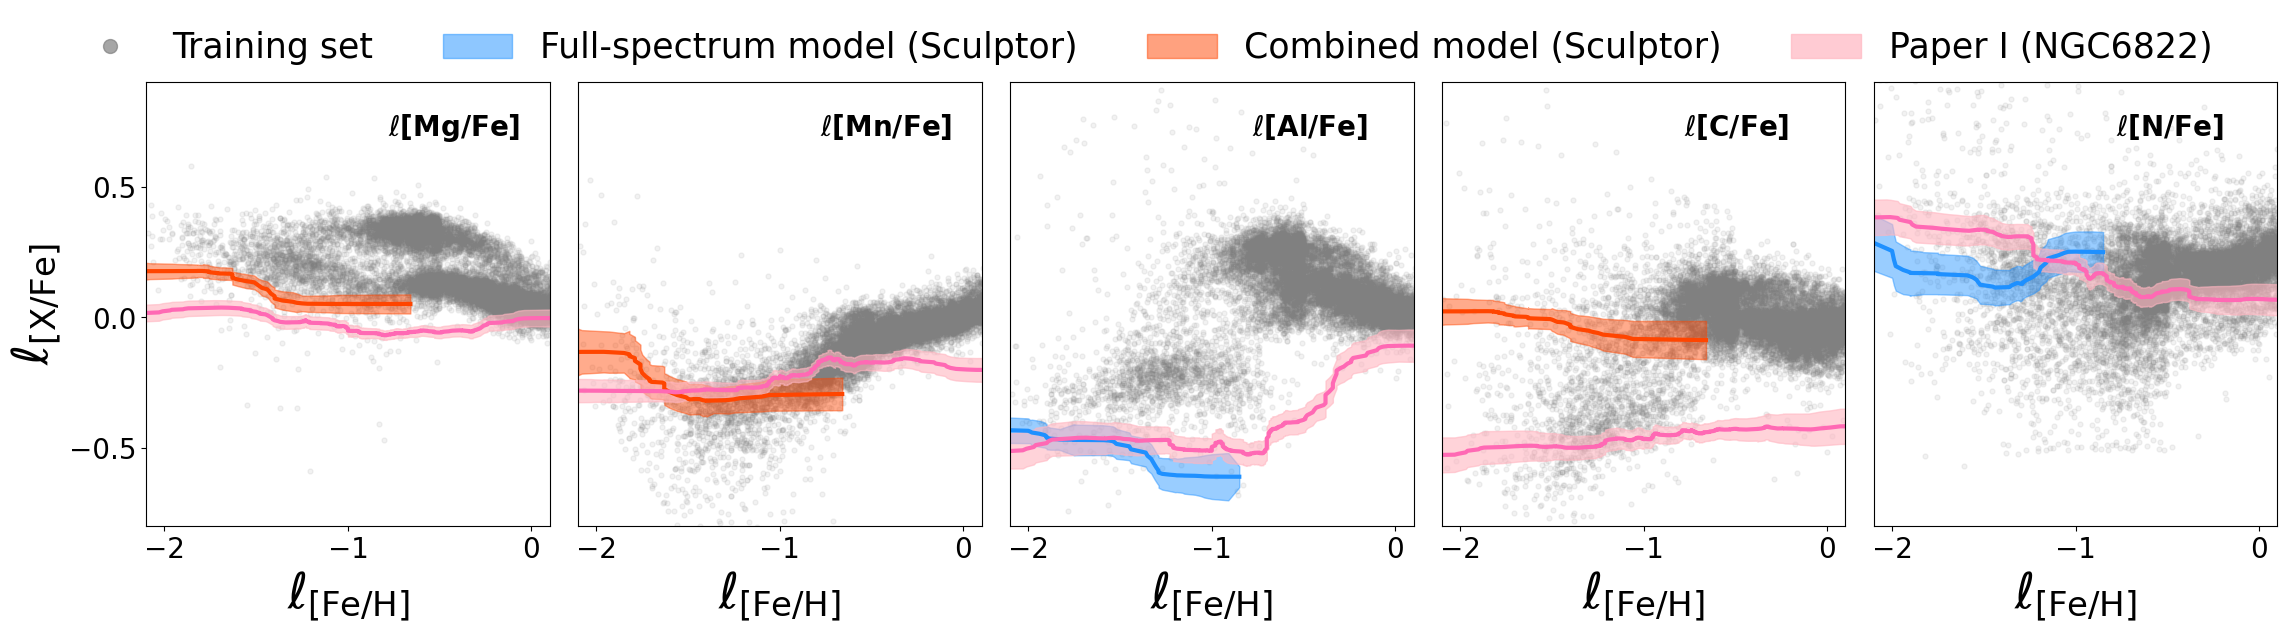

In [817]:
#models=[scl_dic_full_model,scl_dic_combined_model]
models_dicitonary = {'combined':scl_dic_combined_model,
                    'full':scl_dic_full_model}
selected_models =['combined',  #Mg
                 'combined',  #Mn
                 'full',      #Al
                 'combined',  #C
                 'full'       #N 
                    ]
selected_labels=['l_mg','l_mn','l_al','l_c','l_n']

MW_pred_labels= training_labels_extended 

model_names=['Full-spectrum model (Sculptor)','Combined model (Sculptor)','Paper I (NGC6822)']
colors=['dodgerblue','orangered','lightpink']

NGC6822_melissa_table = Table.read(f'{sculptor_data_path}/ness2024_acacias_ngc6822_labels.fits') #192 stars
    
apo_labels = {'Teff':'TEFF',
                 'logg': 'LOGG',
                 'vmic':'VMICRO',
                 'Ak':'AK_WISE',
                 'l_feh':'FE_H',
                 'l_mg':'MG_FE',
                 'l_mn':'MN_FE',
                 'l_al':'AL_FE',
                 'l_c':'C_FE',
                 'l_n':'N_FE'}

nrows = 1
ncols = 5

fig, axs = plt.subplots(nrows, ncols, figsize=(5.5*ncols, 6*nrows), squeeze=False)
#for row, (predicted_labels_array, model_name) in enumerate(zip(models, model_names)):
for col, label in enumerate(selected_labels):
            if selected_models[col] == 'combined':
                predicted_labels_array = scl_dic_combined_model
                cc = 'orangered'
            elif selected_models[col] == 'full':
                predicted_labels_array = scl_dic_full_model
                cc = 'dodgerblue'

    
            ax = axs[0, col]

            # --- PLOT TRAINING SET ---
            x_MW = MW_pred_labels['FE_H']
            y_MW = MW_pred_labels[apo_labels[label]]
            ax.scatter(x_MW, y_MW, c='grey', s=13, alpha=0.1)

            # --- SCULPTOR DATA PLOT ---
            x = predicted_labels_array['l_feh']
            y = predicted_labels_array[label]

            #bins_model = np.linspace(min(x), max(x), 8)
            #bin_centers_model = 0.5 * (bins_model[1:] + bins_model[:-1])
            #med_model, q25_model, q75_model = binned_stats(x, y, bins_model, min_points=3)
            #ax.plot(bin_centers_model, med_model, color=cc, lw=3, alpha=0.8)
            #ax.fill_between(bin_centers_model, q25_model, q75_model, color=cc, alpha=0.4)
            
            runmed_x, runmed_y, runmed_std = runmed_stat(x, y, window_size=28, gaussian_smooth=True)
            ax.fill_between(runmed_x,runmed_y - runmed_std,runmed_y + runmed_std,color=cc, alpha=0.45)
            ax.plot(runmed_x, runmed_y, color=cc, lw=3)

            
            # --- NGC6822 DATA PLOT ---
            x_ness = NGC6822_melissa_table['l_feh']
            y_ness = NGC6822_melissa_table[label]
            cc_ness =  colors[2]

            #bins_ness = np.linspace(min(x_ness), max(x_ness), 8)
            #bin_centers_ness = 0.5 * (bins_ness[1:] + bins_ness[:-1])
            #med_ness, q25_ness, q75_ness = binned_stats(x_ness, y_ness, bins_ness, min_points=3)
            #ax.plot(bin_centers_ness, med_ness, color='hotpink', lw=3, alpha=0.8)
            #ax.fill_between(bin_centers_ness, q25_ness, q75_ness, color=cc_ness, alpha=0.5)

            runmed_mel_x,runmed_mel_y , runmed_mel_std = runmed_stat(NGC6822_melissa_table['l_feh'],NGC6822_melissa_table[label],window_size=80,gaussian_smooth=True)
            ax.fill_between(runmed_mel_x,runmed_mel_y - runmed_mel_std,runmed_mel_y + runmed_mel_std,color=colors[2], alpha=0.6)
            ax.plot(runmed_mel_x, runmed_mel_y, color='hotpink', lw=3)

            ax.set_xlim(-2.1, 0.1)
            ax.set_ylim(-0.8, 0.9)

        
            # --- Label of the panel ---
            fancy_label = label[2].upper()+label[3:]
            ax.text(0.60, 0.88, r'$\ell$'+f"[{fancy_label}/Fe]", transform=ax.transAxes,
                    fontsize=20, weight='bold')
    
            ax.tick_params(axis='both', which='both', labelsize=20)
            ax.set_xticks([-2, -1, 0])
            
    
            ax.set_xlabel(r'$\ell_\text{[Fe/H]}$', fontsize=35)
            if col == 0:
                ax.set_ylabel(r'$\ell_\text{[X/Fe]}$', fontsize=35)
                ax.set_yticks([-0.5, 0, 0.5])
            else:
                ax.set_yticks([])


# Legend
handles = [
    plt.Line2D([0], [0], color='grey', marker='o', linestyle='', markersize=10, alpha=0.7, label='Training set'),
    #plt.Rectangle((0,0),1,1, color='gray', alpha=0.5, label='Training set'),
    plt.Rectangle((0,0),1,1, color=colors[0], alpha=0.5, label=model_names[0]),
    plt.Rectangle((0,0),1,1, color=colors[1], alpha=0.5, label=model_names[1]),
    plt.Rectangle((0,0),1,1, color=colors[2], alpha=0.7, label=model_names[2])]
fig.legend(handles=handles, loc='upper center', ncol=4, fontsize=25, frameon=False)

plt.subplots_adjust(wspace=0.07, top=0.85)

plt.savefig('figures/XFeH_both_models_runningmed_together.png',dpi=300, bbox_inches='tight')

plt.show()

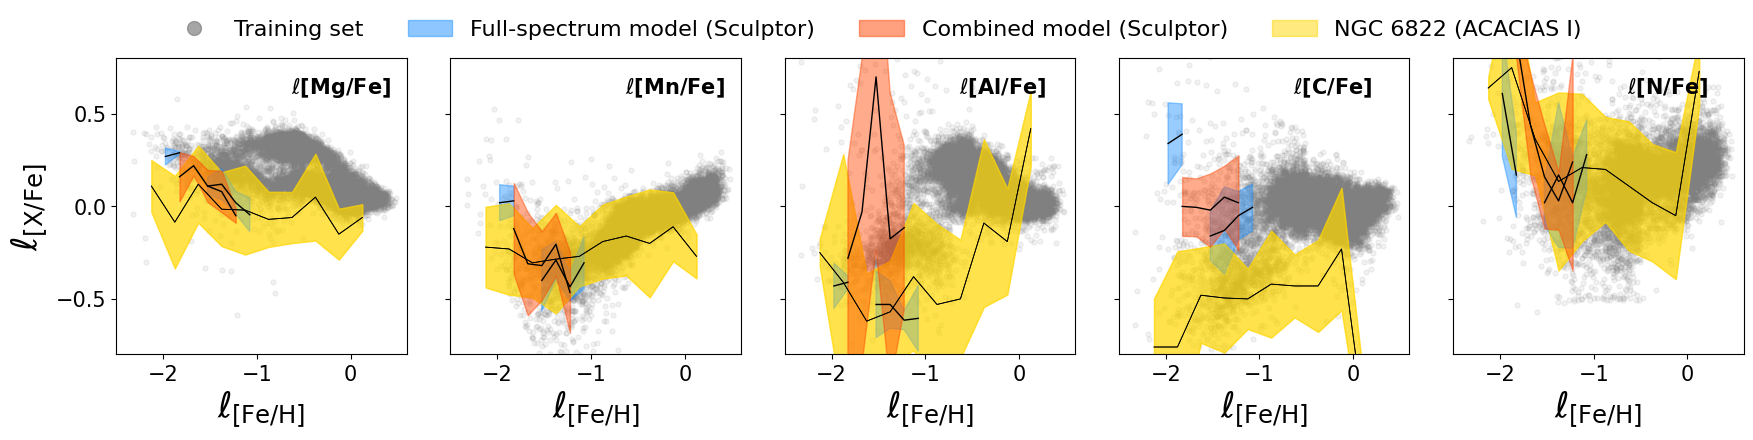

In [113]:
import numpy as np

def binned_median_stat(x, y, bins=20, x_range=None, use_percentiles=False):
    """
    Compute binned median statistics.
    """
    x = np.asarray(x)
    y = np.asarray(y)

    bin_edges = np.histogram_bin_edges(x, bins=bins, range=x_range)
    bin_centers = 0.5 * (bin_edges[:-1] + bin_edges[1:])

    y_median = np.full(len(bin_centers), np.nan)
    y_err = np.full(len(bin_centers), np.nan)

    for i in range(len(bin_edges) - 1):
        mask = (x >= bin_edges[i]) & (x < bin_edges[i + 1])
        if np.sum(mask) < 3:
            continue

        y_bin = y[mask]
        y_median[i] = np.nanmedian(y_bin)

        if use_percentiles:
            p16, p84 = np.nanpercentile(y_bin, [16, 84])
            y_err[i] = 0.5 * (p84 - p16)
        else:
            y_err[i] = np.nanstd(y_bin)

    return bin_centers, y_median, y_err





def plot_cannon_predictions_together(models, selected_labels, MW_pred_labels, model_names,
                                     colors=['dodgerblue','orangered','gold'], saveplot=False):
    """
    Plots The Cannon predictions vs. true APOGEE labels for two models in the SAME panels.
    One figure with 1 row and N columns (N = number of labels).
    Each panel contains:
        - Training set (grey)
        - Combined model prediction (color 1)
        - Full-spectrum model prediction (color 2)
    """
    #NGC6822 table from Ness et al 2025
    NGC6822_melissa_table = Table.read(f'{sculptor_data_path}/ness2024_acacias_ngc6822_labels.fits') #192 stars
    
    apo_labels = {'Teff':'TEFF',
                 'logg': 'LOGG',
                 'vmic':'VMICRO',
                 'Ak':'AK_WISE',
                 'l_feh':'FE_H',
                 'l_mg':'MG_FE',
                 'l_mn':'MN_FE',
                 'l_al':'AL_FE',
                 'l_c':'C_FE',
                 'l_n':'N_FE'}

    ncols = len(selected_labels)
    nrows = 1

    fig, axs = plt.subplots(1, ncols, figsize=(21, 4), squeeze=False,sharey=True)

    axs = axs[0]

    for col, label in enumerate(selected_labels):
        ax = axs[col]

        # --- TRAINING SET ---
        x_MW = MW_pred_labels['FE_H']
        y_MW = MW_pred_labels[apo_labels[label]]
        ax.scatter(x_MW, y_MW, c='grey', s=13, alpha=0.1)

        # --- PLOT ---
        for i, (predicted_labels_array, model_name) in enumerate(zip(models, model_names)):
            cc = colors[i]

            x = predicted_labels_array['l_feh']
            y = predicted_labels_array[label]

            np.linspace(-2.2, -1, 8)
            
            bin_x, bin_y, bin_std = binned_median_stat(x, y,bins=8,x_range=(-2.2, -1),use_percentiles=True)
            
            bin_mel_x, bin_mel_y, bin_mel_std = binned_median_stat(NGC6822_melissa_table['l_feh'],NGC6822_melissa_table[label],
                                                                   bins=12,x_range=(-2.5, 0.5),use_percentiles=True)
            ax.plot(bin_mel_x, bin_mel_y, color='k', lw=0.6)
            ax.fill_between(bin_mel_x,
                            bin_mel_y - bin_mel_std,
                            bin_mel_y + bin_mel_std,
                            color=colors[2], alpha=0.45)
            
            ax.plot(bin_x, bin_y, color='k', lw=1)
            ax.fill_between(bin_x,
                            bin_y - bin_std,
                            bin_y + bin_std,
                            color=cc, alpha=0.45)

        fancy_label = label[2].upper()+label[3:]
        
        # --- Label del panel ---
        ax.text(0.60, 0.88, r'$\ell$'+f"[{fancy_label}/Fe]", transform=ax.transAxes,
                fontsize=15, weight='bold')

        ax.tick_params(axis='both', which='both', labelsize=15)
        ax.set_xticks([-2, -1, 0])
        

        ax.set_xlabel(r'$\ell_\text{[Fe/H]}$', fontsize=25)
        if col == 0:
            ax.set_ylabel(r'$\ell_\text{[X/Fe]}$', fontsize=25)
            ax.set_yticks([-0.5, 0, 0.5])

        ax.set_xlim(-2.5, 0.6)
        ax.set_ylim(-0.8, 0.8)

    # Legend
    handles = [
        plt.Line2D([0], [0], color='grey', marker='o', linestyle='', markersize=10, alpha=0.7, label='Training set'),
        plt.Rectangle((0,0),1,1, color=colors[0], alpha=0.5, label=model_names[0]),
        plt.Rectangle((0,0),1,1, color=colors[1], alpha=0.5, label=model_names[1]),
        plt.Rectangle((0,0),1,1, color=colors[2], alpha=0.5, label=model_names[2])]
    fig.legend(handles=handles, loc='upper center', ncol=4, fontsize=16, frameon=False)

    plt.subplots_adjust(wspace=0.15, top=0.85)

    if saveplot:
        plt.savefig('figures/XFeH_both_models_runningmed_together.png',
                    dpi=300, bbox_inches='tight')

    plt.show()


plot_cannon_predictions_together(models=[scl_dic_full_model,scl_dic_combined_model],
                                 selected_labels=['l_mg','l_mn','l_al','l_c','l_n'],
                                 MW_pred_labels= training_labels_extended, 
                                 model_names=['Full-spectrum model (Sculptor)','Combined model (Sculptor)','NGC 6822 (ACACIAS I)'],
                                 saveplot = False)

#### [Fe/H] distributions

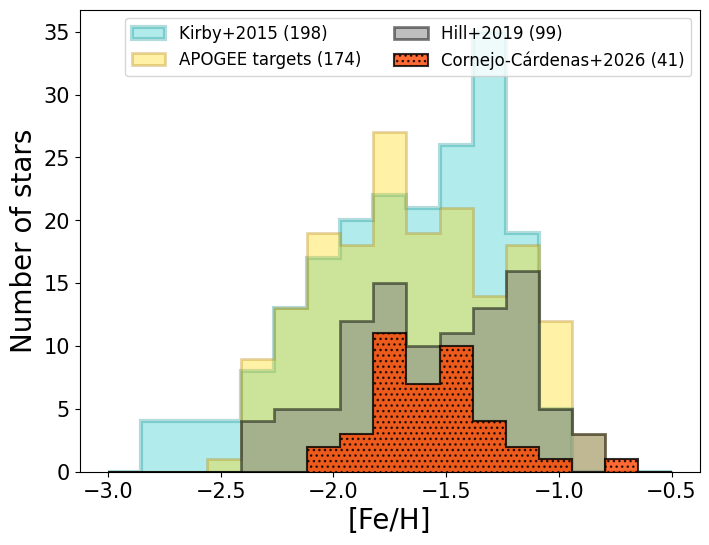

In [84]:
hill_scl_table = Table.read(f'{sculptor_data_path}/Sculptor_VLT_Hill2019.fit')
kirby_scl_table = Table.read(f'{sculptor_data_path}/Sculptor_DEIMOS_kirby2015.fit')
mask_kirby_sculptor = [syst.startswith('S') for syst in kirby_scl_table['Syst']]
kirby_scl_table = kirby_scl_table[mask_kirby_sculptor]

lardo_table1 = pd.read_csv(f'{sculptor_data_path}/Sculptor_VLT_Lardo2016_1.csv',skiprows=[1,2,3])
Feh_lardo = np.array([float(val.replace('–', '-').replace('−', '-').strip()) for val in lardo_table1['[Fe/H]']])


bins=np.linspace(-3,-0.5,18)
plt.figure(figsize=(8,6))

#kirby
plt.hist(kirby_scl_table['__Fe_H_'],bins=bins,histtype='step',color='c',fill=True,alpha=0.3,edgecolor='darkcyan',
         lw=3,label='Kirby+2015 (198)')

#Apogee
plt.hist(final_APOGEE_sculptor_data['FE_H'],bins=bins,histtype='step',color='gold',fill=True,alpha=0.35,lw=2,edgecolor='darkgoldenrod',
        label='APOGEE targets (174)')

#hill
plt.hist(hill_scl_table['__Fe_H_'],bins=bins,histtype='step',color='grey',fill=True,alpha=0.5,
         edgecolor='k',lw=2,label='Hill+2019 (99)')

plt.hist(scl_dic_combined_model['l_feh'],bins=bins,lw=1.5, histtype='step',color='orangered',fill=True,alpha=0.8,
         hatch='...',edgecolor='k',label='Cornejo-Cárdenas+2026 (41)')

#Lardo
#plt.hist(Feh_lardo,bins=bins,
#         histtype='step',color='gold',fill=True,alpha=0.6,
#         edgecolor='gold',lw=3,label='Lardo et al., 2016 (94)')

plt.xlabel("[Fe/H]",fontsize=20)
plt.ylabel("Number of stars",fontsize=20)
plt.tick_params(labelsize=15)
plt.legend(fontsize=12,ncol=2)
plt.savefig('figures/FeH_Scl_literature_comparison.png',dpi=300,bbox_inches='tight')
plt.show()

In [56]:
len()

174

In [187]:
print('Hill statistics:')
print(np.min(hill_scl_table['__Fe_H_']), np.max(hill_scl_table['__Fe_H_']) , np.median(hill_scl_table['__Fe_H_']))

print('\nKirby statistics:')
print(np.min(kirby_scl_table['__Fe_H_']), np.max(kirby_scl_table['__Fe_H_']) , np.median(kirby_scl_table['__Fe_H_']))

print('\nOurs statistics:')
print(np.min(scl_dic_combined_model['l_feh']), np.max(scl_dic_combined_model['l_feh']) , np.median(scl_dic_combined_model['l_feh']))

print('\nLardo statistics:')
print(np.min(Feh_lardo), np.max(Feh_lardo) , np.median(Feh_lardo))

print('\n skuladottir15 statistics:')
skuladottir15_scl_table = Table.read(f'{sculptor_data_path}/Sculptor_Skuladottir2015_table1.fit')
print(np.min(skuladottir15_scl_table['__Fe_H_']), np.max(skuladottir15_scl_table['__Fe_H_']) , np.median(skuladottir15_scl_table['__Fe_H_']))

Hill statistics:
-2.41 -0.89 -1.53

Kirby statistics:
-2.82 -1.01 -1.62

Ours statistics:
-2.1 -0.66 -1.63

Lardo statistics:
-2.93 -1.12 -2.0

 skuladottir15 statistics:
-2.41 -0.89 -1.505


Star,RAJ2000,DEJ2000,Teff,logg,vt,RV,S_N,__Fe_H_,e__Fe_H_,__Mg_H_,e__Mg_H_,NS,logeps_S_,dnoise,DNLTE,__S_Fe_,e__S_Fe_,__S_Mg_,e__S_Mg_,Simbad
,,,K,log(cm.s**-2),km / s,km / s,,,,,,,,,,,,,,
bytes6,bytes11,bytes11,int16,float64,float64,float64,int16,float64,float64,float64,float64,int16,float64,float64,float64,float64,float64,float64,float64,bytes7
ET0024,01 00 34.04,-33 39 04.6,3897,0.0,2.2,113.3,94,-1.24,0.1,0.0,0.0,3,5.96,0.14,-0.21,-0.16,0.2,0.0,0.0,Simbad
ET0026,01 00 12.76,-33 41 16.0,4245,0.5,1.7,97.1,76,-1.8,0.16,-1.36,0.22,3,5.71,0.11,-0.26,0.09,0.12,-0.35,0.24,Simbad
ET0027,01 00 15.37,-33 39 06.2,4178,0.3,2.2,111.8,69,-1.5,0.13,-1.38,0.19,3,6.04,0.09,-0.29,0.09,0.12,-0.03,0.25,Simbad
ET0028,01 00 17.77,-33 35 59.7,4085,0.3,2.0,119.8,73,-1.22,0.11,-1.31,0.16,3,5.95,0.13,-0.25,-0.24,0.18,-0.15,0.26,Simbad
ET0031,01 00 07.57,-33 37 03.9,4329,0.5,2.1,113.3,72,-1.68,0.17,-1.17,0.22,3,5.9,0.1,-0.33,0.08,0.11,-0.43,0.23,Simbad
ET0033,01 00 20.29,-33 35 34.5,4302,0.6,1.7,106.9,50,-1.77,0.16,-1.5,0.2,3,5.73,0.11,-0.3,0.05,0.11,-0.22,0.23,Simbad
ET0043,01 00 13.95,-33 36 39.2,4276,0.6,1.7,110.2,61,-1.24,0.16,-1.44,0.22,3,5.89,0.14,-0.29,-0.32,0.15,-0.12,0.25,Simbad
ET0048,00 59 55.63,-33 33 24.6,4490,0.5,1.7,121.4,103,-1.9,0.19,-1.32,0.22,3,5.69,0.08,-0.38,0.05,0.1,-0.53,0.25,Simbad


#### SNR - [Al/Fe] - logg statistics

##### SNR

In [59]:
# What is the median SNR of  stars with [Fe/H] < -1.6?

poor_mask = scl_dic_combined_model['l_feh'] < -1.6

print('SNR of metal poor stars: ',np.nanmedian(scl_dic_combined_model['SNR'][poor_mask]))

print('SNR of metal richer stars: ',np.nanmedian(scl_dic_combined_model['SNR'][~poor_mask]))

SNR of metal poor stars:  23.76692118118016
SNR of metal richer stars:  34.12802327900372


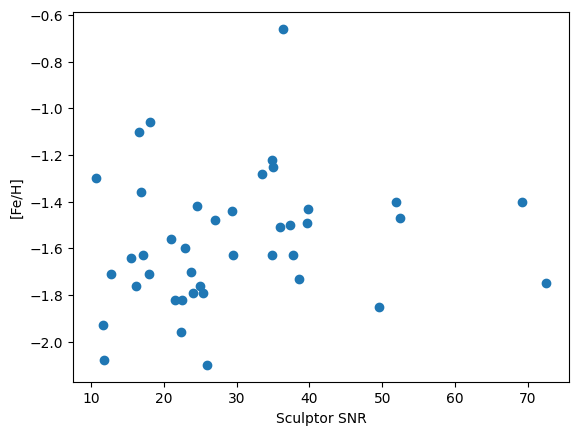

In [63]:
plt.figure()
plt.scatter(scl_dic_combined_model['SNR'],scl_dic_combined_model['l_feh'])
plt.xlabel('Sculptor SNR')
plt.ylabel('[Fe/H]')
plt.show()

##### [Al/Fe]

In [154]:
np.median(scl_dic_combined_model['l_al']), np.median(scl_dic_full_model['l_al']), 

(0.06, -0.53)

##### logg

In [157]:
np.median(scl_dic_combined_model['logg']), np.median(scl_dic_full_model['logg'])
max(scl_dic_combined_model['logg']), min(scl_dic_full_model['logg'])

(3.48, 1.75)

#### Spectra

In [735]:
combined_model.vectorizer.label_names

('TEFF',
 'LOGG',
 'VMICRO',
 'AK_WISE',
 'FE_H',
 'MG_FE',
 'MN_FE',
 'AL_FE',
 'C_FE',
 'N_FE')

In [893]:
s = 8
l = 7
label_combo_1 = full_model.training_set_labels[s,:]
label_combo_2 = label_combo_1.copy()
label_combo_2[l] += 0.5 # increase [Al/Fe] by 0.5 dex

In [894]:
label_combo_1, label_combo_2

(array([ 4.99890771e+03,  2.50034261e+00,  1.70844102e+00,  4.77362163e-02,
        -5.36740005e-01,  1.02132022e-01, -8.40380192e-02,  1.28230989e-01,
         1.42549992e-01,  6.42820001e-02]),
 array([ 4.99890771e+03,  2.50034261e+00,  1.70844102e+00,  4.77362163e-02,
        -5.36740005e-01,  1.02132022e-01, -8.40380192e-02,  6.28230989e-01,
         1.42549992e-01,  6.42820001e-02]))

In [895]:
spectrum_1 = full_model.__call__(label_combo_1)
spectrum_2 = full_model.__call__(label_combo_2)

Text(0.5, 0.98, "['TEFF', 'LOGG', 'FE_H'] = [4998.91, 2.5, -0.54]")

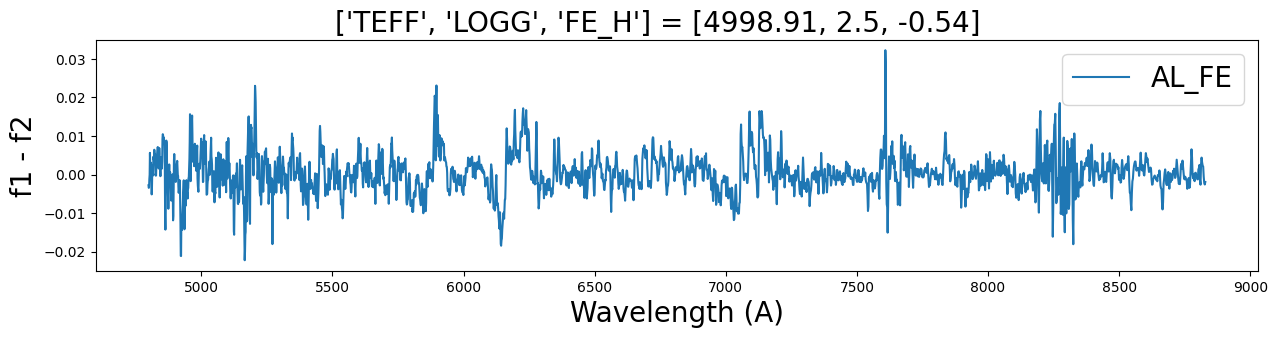

In [896]:
plt.figure(figsize=(15,3))
plt.plot(combined_model.dispersion[900:-10],spectrum_1 - spectrum_2,label=combined_model.vectorizer.label_names[l])
plt.xlabel('Wavelength (A)',fontsize=20)
plt.ylabel('f1 - f2',fontsize=20)
plt.legend(fontsize=20)
star_labels = [combined_model.vectorizer.label_names[i] for i in [0,1,4]]
plt.suptitle(f'{[combined_model.vectorizer.label_names[i] for i in [0,1,4]]} = {[np.round(label_combo_1[i],2) for i in [0,1,4]]}',fontsize=20)

In [878]:
# now with sculptor stars

label_scl_star_comb = scl_dic_combined_model[3]
label_scl_star_full = scl_dic_full_model[3]


label_scl_star_comb

number,original_idx,SNR,ra,dec,Teff,logg,vmic,Ak,l_feh,l_mg,l_mn,l_al,l_c,l_n,e_teff,e_logg,e_vmic,e_Ak,e_feh,e_mg,e_mn,e_al,e_c,e_n,red chi2
int64,int32,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64
4,12,11.686766377474083,15.0263125,-33.713751,5170.0,2.39,0.52,-0.03,-1.93,0.33,0.14,2.4,0.02,1.12,0.07,0.1,0.15,0.21,0.09,0.35,0.49,0.83,0.21,0.37,0.6


In [891]:
label_scl_star = label_scl_star['Teff','logg','vmic','Ak','l_feh','l_mg','l_mn','l_al','l_c','l_n']
#label_scl_star_comb = [v for ]

for v in label_scl_star:
    print(v)

5170.0
2.39
0.52
-0.03
-1.93
0.33
0.14
2.4
0.02
1.12


In [863]:
max(spectrum_1 - spectrum_2)

0.013595380109206578

In [781]:
[print(i,scl_dic_combined_model['l_feh'][i]) for i in range(len(scl_dic_combined_model['SNR'])) if scl_dic_combined_model['SNR'][i] < 15]

3 -1.93
36 -2.08
37 -1.3
38 -1.71


[None, None, None, None]

In [582]:
s = 3


adjusted_ivar_model_full = scl_final_IVAR_all/(1. + scl_final_IVAR_all * full_model.s2)
use_full = np.isfinite(scl_final_Flux_all * adjusted_ivar_model_full) * (adjusted_ivar_model_full > 0)
wavelength_array_model_full = LAMOST_wavelength[900:-10][use_full[s]]


adjusted_ivar_model_combined = scl_final_IVAR_all/(1. + scl_final_IVAR_all * combined_model.s2)
use_combined = np.isfinite(scl_final_Flux_all * adjusted_ivar_model_combined) * (adjusted_ivar_model_combined > 0)
wavelength_array_model_combined = LAMOST_wavelength[900:-10][use_combined[s]]

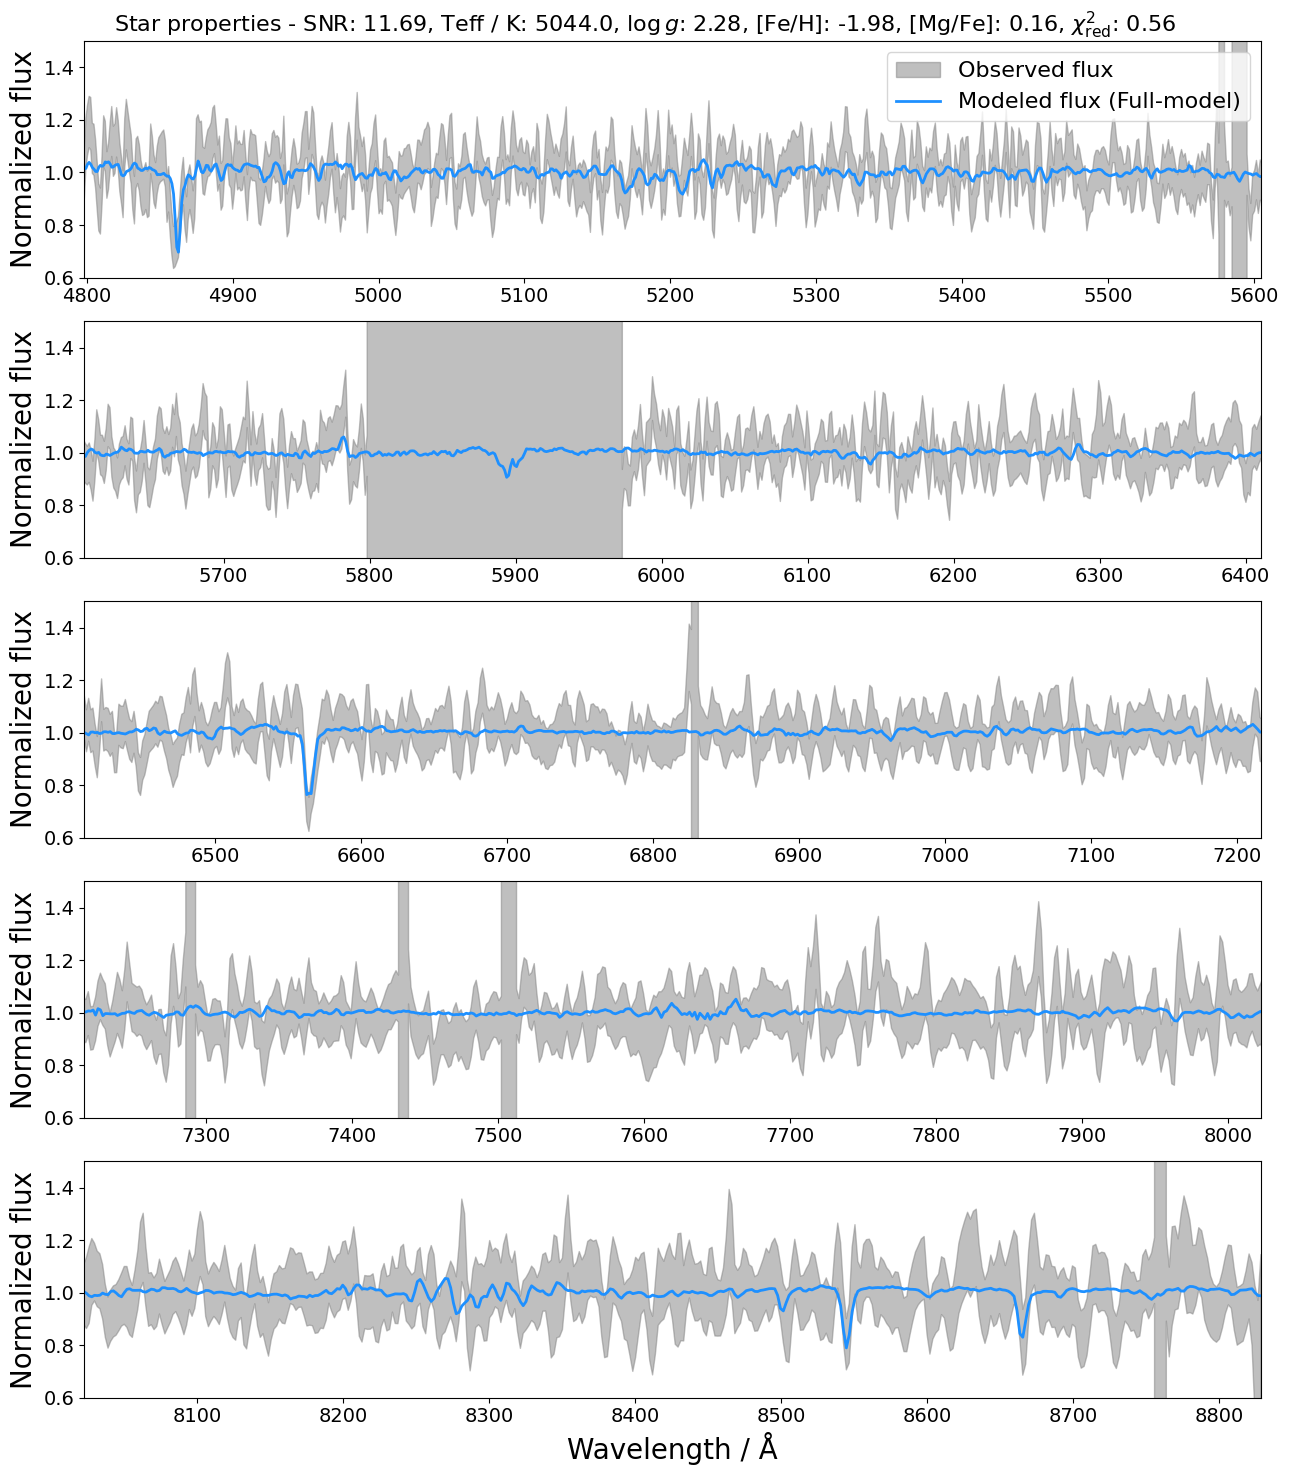

In [583]:
def generated_spectra_uncertainty(wavelength_array_observed, flux_observed, ivar_observed, 
                                  wavelength_model,metadata,star_properties,wavel_divisions=5,color='lightpink',
                                 model_name='',savefig=False,star=0):
    
    #to separate the wavelenght ranges
    deltaw = (max(wavelength_array_observed) - min(wavelength_array_observed))/wavel_divisions
    lims = {}
    first_wavel = wavelength_array_observed[0]
    for i in range(5):
        l0 = first_wavel + i * deltaw
        l1 = first_wavel + (i + 1) * deltaw
        lims[i] = [l0, l1]

    fig, axs = plt.subplots(wavel_divisions, 1, figsize=(13, 15),squeeze=False)   

    for i in range(wavel_divisions):
        ax = axs[i,0]
        ax.fill_between(wavelength_array_observed,flux_observed-np.sqrt(1/ivar_observed),flux_observed+np.sqrt(1/ivar_observed),
                        color='grey',label='Observed flux',alpha=0.5)
        ax.plot(wavelength_model,metadata['model_flux'],color=color,linewidth=2,label=f'Modeled flux ({model_name})')
        ax.set_xlim(lims[i][0],lims[i][1])
        ax.set_ylim(0.6,1.5)
        if i ==0:ax.legend(fontsize=16)
        if i == wavel_divisions-1:
            ax.set_xlabel('Wavelength / Å',fontsize=20)
        ax.set_ylabel('Normalized flux',fontsize=20)
        ax.tick_params(axis='both', labelsize=14)
        ax.axvline(3995.00 , color='c')#,lw=3)
        ax.axvline(4447.03 , color='c')#,lw=3)
        ax.axvline(4601.48 , color='c')#,lw=3)
        ax.axvline(4607.16 , color='c')#,lw=3)
        ax.axvline(4621.39 , color='c')#,lw=3)
        ax.axvline(4630.54 , color='c')#,lw=3)
        
    # Add a figure title with the star properties if provided
    if star_properties:
        # Generate a string with all properties nicely formatted
        
        cols_to_include = {'SNR','Teff', 'logg','l_feh','l_mg','red chi2'} #columns to be included
        
        cols_round = {'SNR'}  #column names for rounding the values

        col_labels = {'Teff': 'Teff / K','logg': r'$\log g$','l_feh': '[Fe/H]',
                      'l_mg': '[Mg/Fe]','SNR': 'SNR','red chi2': r'$\chi^2_\mathrm{red}$'}

        props_str = ', '.join(f"{col_labels[col]}: {star_properties[col]:.2f}" if col in cols_round    #for astropy table
                              else f"{col_labels[col]}: {star_properties[col]}" 
                              for col in star_properties.colnames if col in cols_to_include)
        
        #props_str = ', '.join([f"{key}: {value}" for key, value in star_properties.items()])  #for dict
        fig.suptitle(f"Star properties - {props_str}", fontsize=16, y=0.98)

    plt.tight_layout()

    if savefig: plt.savefig(f'figures/modeled_spectra_{model_name}_star{star}'+'.png',dpi=300,bbox_inches='tight') 
    plt.show()


#full model spectra
generated_spectra_uncertainty(LAMOST_wavelength[900:-10], 
                              scl_final_Flux_all[s],
                              scl_final_IVAR_all[s],
                              wavelength_array_model_full,
                              metadata_scl_full_model[s],
                              star_properties=scl_dic_full_model[s],
                              wavel_divisions=5,
                             color='dodgerblue',
                             model_name='Full-model',
                             savefig=True,
                             star=s)


#combined model spectra
#generated_spectra_uncertainty(LAMOST_wavelength[900:-10], 
#                              scl_final_Flux_all[s],
#                              scl_final_IVAR_all[s],
#                              wavelength_array_model_combined,
#                              metadata_scl_combined_model[s],
#                              star_properties=scl_dic_combined_model[s],
#                              wavel_divisions=5,
#                             color='orangered',
#                             model_name='Combined-model',
#                             savefig=True,
#                             star=s)

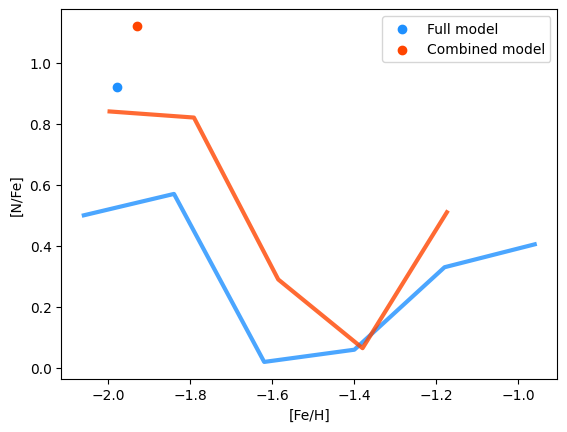

In [215]:
# where is this star?

xx_full = scl_dic_full_model['l_feh']
yy_full = scl_dic_full_model['l_n']
bins_cannon_full = np.linspace(np.min(xx_full), max(xx_full), 8)
bin_centers_cannon_full = 0.5 * (bins_cannon_full[1:] + bins_cannon_full[:-1])

xx_comb = scl_dic_combined_model['l_feh']
yy_comb = scl_dic_combined_model['l_n']
bins_cannon_comb = np.linspace(min(xx_comb), max(xx_comb), 8)
bin_centers_cannon_comb = 0.5 * (bins_cannon_comb[1:] + bins_cannon_comb[:-1])

# Cannon tracks
med_full, _ , _ = binned_stats(xx_full, yy_full, bins_cannon_full, min_points=3)
med_comb, _ , _ = binned_stats(xx_comb, yy_comb, bins_cannon_comb, min_points=3)


plt.figure()
plt.plot(bin_centers_cannon_full, med_full, color='dodgerblue', lw=3, alpha=0.8)
plt.plot(bin_centers_cannon_comb, med_comb, color='orangered', lw=3, alpha=0.8)
plt.scatter(scl_dic_full_model['l_feh'][s],scl_dic_full_model['l_n'][s],color='dodgerblue',label='Full model')
plt.scatter(scl_dic_combined_model['l_feh'][s],scl_dic_combined_model['l_n'][s],color='orangered',label='Combined model')
plt.ylabel('[N/Fe]')
plt.xlabel('[Fe/H]')
#plt.ylim(-1,1.5)
#plt.xlim(-2.3,-0.5)
plt.legend()
plt.show()

In [216]:
unc_scl_full_model[:,9][s], unc_scl_combined_model[:,9][s], scl_dic_full_model['l_feh'][s], scl_dic_combined_model['l_feh'][s]

(0.31542474626521727, 0.36934042209901097, -1.98, -1.93)

In [173]:
star_properties=scl_dic_combined_model[s]
cols_round = {'SNR', 'ra', 'dec'}

props_str = ', '.join(f"{col}: {star_properties[col]:.2f}" if col in cols_round
                      else f"{col}: {star_properties[col]}"
                      for col in star_properties.colnames)

#props_str = ', '.join(f"{col}: {star_properties[col]}" for col in star_properties.colnames)

props_str

'number: 4, original_idx: 12, SNR: 11.69, ra: 15.03, dec: -33.71, Teff: 5170.0, logg: 2.39, vmic: 0.52, Ak: -0.03, l_feh: -1.93, l_mg: 0.33, l_mn: 0.14, l_al: 2.4, l_c: 0.02, l_n: 1.12, e_teff: 0.07, e_logg: 0.1, e_vmic: 0.15, e_Ak: 0.21, e_feh: 0.09, e_mg: 0.35, e_mn: 0.49, e_al: 0.83, e_c: 0.21, e_n: 0.37, red chi2: 0.6'

### Saving our estimations

In [80]:
def saving_table(final_table, SNR_array, predicted_labels_thecannon, unc_thecannon, chi2_model,modelname,
                 radial_velocity, savingtable = True, idxs_all=[]):

    '''
    Inputs: 
    - final_table : MUSE table of selected stars (for getting ra dec coordinates)
    '''
    
    import astropy.units as u
    
    if len(idxs_all) > 0:original_idxs = idxs_all
    else: original_idxs =final_table ['id']
    
    dic = {}
    #dic['number']= [int(i) for i in np.linspace(1,len(final_table ),len(final_table ))]
    dic['id']= original_idxs  
    dic['RA'] = final_table['ra']
    dic['DEC'] = final_table['dec']
    dic['m_F450W'] = final_table['m_F450W']
    dic['m_F814W'] = final_table['m_F814W']
    dic['dm_F450W'] = final_table['dm_F450W']
    dic['dm_F814W'] = final_table['dm_F814W']
    dic['SNR'] = SNR_array   #from muse obs
    dic['RV'] = radial_velocity   #km/s
    dic['Teff'] = np.round(predicted_labels_thecannon[:,0])
    dic['e_teff'] = np.round(unc_thecannon[:,0],2)
    dic['logg'] = np.round(predicted_labels_thecannon[:,1],2)
    dic['e_logg'] = np.round(unc_thecannon[:,1],2)
    dic['vmic'] = np.round(predicted_labels_thecannon[:,2],2)
    dic['e_vmic'] = np.round(unc_thecannon[:,2],2)
    dic['Ak'] = np.round(predicted_labels_thecannon[:,3],2)
    dic['e_Ak'] = np.round(unc_thecannon[:,3],2)
    dic['l_feh'] = np.round(predicted_labels_thecannon[:,4],2)
    dic['e_feh'] = np.round(unc_thecannon[:,4],2)
    dic['l_mg'] = np.round(predicted_labels_thecannon[:,5],2)
    dic['e_mg'] = np.round(unc_thecannon[:,5],2)
    dic['l_mn'] = np.round(predicted_labels_thecannon[:,6],2)
    dic['e_mn'] = np.round(unc_thecannon[:,6],2)
    dic['l_al'] = np.round(predicted_labels_thecannon[:,7],2)
    dic['e_al'] = np.round(unc_thecannon[:,7],2)
    dic['l_c'] = np.round(predicted_labels_thecannon[:,8],2)
    dic['e_c'] = np.round(unc_thecannon[:,8],2)
    dic['l_n'] = np.round(predicted_labels_thecannon[:,9],2)
    dic['e_n'] = np.round(unc_thecannon[:,9],2)
    dic['red_chi2'] = chi2_model
    dic = Table(dic)
    
    #units
    dic['RV'].unit = u.km / u.s
    dic['Teff'].unit = u.K
    dic['logg'].unit = u.cm / u.s**2  # Ojo: logg es log10(g), pero la unidad formal es esta
    dic['SNR'].unit = u.dimensionless_unscaled

    #more data
    dic['RA'].meta['description'] = "RA coordinate (degree)"
    dic['DEC'].meta['description'] = "DEC coordinate (degree)"
    dic['m_F450W'].meta['description'] = "Apparent magnitude in the HST/WFPC2 F450W filter"
    dic['dm_F450W'].meta['description'] = "Uncertainty of the m_F450W magnitude"
    dic['m_F814W'].meta['description'] = "Apparent magnitude in the HST/WFPC2 F814W filter"
    dic['dm_F814W'].meta['description'] = "Uncertainty of the m_F814W magnitude"    
    dic['SNR'].meta['description'] = "Signal-to-noise ratio of the MUSE spectrum"
    dic['RV'].meta['description'] = "Radial velocity"
    dic['Teff'].meta['description'] = "Effective temperature estimated by The Cannon (K)"
    dic['e_teff'].meta['description'] = "Uncertainty of the effective temperature"
    dic['logg'].meta['description'] = "Surface gravity log10(g) estimated by The Cannon"
    dic['e_logg'].meta['description'] = "Uncertainty of the surface gravity"
    dic['vmic'].meta['description'] = "Microturbulent velocity estimated by The Cannon"
    dic['e_vmic'].meta['description'] = "Uncertainty of the microturbulent velocity"
    dic['Ak'].meta['description'] = "K-band extinction estimated by The Cannon"
    dic['e_Ak'].meta['description'] = "Uncertainty of AK"
    dic['l_feh'].meta['description'] = "[Fe/H] abundance estimated by The Cannon"
    dic['e_feh'].meta['description'] = "Uncertainty of the [Fe/H] abundance"
    dic['l_mg'].meta['description'] = "[Mg/Fe] abundance estimated by The Cannon"
    dic['e_mg'].meta['description'] = "Uncertainty of the [Mg/Fe] abundance"
    dic['l_mn'].meta['description'] = "[Mn/Fe] abundance estimated by The Cannon"
    dic['e_mn'].meta['description'] = "Uncertainty of the [Mn/Fe] abundance"
    dic['l_al'].meta['description'] = "[Al/Fe] abundance estimated by The Cannon"
    dic['e_al'].meta['description'] = "Uncertainty of the [Al/Fe] abundance"
    dic['l_c'].meta['description'] = "[C/Fe] abundance estimated by The Cannon"
    dic['e_c'].meta['description'] = "Uncertainty of the [C/Fe] abundance"
    dic['l_n'].meta['description'] = "[N/Fe] abundance estimated by The Cannon"
    dic['e_n'].meta['description'] = "Uncertainty of the [N/Fe] abundance"
    dic['red_chi2'].meta['description'] = "Reduced chi-squared value"

    if savingtable: 
        table_name = f'output_files/finaltable_scl_predicted_labels_{modelname}_model.fits'
        dic.write(f"{table_name}", overwrite=True)
        print(f"\n✅ Table saved to: {table_name}")

    return dic


## Recovering uncertainties:
snr_combined, teff_unc_combined, logg_unc_combined, vmic_unc_combined, ak_unc_combined, feh_unc_combined, mg_unc_combined, mn_unc_combined, al_unc_combined, c_unc_combined, n_unc_combined = recovering_just_uncertainties(unc_results_combined)

# COMBINED MODEL:
# MUSE observations of Sculptor
scl_selected_muse_table = scl_full_table[rgb_scl_mask][scl_SNR_mask][v_mask]
#arrange with the scatter uncertainty of the combined model
total_unc_scatter_combined = np.array([teff_unc_combined , logg_unc_combined , vmic_unc_combined , 
                                       ak_unc_combined , feh_unc_combined , mg_unc_combined , 
                                       mn_unc_combined , al_unc_combined , c_unc_combined , n_unc_combined]).T

#full-spectrum model
final_table_scl_combined = saving_table(scl_selected_muse_table,
                                    scl_SNR[scl_SNR_mask][v_mask],
                                    predicted_labels_scl_combined_model,
                                    total_unc_scatter_combined,
                                    np.round([entry['r_chi_sq'] for entry in metadata_scl_combined_model],2),
                                    modelname = 'combined',
                                    radial_velocity = np.array(velout_all_scl)[v_mask])


✅ Table saved to: output_files/finaltable_scl_predicted_labels_combined_model.fits
